 **Importation du dataset netoyée**

In [1]:
import pandas as pd
from google.colab import drive

# ── Montage de Google Drive ───────────────────────────────────────
drive.mount('/content/drive')

# ── Chemin du fichier sur Drive ───────────────────────────────────
# Modifier selon l'emplacement exact de ton fichier dans Drive
chemin_fichier = '/content/drive/MyDrive/Dataset_Clean_ML.csv'
# Exemples si ton fichier est dans un sous-dossier :
# chemin_fichier = '/content/drive/MyDrive/OMC/Dataset_Clean_ML.csv'
# chemin_fichier = '/content/drive/MyDrive/Projet_P2M/Dataset_Clean_ML.csv'

# ── Chargement ────────────────────────────────────────────────────
df_clean = pd.read_csv(chemin_fichier, sep=';')

print(f"Mon fichier contient {df_clean.shape[0]} lignes et {df_clean.shape[1]} colonnes.")
display(df_clean.head(10))

Mounted at /content/drive
Mon fichier contient 1959516 lignes et 14 colonnes.


,Time,eNodeB_Name,Cell_Name,eNodeB_Function_Name,KPI_RRC_SR,KPI_DCR,KPI_ERAB_SR,KPI_Thrp_DL_Mbps,KPI_Thrp_UL_Mbps,KPI_HOSR,KPI_HOSR_InterFreq,KPI_HOSR_InterRAT,Cell_Availability,CSFB_SR
0,2025-06-01 00:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,99.968198,0.000000,99.967711,11.791251,1.327820,100.000000,100.0,100.0,100.0,100.0
1,2025-06-01 01:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,99.801980,0.000000,99.808734,14.219384,2.090457,100.000000,100.0,100.0,100.0,100.0
2,2025-06-01 02:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,99.911894,0.000000,99.953661,19.757798,4.220755,100.000000,100.0,100.0,100.0,100.0
3,2025-06-01 03:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,100.000000,0.000000,100.000000,20.931697,2.357093,100.000000,100.0,100.0,100.0,100.0
4,2025-06-01 04:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,100.000000,0.000000,100.000000,15.794695,0.948091,100.000000,100.0,100.0,100.0,100.0
5,2025-06-01 05:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,100.000000,0.000000,99.950568,15.891576,4.197642,100.000000,100.0,100.0,100.0,100.0
6,2025-06-01 06:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,99.926776,0.000000,99.973822,12.796559,2.514590,100.000000,100.0,100.0,100.0,100.0
7,2025-06-01 07:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,99.893603,0.014251,99.971579,10.437760,1.720894,97.368421,100.0,100.0,100.0,100.0
8,2025-06-01 08:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,99.990767,0.000000,99.960384,9.945187,1.818623,98.550725,100.0,100.0,100.0,100.0
9,2025-06-01 09:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,99.944639,0.010083,99.919257,9.884786,1.820692,98.484848,100.0,100.0,100.0,100.0


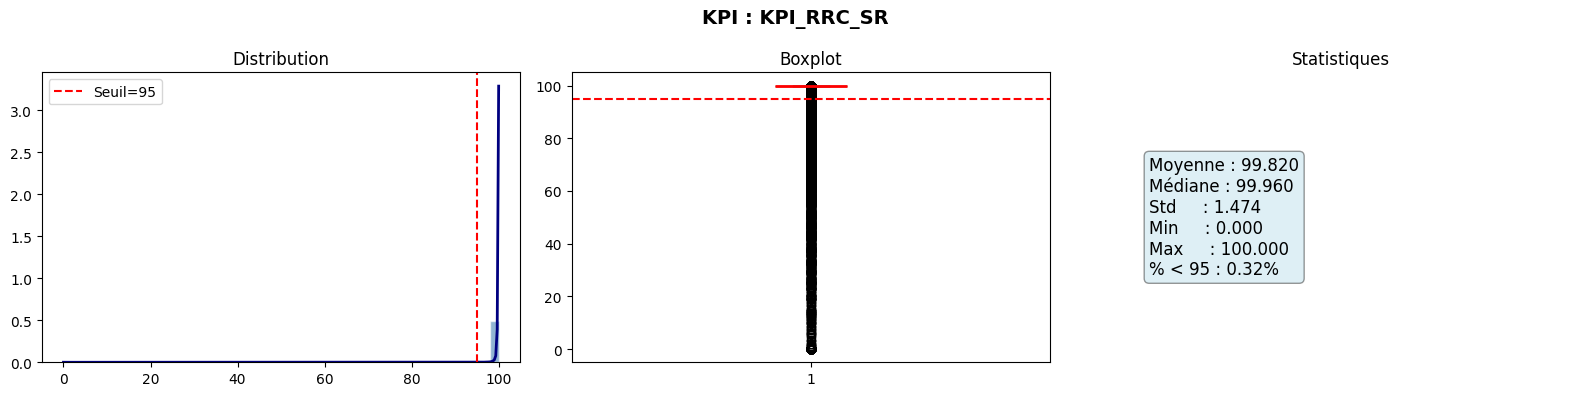

In [3]:
import matplotlib.pyplot as plt
import numpy as np
# ── KPI 1 : KPI_RRC_SR ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
kpi = 'KPI_RRC_SR'; seuil = 95
data = df_clean[kpi].dropna()

# Histogramme + KDE
axes[0].hist(data, bins=50, color='steelblue', alpha=0.6,
             edgecolor='white', density=True)
from scipy.stats import gaussian_kde
kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), 300)
axes[0].plot(x, kde(x), color='navy', linewidth=2)
axes[0].axvline(seuil, color='red', linestyle='--',
                linewidth=1.5, label=f'Seuil={seuil}')
axes[0].set_title('Distribution'); axes[0].legend()

# Boxplot
axes[1].boxplot(data, patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].axhline(seuil, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Boxplot')

# Stats
axes[2].axis('off')
stats_txt = (f"Moyenne : {data.mean():.3f}\n"
             f"Médiane : {data.median():.3f}\n"
             f"Std     : {data.std():.3f}\n"
             f"Min     : {data.min():.3f}\n"
             f"Max     : {data.max():.3f}\n"
             f"% < {seuil} : {(data<seuil).mean()*100:.2f}%")
axes[2].text(0.1, 0.5, stats_txt, fontsize=12,
             verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.4))
axes[2].set_title('Statistiques')

plt.suptitle(f'KPI : {kpi}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{kpi}.png', dpi=150, bbox_inches='tight')
plt.show()

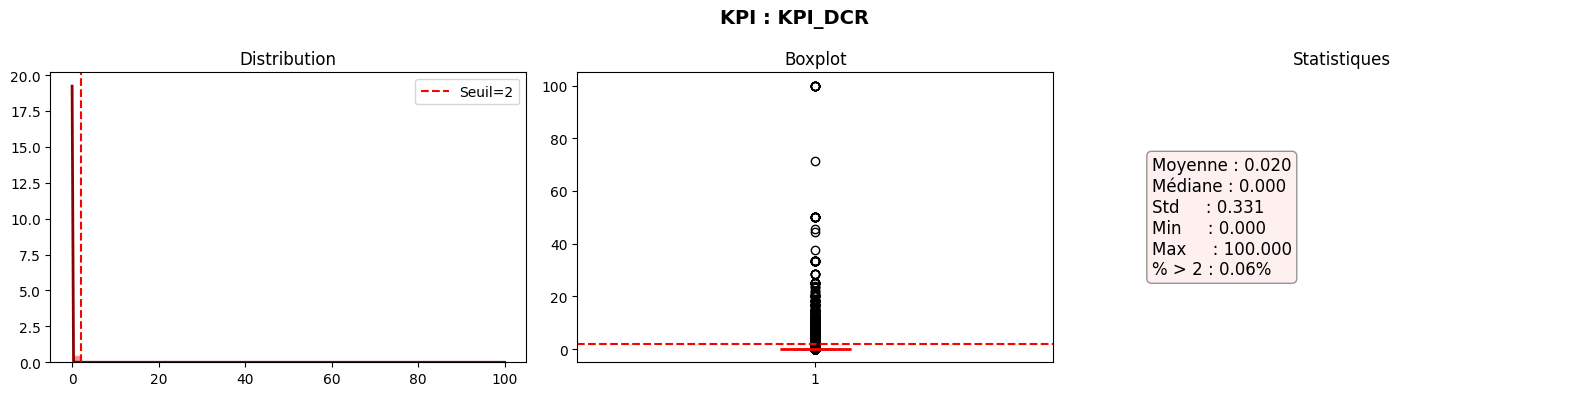

In [ ]:
# ── KPI 2 : KPI_DCR ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
kpi = 'KPI_DCR'; seuil = 2
data = df_clean[kpi].dropna()

axes[0].hist(data, bins=50, color='#e74c3c', alpha=0.6,
             edgecolor='white', density=True)
kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), 300)
axes[0].plot(x, kde(x), color='darkred', linewidth=2)
axes[0].axvline(seuil, color='red', linestyle='--',
                linewidth=1.5, label=f'Seuil={seuil}')
axes[0].set_title('Distribution'); axes[0].legend()

axes[1].boxplot(data, patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                boxprops=dict(facecolor='#e74c3c', alpha=0.6))
axes[1].axhline(seuil, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Boxplot')

axes[2].axis('off')
stats_txt = (f"Moyenne : {data.mean():.3f}\n"
             f"Médiane : {data.median():.3f}\n"
             f"Std     : {data.std():.3f}\n"
             f"Min     : {data.min():.3f}\n"
             f"Max     : {data.max():.3f}\n"
             f"% > {seuil} : {(data>seuil).mean()*100:.2f}%")
axes[2].text(0.1, 0.5, stats_txt, fontsize=12,
             verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='#fadbd8', alpha=0.4))
axes[2].set_title('Statistiques')

plt.suptitle(f'KPI : {kpi}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{kpi}.png', dpi=150, bbox_inches='tight')
plt.show()

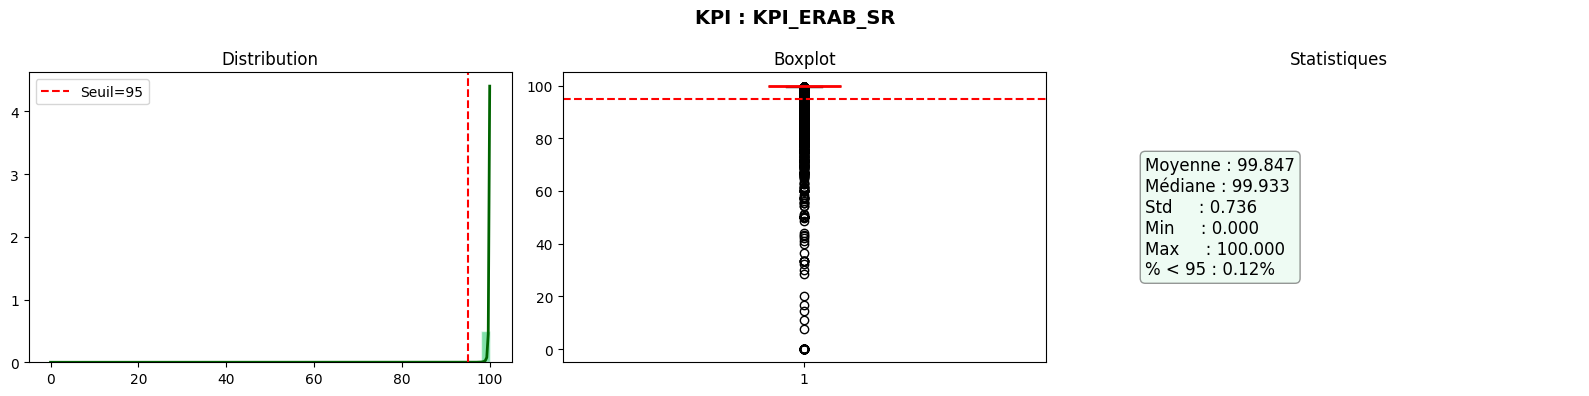

In [ ]:
# ── KPI 3 : KPI_ERAB_SR ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
kpi = 'KPI_ERAB_SR'; seuil = 95
data = df_clean[kpi].dropna()

axes[0].hist(data, bins=50, color='#2ecc71', alpha=0.6,
             edgecolor='white', density=True)
kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), 300)
axes[0].plot(x, kde(x), color='darkgreen', linewidth=2)
axes[0].axvline(seuil, color='red', linestyle='--',
                linewidth=1.5, label=f'Seuil={seuil}')
axes[0].set_title('Distribution'); axes[0].legend()

axes[1].boxplot(data, patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                boxprops=dict(facecolor='#2ecc71', alpha=0.6))
axes[1].axhline(seuil, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Boxplot')

axes[2].axis('off')
stats_txt = (f"Moyenne : {data.mean():.3f}\n"
             f"Médiane : {data.median():.3f}\n"
             f"Std     : {data.std():.3f}\n"
             f"Min     : {data.min():.3f}\n"
             f"Max     : {data.max():.3f}\n"
             f"% < {seuil} : {(data<seuil).mean()*100:.2f}%")
axes[2].text(0.1, 0.5, stats_txt, fontsize=12,
             verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='#d5f5e3', alpha=0.4))
axes[2].set_title('Statistiques')

plt.suptitle(f'KPI : {kpi}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{kpi}.png', dpi=150, bbox_inches='tight')
plt.show()

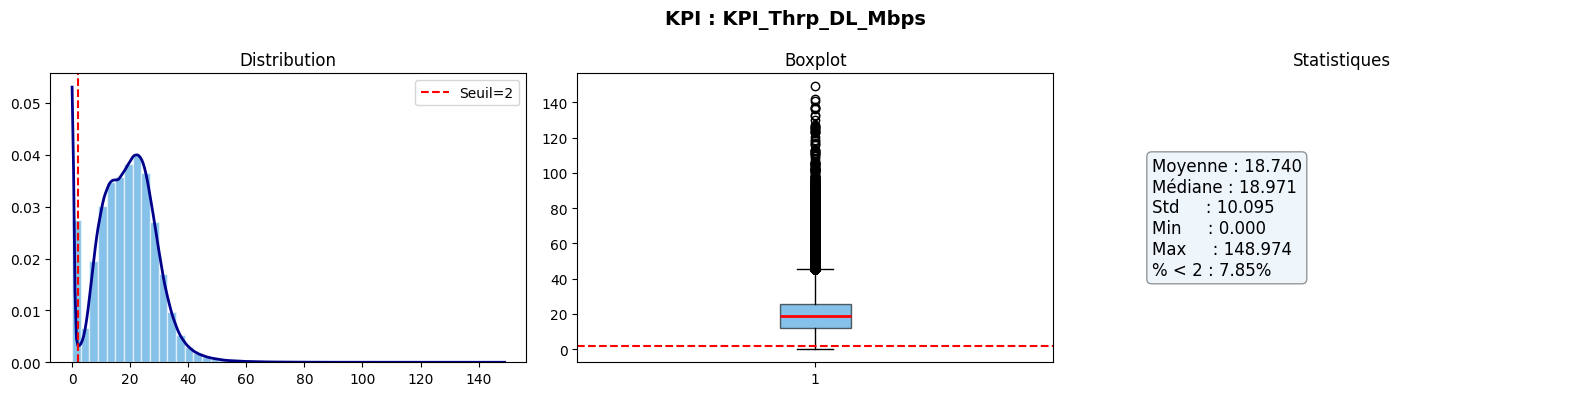

In [ ]:
# ── KPI 4 : KPI_Thrp_DL_Mbps ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
kpi = 'KPI_Thrp_DL_Mbps'; seuil = 2
data = df_clean[kpi].dropna()

axes[0].hist(data, bins=50, color='#3498db', alpha=0.6,
             edgecolor='white', density=True)
kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), 300)
axes[0].plot(x, kde(x), color='darkblue', linewidth=2)
axes[0].axvline(seuil, color='red', linestyle='--',
                linewidth=1.5, label=f'Seuil={seuil}')
axes[0].set_title('Distribution'); axes[0].legend()

axes[1].boxplot(data, patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[1].axhline(seuil, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Boxplot')

axes[2].axis('off')
stats_txt = (f"Moyenne : {data.mean():.3f}\n"
             f"Médiane : {data.median():.3f}\n"
             f"Std     : {data.std():.3f}\n"
             f"Min     : {data.min():.3f}\n"
             f"Max     : {data.max():.3f}\n"
             f"% < {seuil} : {(data<seuil).mean()*100:.2f}%")
axes[2].text(0.1, 0.5, stats_txt, fontsize=12,
             verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='#d6eaf8', alpha=0.4))
axes[2].set_title('Statistiques')

plt.suptitle(f'KPI : {kpi}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{kpi}.png', dpi=150, bbox_inches='tight')
plt.show()

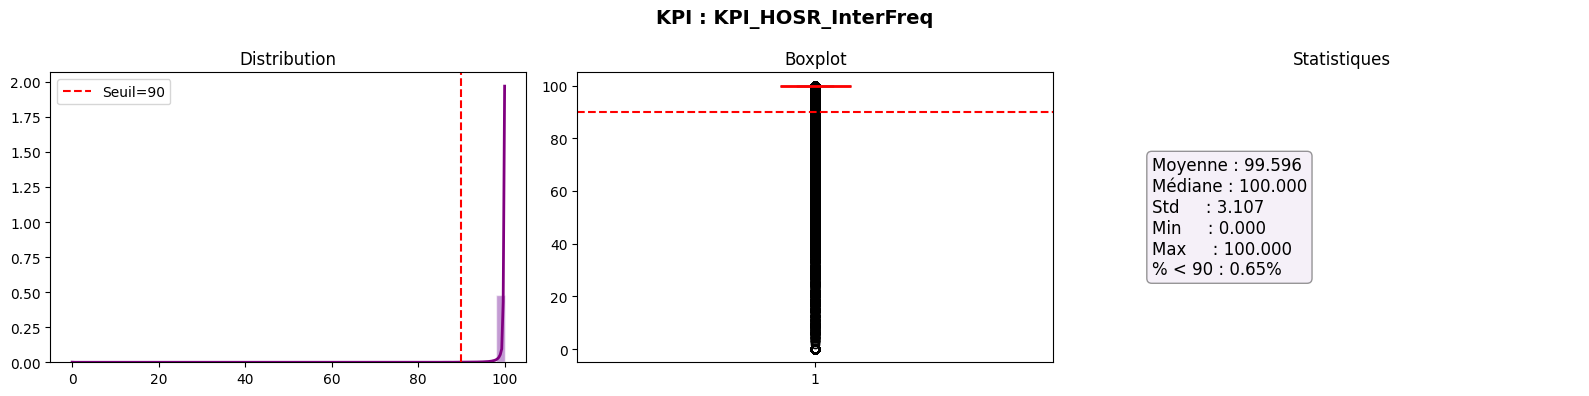

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# ── KPI 5 : KPI_Thrp_UL_Mbps ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
kpi = 'KPI_HOSR_InterFreq'; seuil = 90
data = df_clean[kpi].dropna()

axes[0].hist(data, bins=50, color='#9b59b6', alpha=0.6,
             edgecolor='white', density=True)
kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), 300)
axes[0].plot(x, kde(x), color='purple', linewidth=2)
axes[0].axvline(seuil, color='red', linestyle='--',
                linewidth=1.5, label=f'Seuil={seuil}')
axes[0].set_title('Distribution'); axes[0].legend()

axes[1].boxplot(data, patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                boxprops=dict(facecolor='#9b59b6', alpha=0.6))
axes[1].axhline(seuil, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Boxplot')

axes[2].axis('off')
stats_txt = (f"Moyenne : {data.mean():.3f}\n"
             f"Médiane : {data.median():.3f}\n"
             f"Std     : {data.std():.3f}\n"
             f"Min     : {data.min():.3f}\n"
             f"Max     : {data.max():.3f}\n"
             f"% < {seuil} : {(data<seuil).mean()*100:.2f}%")
axes[2].text(0.1, 0.5, stats_txt, fontsize=12,
             verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='#e8daef', alpha=0.4))
axes[2].set_title('Statistiques')

plt.suptitle(f'KPI : {kpi}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{kpi}.png', dpi=150, bbox_inches='tight')
plt.show()

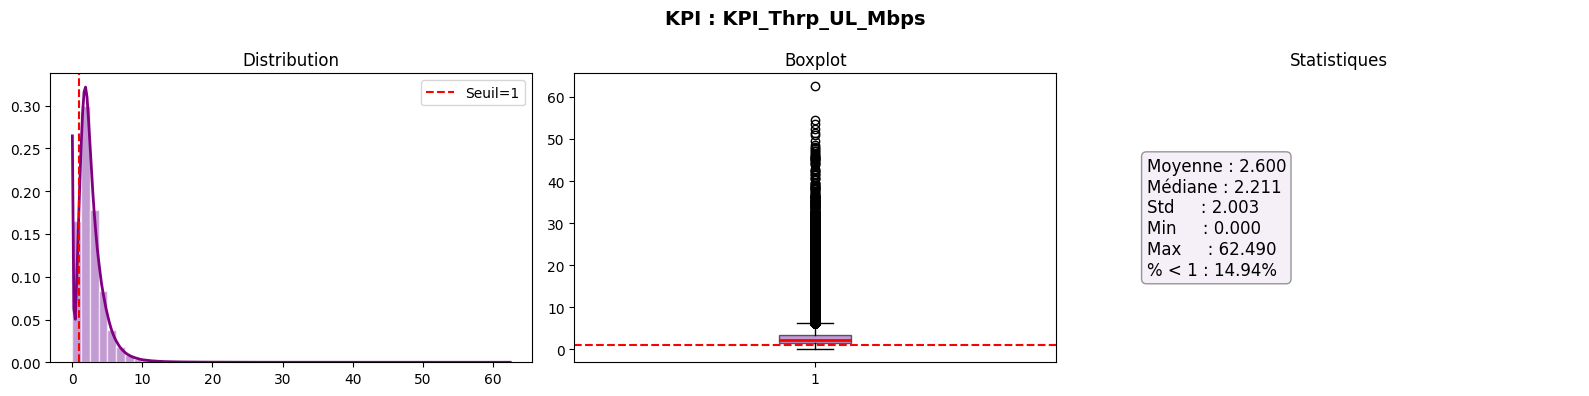

In [ ]:
# ── KPI 5 : KPI_Thrp_UL_Mbps ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
kpi = 'KPI_Thrp_UL_Mbps'; seuil = 1
data = df_clean[kpi].dropna()

axes[0].hist(data, bins=50, color='#9b59b6', alpha=0.6,
             edgecolor='white', density=True)
kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), 300)
axes[0].plot(x, kde(x), color='purple', linewidth=2)
axes[0].axvline(seuil, color='red', linestyle='--',
                linewidth=1.5, label=f'Seuil={seuil}')
axes[0].set_title('Distribution'); axes[0].legend()

axes[1].boxplot(data, patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                boxprops=dict(facecolor='#9b59b6', alpha=0.6))
axes[1].axhline(seuil, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Boxplot')

axes[2].axis('off')
stats_txt = (f"Moyenne : {data.mean():.3f}\n"
             f"Médiane : {data.median():.3f}\n"
             f"Std     : {data.std():.3f}\n"
             f"Min     : {data.min():.3f}\n"
             f"Max     : {data.max():.3f}\n"
             f"% < {seuil} : {(data<seuil).mean()*100:.2f}%")
axes[2].text(0.1, 0.5, stats_txt, fontsize=12,
             verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='#e8daef', alpha=0.4))
axes[2].set_title('Statistiques')

plt.suptitle(f'KPI : {kpi}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{kpi}.png', dpi=150, bbox_inches='tight')
plt.show()

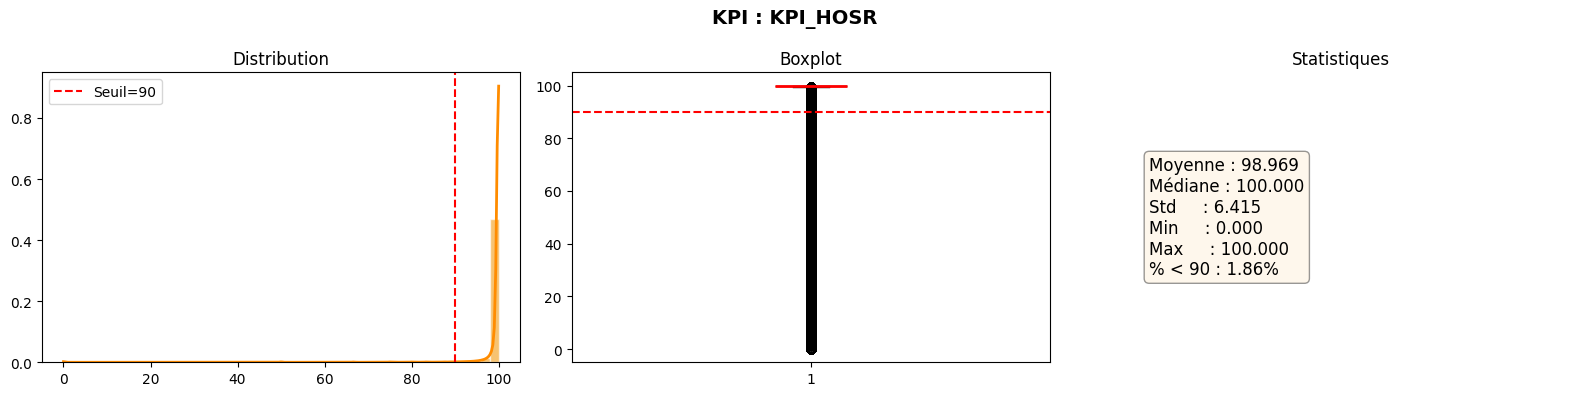

In [ ]:
# ── KPI 6 : KPI_HOSR ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
kpi = 'KPI_HOSR'; seuil = 90
data = df_clean[kpi].dropna()

axes[0].hist(data, bins=50, color='#f39c12', alpha=0.6,
             edgecolor='white', density=True)
kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), 300)
axes[0].plot(x, kde(x), color='darkorange', linewidth=2)
axes[0].axvline(seuil, color='red', linestyle='--',
                linewidth=1.5, label=f'Seuil={seuil}')
axes[0].set_title('Distribution'); axes[0].legend()

axes[1].boxplot(data, patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                boxprops=dict(facecolor='#f39c12', alpha=0.6))
axes[1].axhline(seuil, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Boxplot')

axes[2].axis('off')
stats_txt = (f"Moyenne : {data.mean():.3f}\n"
             f"Médiane : {data.median():.3f}\n"
             f"Std     : {data.std():.3f}\n"
             f"Min     : {data.min():.3f}\n"
             f"Max     : {data.max():.3f}\n"
             f"% < {seuil} : {(data<seuil).mean()*100:.2f}%")
axes[2].text(0.1, 0.5, stats_txt, fontsize=12,
             verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='#fdebd0', alpha=0.4))
axes[2].set_title('Statistiques')

plt.suptitle(f'KPI : {kpi}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{kpi}.png', dpi=150, bbox_inches='tight')
plt.show()

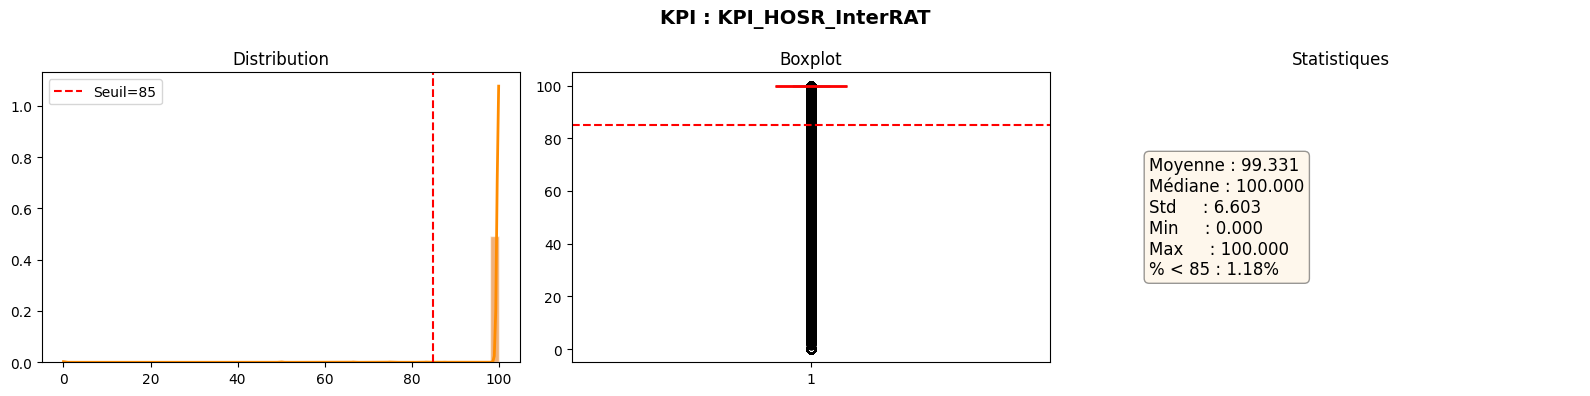

In [ ]:
# ── KPI 8 : KPI_HOSR_InterRAT ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
kpi = 'KPI_HOSR_InterRAT'; seuil = 85
data = df_clean[kpi].dropna()

axes[0].hist(data, bins=50, color='#e67e22', alpha=0.6,
             edgecolor='white', density=True)
kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), 300)
axes[0].plot(x, kde(x), color='darkorange', linewidth=2)
axes[0].axvline(seuil, color='red', linestyle='--',
                linewidth=1.5, label=f'Seuil={seuil}')
axes[0].set_title('Distribution'); axes[0].legend()

axes[1].boxplot(data, patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                boxprops=dict(facecolor='#e67e22', alpha=0.6))
axes[1].axhline(seuil, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Boxplot')

axes[2].axis('off')
stats_txt = (f"Moyenne : {data.mean():.3f}\n"
             f"Médiane : {data.median():.3f}\n"
             f"Std     : {data.std():.3f}\n"
             f"Min     : {data.min():.3f}\n"
             f"Max     : {data.max():.3f}\n"
             f"% < {seuil} : {(data<seuil).mean()*100:.2f}%")
axes[2].text(0.1, 0.5, stats_txt, fontsize=12,
             verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='#fdebd0', alpha=0.4))
axes[2].set_title('Statistiques')

plt.suptitle(f'KPI : {kpi}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{kpi}.png', dpi=150, bbox_inches='tight')
plt.show()

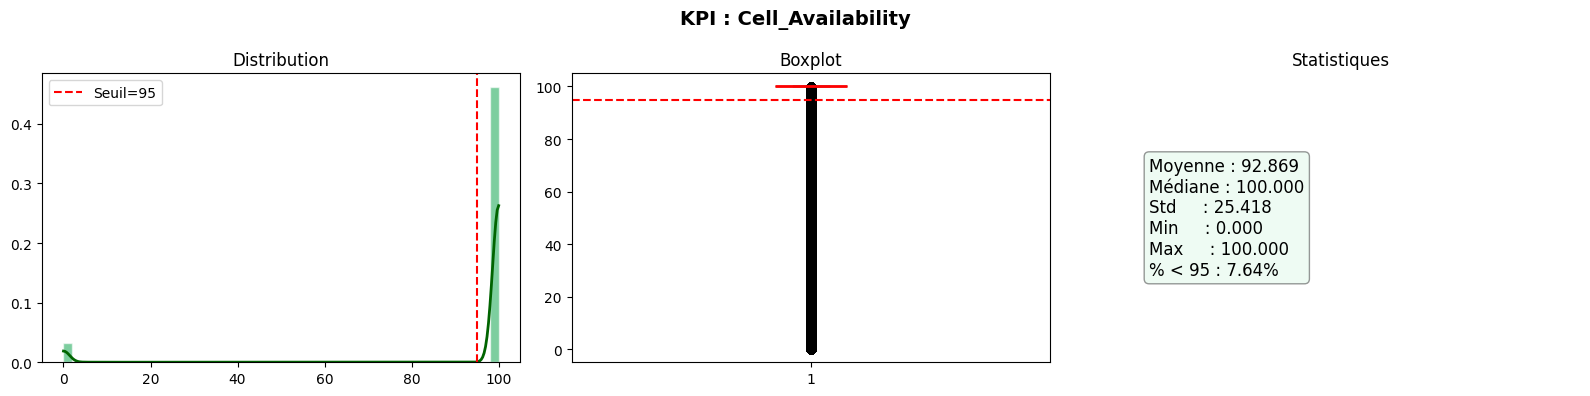

In [ ]:
# ── KPI 9 : Cell_Availability ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
kpi = 'Cell_Availability'; seuil = 95
data = df_clean[kpi].dropna()

axes[0].hist(data, bins=50, color='#27ae60', alpha=0.6,
             edgecolor='white', density=True)
kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), 300)
axes[0].plot(x, kde(x), color='darkgreen', linewidth=2)
axes[0].axvline(seuil, color='red', linestyle='--',
                linewidth=1.5, label=f'Seuil={seuil}')
axes[0].set_title('Distribution'); axes[0].legend()

axes[1].boxplot(data, patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                boxprops=dict(facecolor='#27ae60', alpha=0.6))
axes[1].axhline(seuil, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Boxplot')

axes[2].axis('off')
stats_txt = (f"Moyenne : {data.mean():.3f}\n"
             f"Médiane : {data.median():.3f}\n"
             f"Std     : {data.std():.3f}\n"
             f"Min     : {data.min():.3f}\n"
             f"Max     : {data.max():.3f}\n"
             f"% < {seuil} : {(data<seuil).mean()*100:.2f}%")
axes[2].text(0.1, 0.5, stats_txt, fontsize=12,
             verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='#d5f5e3', alpha=0.4))
axes[2].set_title('Statistiques')

plt.suptitle(f'KPI : {kpi}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{kpi}.png', dpi=150, bbox_inches='tight')
plt.show()

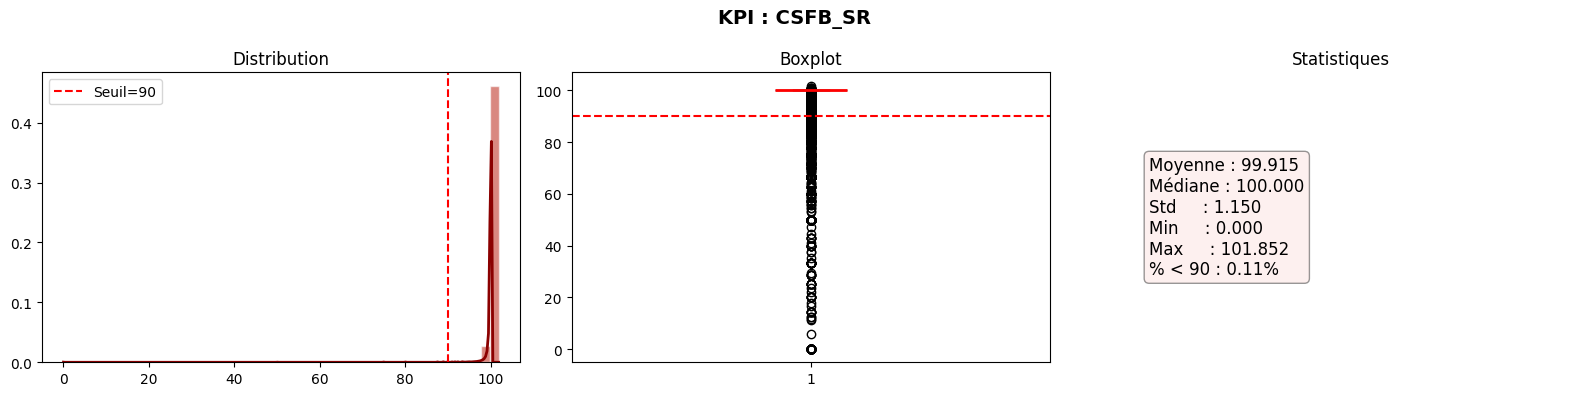


✅ Toutes les figures sauvegardées !


In [ ]:
# ── KPI 10 : CSFB_SR ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
kpi = 'CSFB_SR'; seuil = 90
data = df_clean[kpi].dropna()

axes[0].hist(data, bins=50, color='#c0392b', alpha=0.6,
             edgecolor='white', density=True)
kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), 300)
axes[0].plot(x, kde(x), color='darkred', linewidth=2)
axes[0].axvline(seuil, color='red', linestyle='--',
                linewidth=1.5, label=f'Seuil={seuil}')
axes[0].set_title('Distribution'); axes[0].legend()

axes[1].boxplot(data, patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                boxprops=dict(facecolor='#c0392b', alpha=0.6))
axes[1].axhline(seuil, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Boxplot')

axes[2].axis('off')
stats_txt = (f"Moyenne : {data.mean():.3f}\n"
             f"Médiane : {data.median():.3f}\n"
             f"Std     : {data.std():.3f}\n"
             f"Min     : {data.min():.3f}\n"
             f"Max     : {data.max():.3f}\n"
             f"% < {seuil} : {(data<seuil).mean()*100:.2f}%")
axes[2].text(0.1, 0.5, stats_txt, fontsize=12,
             verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='#fadbd8', alpha=0.4))
axes[2].set_title('Statistiques')

plt.suptitle(f'KPI : {kpi}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{kpi}.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Toutes les figures sauvegardées !")

In [ ]:
# ── 3. Statistiques descriptives ─────────────────────────────
stats = df_clean[KPI_COLS].describe().round(3)

# Ajouter % valeurs sous seuil
below = {}
for kpi in KPI_COLS:
    if kpi in SEUILS:
        s = SEUILS[kpi]
        if kpi == 'KPI_DCR':
            pct = (df_clean[kpi] > s).mean() * 100
        else:
            pct = (df_clean[kpi] < s).mean() * 100
        below[kpi] = f"{pct:.2f}%"
    else:
        below[kpi] = "—"

stats.loc['% sous seuil'] = below
print("📊 Statistiques descriptives des KPI :")
display(stats)

📊 Statistiques descriptives des KPI :


,KPI_RRC_SR,KPI_DCR,KPI_ERAB_SR,KPI_Thrp_DL_Mbps,KPI_Thrp_UL_Mbps,KPI_HOSR,KPI_HOSR_InterFreq,KPI_HOSR_InterRAT,Cell_Availability,CSFB_SR
count,1959516.0,1959516.0,1959516.0,1959516.0,1959516.0,1959516.0,1959516.0,1959516.0,1959516.0,1959516.0
mean,99.82,0.02,99.847,18.74,2.6,98.969,99.596,99.331,92.869,99.915
std,1.474,0.331,0.736,10.095,2.003,6.415,3.107,6.603,25.418,1.15
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,99.875,0.0,99.836,11.93,1.414,99.765,100.0,100.0,100.0,100.0
50%,99.96,0.0,99.933,18.971,2.211,100.0,100.0,100.0,100.0,100.0
75%,100.0,0.0,100.0,25.357,3.353,100.0,100.0,100.0,100.0,100.0
max,100.0,100.0,100.0,148.974,62.49,100.0,100.0,100.0,100.0,101.852
% sous seuil,0.32%,0.06%,0.12%,7.85%,14.94%,1.86%,0.40%,1.18%,7.64%,0.11%


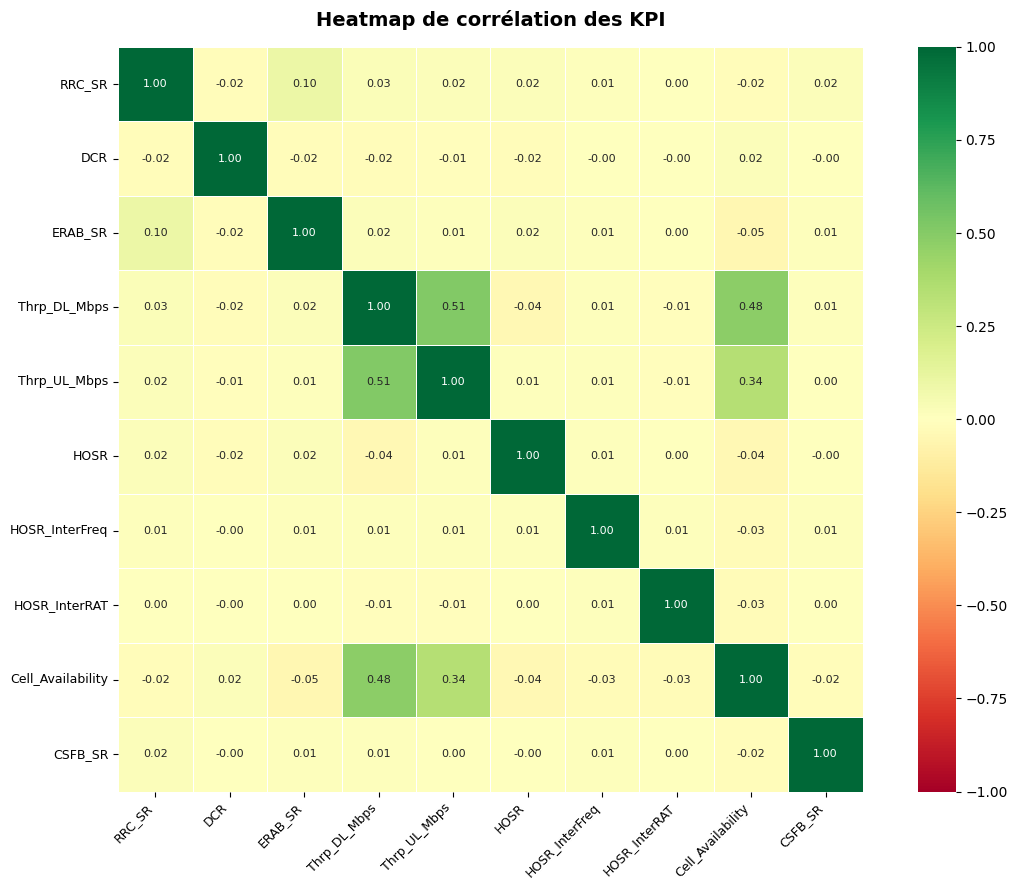

✅ Figure 3 sauvegardée


In [ ]:
# ── 4. Heatmap corrélation ────────────────────────────────────
plt.figure(figsize=(12, 9))

corr = df_clean[KPI_COLS].corr().round(2)

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    annot_kws={'size': 8},
    xticklabels=[k.replace('KPI_','') for k in KPI_COLS],
    yticklabels=[k.replace('KPI_','') for k in KPI_COLS],
)

plt.title('Heatmap de corrélation des KPI',
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('heatmap_correlation_kpi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 3 sauvegardée")

In [ ]:
import os, json
import pandas as pd

fichiers = {
    'alerting_summary.json'     : '/content/drive/MyDrive/P2M_Models/Alerting/alerting_summary.json',
    'health_summary.json'       : '/content/drive/MyDrive/P2M_Models/HealthScore/health_summary.json',
    'granger_stabilite.csv'     : '/content/drive/MyDrive/P2M_Models/Granger/granger_stabilite.csv',
    'interpretations_causales.json': '/content/drive/MyDrive/P2M_Models/Granger/interpretations_causales.json',
}

print("═" * 60)
for nom, path in fichiers.items():
    if not os.path.exists(path):
        print(f"  ❌ ABSENT    : {nom}")
        continue
    size = os.path.getsize(path)
    print(f"\n  📄 {nom} ({size} octets)")
    if size == 0:
        print(f"     ⚠️ FICHIER VIDE")
    else:
        # Lire le contenu
        try:
            if nom.endswith('.json'):
                with open(path) as f:
                    data = json.load(f)
                print(f"     Contenu : {data}")
            elif nom.endswith('.csv'):
                df = pd.read_csv(path)
                print(f"     Shape : {df.shape}")
                print(f"     Colonnes : {df.columns.tolist()}")
                display(df.head(3))
        except Exception as e:
            print(f"     Erreur lecture : {e}")

════════════════════════════════════════════════════════════

  📄 alerting_summary.json (562 octets)
     Contenu : {'total_observations': 1959516, 'nb_alertes_reelles': 8709, 'nb_alertes_critiques': 5926, 'nb_fausses_alarmes_filtr': 1930874, 'taux_fausses_alarmes_pct': 98.54, 'incident_le_plus_frequent': 'Echec_Handover', 'cellule_la_plus_alertee': 'TINKOTO_e1', 'nb_cellules_critiques': 973, 'seuils_utilises': {'KPI_RRC_SR': 95.0, 'KPI_ERAB_SR': 95.0, 'KPI_DCR': 2.0, 'KPI_HOSR': 90.0, 'KPI_HOSR_InterFreq': 85.0, 'KPI_HOSR_InterRAT': 80.0, 'KPI_Thrp_DL_Mbps': 2.0, 'Cell_Availability': 95.0, 'Delta_ERAB': -5.0}}

  📄 health_summary.json (230 octets)
     Contenu : {'score_moyen_global': 88.63, 'score_median_global': 89.04, 'pct_excellent': 98.32, 'pct_degrade_critique': 0.24, 'nb_cellules_critiques': 0, 'cellule_plus_degradee': 'SENO_ISSAGA_e73', 'score_pire_cellule': 68.37}

  📄 granger_stabilite.csv (325 octets)
     Shape : (8, 5)
     Colonnes : ['cause', 'effet', 'pct_significatif'

,cause,effet,pct_significatif,lag_median_h,n_cellules
0,KPI_DCR,KPI_HOSR,0.0,1.0,10
1,KPI_ERAB_SR,KPI_Thrp_DL_Mbps,0.0,1.0,10
2,KPI_HOSR,KPI_DCR,0.0,1.0,10



  📄 interpretations_causales.json (2 octets)
     Contenu : []


**Preprocessing**

In [ ]:
import pandas as pd
import numpy as np
import time
import gc
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler

# ── Variables colonnes ────────────────────────────────────────────
TIME_COL = 'Time'
CELL_COL = 'Cell_Name'

# ─────────────────────────────────────────────────────────────────
# PRÉTRAITEMENT COMPLET DU DATASET
# ─────────────────────────────────────────────────────────────────
def preprocess_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prétraitement complet du dataset 1.96M lignes.

    Opérations appliquées (dans l'ordre) :
    ────────────────────────────────────────
    1. Validation des bornes physiques des KPI (clamping)
    2. Détection et flagging des outliers statistiques (IQR × 3)
    3. Ré-indexation horaire par cellule + interpolation des gaps
    4. Feature engineering temporel (sin/cos cyclique)

    Note sur la performance :
    → Opérations vectorisées pandas (pas de boucle ligne par ligne)
    → Sur 1.96M lignes : ~15-30 secondes selon le CPU Colab
    """
    print("Prétraitement du dataset...")
    t0 = time.time()
    df = df.copy()

    # ── 1. Validation bornes physiques ───────────────────────────
    print("  [1/4] Validation des bornes physiques...")
    bounds = {
        'KPI_RRC_SR':        (0.0, 100.0),
        'KPI_DCR':           (0.0, 100.0),
        'KPI_ERAB_SR':       (0.0, 100.0),
        'KPI_Thrp_DL_Mbps':  (0.0, None),
        'KPI_Thrp_UL_Mbps':  (0.0, None),
        'KPI_HOSR':          (0.0, 100.0),
        'KPI_HOSR_InterFreq':(0.0, 100.0),
        'KPI_HOSR_InterRAT': (0.0, 100.0),
        'Cell_Availability': (0.0, 100.0),
        'CSFB_SR':           (0.0, 100.0),
    }
    n_clamped = 0
    for col, (lo, hi) in bounds.items():
        if col not in df.columns:
            continue
        if lo is not None:
            mask = df[col] < lo
            n_clamped += mask.sum()
            df.loc[mask, col] = lo
        if hi is not None:
            mask = df[col] > hi
            n_clamped += mask.sum()
            df.loc[mask, col] = hi
    print(f"     → {n_clamped:,} valeurs clampées aux bornes physiques")

    # ── 2. Détection outliers (IQR × 3) ──────────────────────────
    print("  [2/4] Détection des outliers statistiques...")
    outlier_kpis = ['KPI_DCR', 'KPI_HOSR', 'KPI_Thrp_DL_Mbps']
    n_outliers = 0
    for col in outlier_kpis:
        if col not in df.columns:
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        mask = (df[col] < Q1 - 3*IQR) | (df[col] > Q3 + 3*IQR)
        df[f'{col}_outlier'] = mask.astype('int8')
        n_outliers += mask.sum()
    print(f"     → {n_outliers:,} outliers flaggés (IQR × 3) "
          f"sur {', '.join(outlier_kpis)}")

    # ── 3. Gaps temporels : ré-index + interpolation ──────────────
    print("  [3/4] Gestion des gaps temporels (interpolation)...")
    kpi_cols = [c for c in df.columns
                if c.startswith('KPI_') or c in ['Cell_Availability', 'CSFB_SR']]

    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors='coerce')
    df.dropna(subset=[TIME_COL], inplace=True)

    df_sorted  = df.sort_values([CELL_COL, TIME_COL])
    time_diffs = df_sorted.groupby(CELL_COL)[TIME_COL].diff()
    n_gaps     = (time_diffs > pd.Timedelta('1h')).sum()
    max_gap    = time_diffs.max()
    print(f"     → Gaps détectés : {n_gaps:,} (gap max : {max_gap})")

    df = df.sort_values([CELL_COL, TIME_COL]).reset_index(drop=True)
    for col in kpi_cols:
        df[col] = (df.groupby(CELL_COL)[col]
                   .transform(lambda x: x.interpolate(method='linear', limit=3)))

    n_remaining_nan = df[kpi_cols].isnull().sum().sum()
    print(f"     → NaN résiduels après interpolation : {n_remaining_nan:,}")
    if n_remaining_nan > 0:
        df[kpi_cols] = df[kpi_cols].ffill().bfill()
        print(f"     → Forward/backward fill appliqué sur les NaN résiduels")

    # ── 4. Feature Engineering temporel ──────────────────────────
    print("  [4/4] Feature engineering temporel...")
    hour = df[TIME_COL].dt.hour.astype('float32')
    dow  = df[TIME_COL].dt.dayofweek.astype('float32')
    doy  = df[TIME_COL].dt.dayofyear.astype('float32')

    # Encodage cyclique sin/cos
    df['hour_sin'] = np.sin(2 * np.pi * hour / 24).astype('float32')
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24).astype('float32')
    df['dow_sin']  = np.sin(2 * np.pi * dow  / 7).astype('float32')
    df['dow_cos']  = np.cos(2 * np.pi * dow  / 7).astype('float32')
    df['doy_sin']  = np.sin(2 * np.pi * doy  / 365).astype('float32')
    df['doy_cos']  = np.cos(2 * np.pi * doy  / 365).astype('float32')

    # Features brutes (compatibilité avec les cellules LSTM suivantes)
    df['Hour']       = hour.astype('int8')   # ← nom Hour conservé (utilisé plus bas)
    df['DayOfWeek']  = dow.astype('int8')    # ← nom DayOfWeek conservé
    df['is_night']   = ((hour >= 0) & (hour <= 6)).astype('int8')
    df['is_peak']    = ((hour >= 7) & (hour <= 21)).astype('int8')

    gc.collect()
    elapsed = time.time() - t0
    print(f"\n  ✅ Prétraitement terminé en {elapsed:.1f}s")
    print(f"     Shape finale : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
    print(f"     RAM          : {df.memory_usage(deep=True).sum()/1024**2:.1f} Mo")

    return df


# ── Exécution ─────────────────────────────────────────────────────
df_ml = preprocess_dataset(df_clean)

print(f"\n  Nouvelles colonnes temporelles ajoutées :")
new_cols = ['hour_sin','hour_cos','dow_sin','dow_cos',
             'Hour','DayOfWeek','is_night','is_peak']
print(f"  {[c for c in new_cols if c in df_ml.columns]}")

# ── Reconstruction de X et scaler (attendus par les cellules LSTM) ─
# On garde les mêmes colonnes numériques qu'avant
colonnes_a_retirer = ['Time', 'eNodeB_Name', 'Cell_Name', 'eNodeB_Function_Name']
# Exclure aussi les colonnes outlier (int8, non numériques pour le scaler)
outlier_cols = [c for c in df_ml.columns if c.endswith('_outlier')]
X = df_ml.drop(columns=[c for c in colonnes_a_retirer + outlier_cols
                          if c in df_ml.columns])

scaler = StandardScaler()
X_scaled_matrix = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_matrix, columns=X.columns)

print(f"\n  ✅ X_scaled prêt : {X_scaled.shape}")
print(f"  ✅ scaler prêt   : StandardScaler fitté sur {X_scaled.shape[1]} features")
print("\nAperçu de df_ml (5 premières lignes) :")
display(df_ml.head())

# ── 5. Feature différentielle Delta_ERAB ─────────────────────
# Mesure la dégradation propre au bearer vs la qualité radio
# = 0      : normal (ERAB suit exactement RRC)
# < -5%    : problème cœur réseau (SGW/S1-U)
# même chute que RRC : problème radio pur
if 'KPI_ERAB_SR' in df_ml.columns and 'KPI_RRC_SR' in df_ml.columns:
    df_ml['Delta_ERAB'] = df_ml['KPI_ERAB_SR'] - df_ml['KPI_RRC_SR']
    print("  ✅ Feature Delta_ERAB créée (KPI_ERAB_SR - KPI_RRC_SR)")


Prétraitement du dataset...
  [1/4] Validation des bornes physiques...
     → 14 valeurs clampées aux bornes physiques
  [2/4] Détection des outliers statistiques...
     → 593,483 outliers flaggés (IQR × 3) sur KPI_DCR, KPI_HOSR, KPI_Thrp_DL_Mbps
  [3/4] Gestion des gaps temporels (interpolation)...
     → Gaps détectés : 81,303 (gap max : 1 days 08:00:00)
     → NaN résiduels après interpolation : 0
  [4/4] Feature engineering temporel...

  ✅ Prétraitement terminé en 79.6s
     Shape finale : 1,959,516 lignes × 27 colonnes
     RAM          : 573.8 Mo

  Nouvelles colonnes temporelles ajoutées :
  ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'Hour', 'DayOfWeek', 'is_night', 'is_peak']

  ✅ X_scaled prêt : (1959516, 20)
  ✅ scaler prêt   : StandardScaler fitté sur 20 features

Aperçu de df_ml (5 premières lignes) :


,Time,eNodeB_Name,Cell_Name,eNodeB_Function_Name,KPI_RRC_SR,KPI_DCR,KPI_ERAB_SR,KPI_Thrp_DL_Mbps,KPI_Thrp_UL_Mbps,KPI_HOSR,...,hour_sin,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,Hour,DayOfWeek,is_night,is_peak
0,2025-06-01 00:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,99.968198,0.0,99.967711,11.791251,1.327820,100.0,...,0.000000,1.000000,-0.781832,0.62349,0.501242,-0.865307,0,6,1,0
1,2025-06-01 01:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,99.801980,0.0,99.808734,14.219384,2.090457,100.0,...,0.258819,0.965926,-0.781832,0.62349,0.501242,-0.865307,1,6,1,0
2,2025-06-01 02:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,99.911894,0.0,99.953661,19.757798,4.220755,100.0,...,0.500000,0.866025,-0.781832,0.62349,0.501242,-0.865307,2,6,1,0
3,2025-06-01 03:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,100.000000,0.0,100.000000,20.931697,2.357093,100.0,...,0.707107,0.707107,-0.781832,0.62349,0.501242,-0.865307,3,6,1,0
4,2025-06-01 04:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,100.000000,0.0,100.000000,15.794695,0.948091,100.0,...,0.866025,0.500000,-0.781832,0.62349,0.501242,-0.865307,4,6,1,0


  ✅ Feature Delta_ERAB créée (KPI_ERAB_SR - KPI_RRC_SR)


**Le modéle Isolation forest pour détecter les anomalies**

In [ ]:
from sklearn.ensemble import IsolationForest

print("⏳ Entraînement de l'Isolation Forest en cours... (Cela peut prendre environ 1 à 2 minutes)")

modele_if = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

predictions = modele_if.fit_predict(X_scaled)

df_ml['Statut_Reseau'] = ['Anomalie 🚨' if x == -1 else 'Normal ✅' for x in predictions]

print("\n✅ Analyse terminée ! Voici le bilan de santé du réseau :")
print(df_ml['Statut_Reseau'].value_counts())

⏳ Entraînement de l'Isolation Forest en cours... (Cela peut prendre environ 1 à 2 minutes)

✅ Analyse terminée ! Voici le bilan de santé du réseau :
Statut_Reseau
Normal ✅      1939920
Anomalie 🚨      19596
Name: count, dtype: int64


### 💾 Sauvegarde Isolation Forest

In [ ]:
import joblib
import os

# ══════════════════════════════════════════════════════════════
# 💾 SAUVEGARDE — Isolation Forest
# ══════════════════════════════════════════════════════════════
SAVE_DIR = '/content/drive/MyDrive/P2M_Models'
os.makedirs(SAVE_DIR, exist_ok=True)

# Sauvegarder le modèle
joblib.dump(modele_if, f'{SAVE_DIR}/isolation_forest.pkl')

# Sauvegarder les prédictions dans le DataFrame
df_ml.to_csv(f'{SAVE_DIR}/df_ml_avec_statut.csv', index=False)

print(f"✅ Isolation Forest sauvegardé dans : {SAVE_DIR}/isolation_forest.pkl")
print(f"✅ df_ml avec Statut_Reseau sauvegardé dans : {SAVE_DIR}/df_ml_avec_statut.csv")

✅ Isolation Forest sauvegardé dans : /content/drive/MyDrive/P2M_Models/isolation_forest.pkl
✅ df_ml avec Statut_Reseau sauvegardé dans : /content/drive/MyDrive/P2M_Models/df_ml_avec_statut.csv


### 🔄 Chargement Isolation Forest (après reconnexion)

In [ ]:
import joblib, pandas as pd

# ══════════════════════════════════════════════════════════════
# 🔄 CHARGEMENT — Isolation Forest (après reconnexion)
# ══════════════════════════════════════════════════════════════
# ⚠️ Exécuter uniquement si tu te reconnectes sans réentraîner

SAVE_DIR = '/content/drive/MyDrive/P2M_Models'

modele_if = joblib.load(f'{SAVE_DIR}/isolation_forest.pkl')
df_ml     = pd.read_csv(f'{SAVE_DIR}/df_ml_avec_statut.csv')

print("✅ Isolation Forest rechargé")
print("✅ df_ml rechargé :", df_ml.shape)
print(df_ml['Statut_Reseau'].value_counts())

✅ Isolation Forest rechargé
✅ df_ml rechargé : (1959516, 29)
Statut_Reseau
Normal ✅      1939920
Anomalie 🚨      19596
Name: count, dtype: int64


In [ ]:
df_pannes = df_ml[df_ml['Statut_Reseau'] == 'Anomalie 🚨']

display(df_pannes.head(15))

In [ ]:
# On regarde les statistiques du Handover
print("Statistiques du KPI_HOSR :")
print(df_ml['KPI_HOSR'].describe())

# On compte combien de fois il est exactement à 0
nb_zeros = (df_ml['KPI_HOSR'] == 0).sum()
print(f"\nNombre de fois où le Handover est tombé à 0% : {nb_zeros}")

In [ ]:
# On compare la moyenne du Handover selon le statut détecté par l'IA
comparaison = df_ml.groupby('Statut_Reseau')['KPI_HOSR'].mean()
print("Moyenne du Handover par statut :")
print(comparaison)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_ml['KPI_HOSR'], bins=50, kde=True, color='orange')
plt.title('Distribution du Taux de Succès Handover (KPI_HOSR)')
plt.xlabel('Taux de succès (%)')
plt.ylabel('Nombre d\'occurrences')
plt.show()

**Random Forest Classifier**

⏳ Préparation des données...
🌳 Entraînement du Random Forest en cours... (Cela peut prendre 1 à 2 minutes)


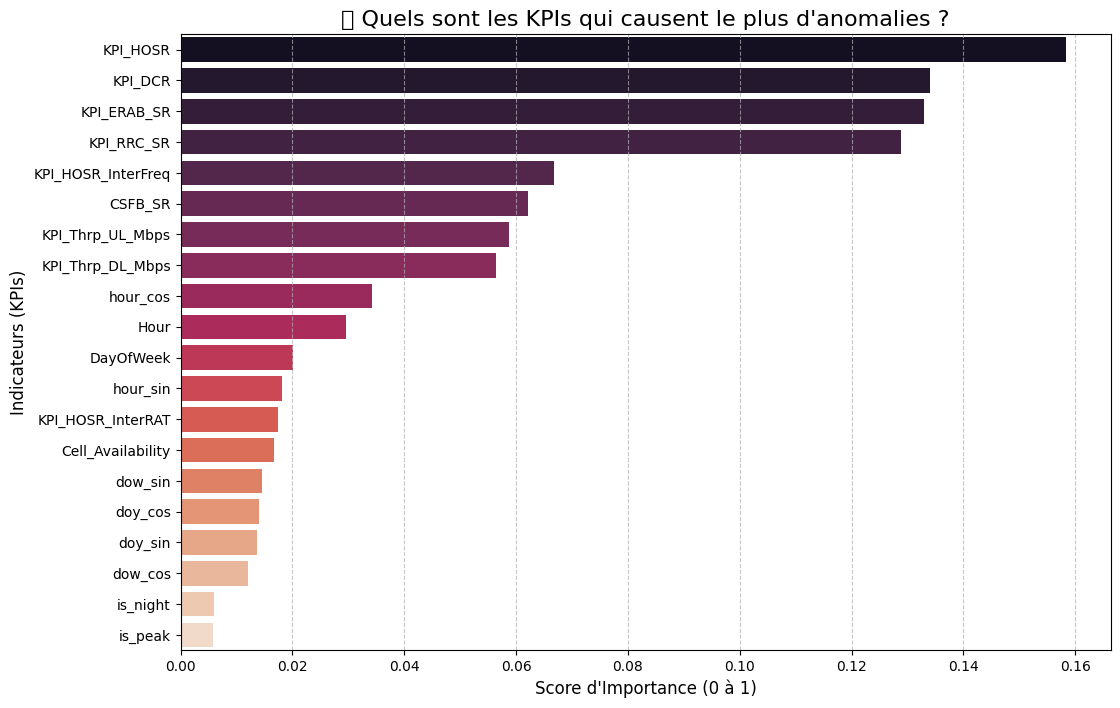


🔥 TOP 5 des indicateurs les plus impactants :
                  KPI  Importance
5            KPI_HOSR    0.158413
1             KPI_DCR    0.133943
2         KPI_ERAB_SR    0.132928
0          KPI_RRC_SR    0.128848
6  KPI_HOSR_InterFreq    0.066741


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("⏳ Préparation des données...")
# 1. On transforme notre texte en chiffres pour que l'IA comprenne (Anomalie = 1, Normal = 0)
y = df_ml['Statut_Reseau'].apply(lambda x: 1 if 'Anomalie' in x else 0)
X = X_scaled  # On réutilise nos données mathématiques mises à l'échelle

print("🌳 Entraînement du Random Forest en cours... (Cela peut prendre 1 à 2 minutes)")
# 2. Création et entraînement du modèle (100 arbres de décision)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X, y)

# 3. Extraction de l'importance de chaque KPI
importances = rf_model.feature_importances_
feature_df = pd.DataFrame({'KPI': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# 4. Création du graphique (Le Podium)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='KPI', data=feature_df, palette='rocket')
plt.title('🏆 Quels sont les KPIs qui causent le plus d\'anomalies ?', fontsize=16)
plt.xlabel('Score d\'Importance (0 à 1)', fontsize=12)
plt.ylabel('Indicateurs (KPIs)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Affichage du top 5 en texte
print("\n🔥 TOP 5 des indicateurs les plus impactants :")
print(feature_df.head(5))

**Sauvegarde Random Forest**

In [ ]:
import joblib, os

# ══════════════════════════════════════════════════════════════
# 💾 SAUVEGARDE — Random Forest Classifier
# ══════════════════════════════════════════════════════════════
SAVE_DIR = '/content/drive/MyDrive/P2M_Models'
os.makedirs(SAVE_DIR, exist_ok=True)

# Sauvegarder le modèle
joblib.dump(rf_model, f'{SAVE_DIR}/random_forest.pkl')

# Sauvegarder l'importance des features
feature_df.to_csv(f'{SAVE_DIR}/rf_feature_importance.csv', index=False)

print(f"✅ Random Forest sauvegardé     : {SAVE_DIR}/random_forest.pkl")
print(f"✅ Importance des features      : {SAVE_DIR}/rf_feature_importance.csv")
print(f"   Nombre d'arbres              : {rf_model.n_estimators}")
print(f"   Features utilisées           : {rf_model.n_features_in_}")

✅ Random Forest sauvegardé     : /content/drive/MyDrive/P2M_Models/random_forest.pkl
✅ Importance des features      : /content/drive/MyDrive/P2M_Models/rf_feature_importance.csv
   Nombre d'arbres              : 100
   Features utilisées           : 20


**Chargement Random Forest (après reconnexion)**

In [ ]:
import joblib, pandas as pd

# ══════════════════════════════════════════════════════════════
# 🔄 CHARGEMENT — Random Forest (après reconnexion)
# ══════════════════════════════════════════════════════════════
# ⚠️ Exécuter uniquement si tu te reconnectes sans réentraîner

SAVE_DIR = '/content/drive/MyDrive/P2M_Models'

rf_model   = joblib.load(f'{SAVE_DIR}/random_forest.pkl')
feature_df = pd.read_csv(f'{SAVE_DIR}/rf_feature_importance.csv')

print("✅ Random Forest rechargé")
print(f"   Nombre d'arbres    : {rf_model.n_estimators}")
print(f"   Features utilisées : {rf_model.n_features_in_}")
print("\n🔥 TOP 5 des KPIs les plus impactants :")
print(feature_df.head(5))

✅ Random Forest rechargé
   Nombre d'arbres    : 100
   Features utilisées : 20

🔥 TOP 5 des KPIs les plus impactants :
                  KPI  Importance
0            KPI_HOSR    0.158413
1             KPI_DCR    0.133943
2         KPI_ERAB_SR    0.132928
3          KPI_RRC_SR    0.128848
4  KPI_HOSR_InterFreq    0.066741


**Autoencoder**

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL AE-1 — ARCHITECTURE AUTOENCODER LSTM
# ══════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

SEQ_LEN_AE  = 24   # fenêtre temporelle : 24h (1 journée)
BATCH_SIZE  = 256
EPOCHS_AE   = 40
LR_AE       = 1e-3
HIDDEN_AE   = 64
LATENT_AE   = 16   # bottleneck : dimension de compression

N_FEATURES_AE = X_scaled.shape[1]
print(f"Features en entrée : {N_FEATURES_AE}")

# ── Dataset séquentiel ────────────────────────────────────────
class AEDataset(Dataset):
    def __init__(self, data: np.ndarray, seq_len: int):
        self.data    = data.astype('float32')
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        return torch.tensor(x), torch.tensor(x)  # input = target (reconstruction)

# ── Architecture Autoencoder LSTM ────────────────────────────
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, hidden_size, latent_size, seq_len):
        super().__init__()
        self.seq_len    = seq_len
        self.n_features = n_features

        # ENCODEUR
        self.encoder_lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )
        self.encoder_fc = nn.Linear(hidden_size, latent_size)

        # DÉCODEUR
        self.decoder_fc   = nn.Linear(latent_size, hidden_size)
        self.decoder_lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )
        self.output_layer = nn.Linear(hidden_size, n_features)

    def forward(self, x):
        # Encodage : on prend le dernier hidden state
        _, (h_n, _) = self.encoder_lstm(x)
        z = self.encoder_fc(h_n[-1])  # (batch, latent_size)

        # Décodage : on répète z sur seq_len steps
        dec_input = self.decoder_fc(z).unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _    = self.decoder_lstm(dec_input)
        x_hat     = self.output_layer(out)  # (batch, seq_len, n_features)
        return x_hat, z

model_ae = LSTMAutoencoder(
    n_features  = N_FEATURES_AE,
    hidden_size = HIDDEN_AE,
    latent_size = LATENT_AE,
    seq_len     = SEQ_LEN_AE
).to(DEVICE)

n_params = sum(p.numel() for p in model_ae.parameters())
print(f"Autoencoder LSTM : {n_params:,} paramètres")
print(model_ae)

Device : cuda
Features en entrée : 20
Autoencoder LSTM : 125,284 paramètres
LSTMAutoencoder(
  (encoder_lstm): LSTM(20, 64, num_layers=2, batch_first=True, dropout=0.2)
  (encoder_fc): Linear(in_features=64, out_features=16, bias=True)
  (decoder_fc): Linear(in_features=16, out_features=64, bias=True)
  (decoder_lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.2)
  (output_layer): Linear(in_features=64, out_features=20, bias=True)
)


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL AE-2 — SPLIT TRAIN/VAL (données normales uniquement)
# ══════════════════════════════════════════════════════════════
# ⚠️ IMPORTANT : un Autoencoder s'entraîne UNIQUEMENT sur des données
# normales. On exclut les anomalies déjà détectées par l'Isolation Forest.
# ══════════════════════════════════════════════════════════════

# Filtrer uniquement les lignes "Normal"
mask_normal = df_ml['Statut_Reseau'].str.contains('Normal')
X_normal    = X_scaled[mask_normal].values
print(f"Données normales : {X_normal.shape[0]:,} lignes sur {X_scaled.shape[0]:,} total")
print(f"Taux normal : {100*X_normal.shape[0]/X_scaled.shape[0]:.1f}%")

# Split chronologique 80/20
cut = int(len(X_normal) * 0.80)
X_train_ae = X_normal[:cut]
X_val_ae   = X_normal[cut:]
print(f"Train AE : {X_train_ae.shape[0]:,} | Val AE : {X_val_ae.shape[0]:,}")

# Datasets + DataLoaders
ds_train = AEDataset(X_train_ae, SEQ_LEN_AE)
ds_val   = AEDataset(X_val_ae,   SEQ_LEN_AE)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Batches train : {len(dl_train)} | Batches val : {len(dl_val)}")

Données normales : 1,939,920 lignes sur 1,959,516 total
Taux normal : 99.0%
Train AE : 1,551,936 | Val AE : 387,984
Batches train : 6063 | Batches val : 1516


In [ ]:
import time

optimizer_ae = torch.optim.Adam(model_ae.parameters(), lr=LR_AE)
scheduler_ae = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ae, mode='min', factor=0.5, patience=5
)
criterion_ae = nn.MSELoss()

best_val_loss = float('inf')
history_ae    = {'train': [], 'val': []}

print(f"Entraînement sur {EPOCHS_AE} epochs | Device : {DEVICE}")
print("═"*55)

for epoch in range(1, EPOCHS_AE + 1):
    t0 = time.time()

    # ── TRAIN ─────────────────────────────────────────────────
    model_ae.train()
    train_loss = 0.0
    for X_b, y_b in dl_train:
        X_b = X_b.to(DEVICE)
        optimizer_ae.zero_grad()
        x_hat, _ = model_ae(X_b)
        loss      = criterion_ae(x_hat, X_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ae.parameters(), max_norm=1.0)
        optimizer_ae.step()
        train_loss += loss.item()
    train_loss /= len(dl_train)

    # ── VALIDATION ────────────────────────────────────────────
    model_ae.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_b, _ in dl_val:
            X_b    = X_b.to(DEVICE)
            x_hat, _ = model_ae(X_b)
            val_loss += criterion_ae(x_hat, X_b).item()
    val_loss /= len(dl_val)

    history_ae['train'].append(train_loss)
    history_ae['val'].append(val_loss)
    scheduler_ae.step(val_loss)

    # Sauvegarde best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_ae.state_dict(), '/tmp/ae_best.pth')
        marker = " ← ✅ best"
    else:
        marker = ""

    elapsed = time.time() - t0
    print(f"Epoch {epoch:02d}/{EPOCHS_AE} | "
          f"Train: {train_loss:.6f} | Val: {val_loss:.6f} | "
          f"{elapsed:.1f}s{marker}")

# Recharger les meilleurs poids
model_ae.load_state_dict(torch.load('/tmp/ae_best.pth'))
model_ae.eval()
print(f"\n✅ Meilleur val_loss : {best_val_loss:.6f}")

Entraînement sur 40 epochs | Device : cuda
═══════════════════════════════════════════════════════
Epoch 01/40 | Train: 0.084206 | Val: 0.080114 | 80.7s ← ✅ best
Epoch 02/40 | Train: 0.084995 | Val: 0.085279 | 81.0s
Epoch 03/40 | Train: 0.084311 | Val: 0.084061 | 80.1s
Epoch 04/40 | Train: 0.082136 | Val: 0.081741 | 79.4s
Epoch 05/40 | Train: 0.082546 | Val: 0.094695 | 80.2s
Epoch 06/40 | Train: 0.082863 | Val: 0.078551 | 79.7s ← ✅ best
Epoch 07/40 | Train: 0.079963 | Val: 0.077433 | 81.5s ← ✅ best
Epoch 08/40 | Train: 0.079796 | Val: 0.072894 | 80.7s ← ✅ best
Epoch 09/40 | Train: 0.078625 | Val: 0.077897 | 81.9s
Epoch 10/40 | Train: 0.078702 | Val: 0.082867 | 81.4s
Epoch 11/40 | Train: 0.078279 | Val: 0.081673 | 80.0s
Epoch 12/40 | Train: 0.077869 | Val: 0.082115 | 80.9s
Epoch 13/40 | Train: 0.077312 | Val: 0.077447 | 79.2s
Epoch 14/40 | Train: 0.077191 | Val: 0.080407 | 79.8s
Epoch 15/40 | Train: 0.069211 | Val: 0.073274 | 80.5s
Epoch 16/40 | Train: 0.069233 | Val: 0.078945 | 79.5s
E

KeyboardInterrupt: 

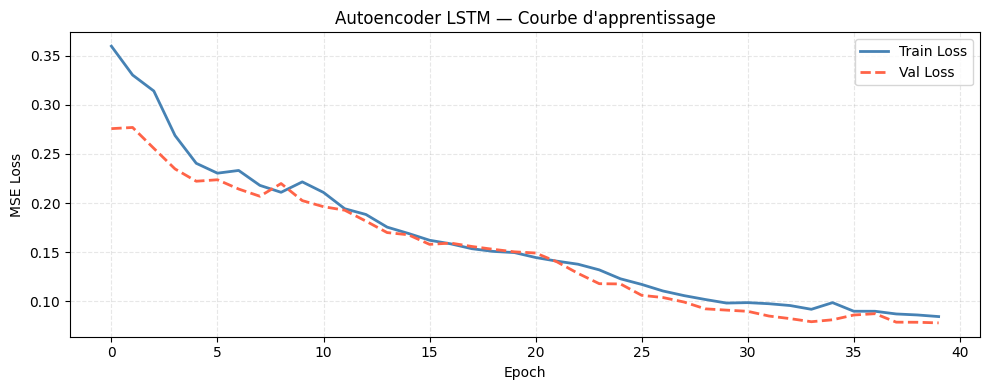

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL AE-4 — COURBE D'APPRENTISSAGE
# ══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(history_ae['train'], label='Train Loss', color='steelblue', lw=2)
plt.plot(history_ae['val'],   label='Val Loss',   color='tomato',    lw=2, ls='--')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder LSTM — Courbe d\'apprentissage')
plt.legend()
plt.grid(True, alpha=0.3, ls='--')
plt.tight_layout()
plt.savefig('/content/ae_learning_curve.png', dpi=130)
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL AE-5 — RECONSTRUCTION ERROR & SEUIL D'ANOMALIE
# C'est le cœur de la détection : toute erreur > seuil = anomalie
# ══════════════════════════════════════════════════════════════

def compute_reconstruction_errors(model, data_array, seq_len, batch_size=512):
    """
    Calcule l'erreur de reconstruction MSE par séquence.
    Retourne un array de shape (N - seq_len,)
    """
    model.eval()
    dataset = AEDataset(data_array, seq_len)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    errors  = []

    with torch.no_grad():
        for X_b, _ in loader:
            X_b   = X_b.to(DEVICE)
            x_hat, _ = model(X_b)
            # MSE par séquence (moyenne sur timesteps et features)
            mse = ((X_b - x_hat) ** 2).mean(dim=(1, 2))
            errors.extend(mse.cpu().numpy())

    return np.array(errors)

# Calcul sur les données de validation (normales → distribution de référence)
print("Calcul des erreurs de reconstruction sur Val (données normales)...")
recon_errors_val = compute_reconstruction_errors(model_ae, X_val_ae, SEQ_LEN_AE)

# Calcul sur TOUT le dataset (normales + anomalies)
print("Calcul sur l'ensemble du dataset...")
recon_errors_all = compute_reconstruction_errors(model_ae, X_scaled.values, SEQ_LEN_AE)

# ── Définition du seuil (percentile 95 sur données normales) ──
THRESHOLD_95  = np.percentile(recon_errors_val, 95)
THRESHOLD_99  = np.percentile(recon_errors_val, 99)
THRESHOLD_999 = np.percentile(recon_errors_val, 99.9)

print(f"\n📊 Distribution des erreurs (données normales) :")
print(f"   Mean  : {recon_errors_val.mean():.6f}")
print(f"   Std   : {recon_errors_val.std():.6f}")
print(f"   P95   : {THRESHOLD_95:.6f}  ← seuil recommandé (5% FP)")
print(f"   P99   : {THRESHOLD_99:.6f}  ← seuil strict     (1% FP)")
print(f"   P99.9 : {THRESHOLD_999:.6f} ← seuil très strict")

# Choisir le seuil opérationnel
THRESHOLD_AE = THRESHOLD_95  # ajustable selon tolérance aux fausses alarmes
print(f"\n✅ Seuil opérationnel choisi : {THRESHOLD_AE:.6f} (P95)")

Calcul des erreurs de reconstruction sur Val (données normales)...
Calcul sur l'ensemble du dataset...

📊 Distribution des erreurs (données normales) :
   Mean  : 0.077735
   Std   : 0.672671
   P95   : 0.181654  ← seuil recommandé (5% FP)
   P99   : 0.517695  ← seuil strict     (1% FP)
   P99.9 : 3.370781 ← seuil très strict

✅ Seuil opérationnel choisi : 0.181654 (P95)


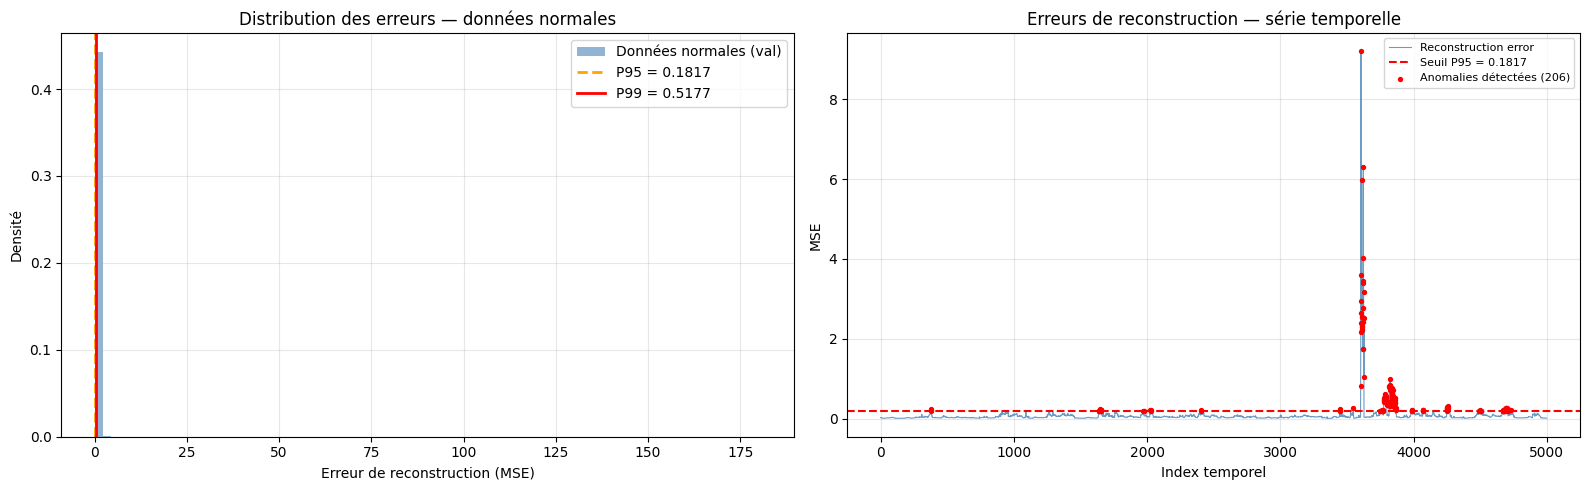


📊 Résultats Autoencoder LSTM :
   Seuil   : 0.181654 (P95 sur données normales)
   Anomalies détectées : 143,285 / 1,959,516 (7.31%)


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL AE-6 — VISUALISATION + LABELS D'ANOMALIE
# ══════════════════════════════════════════════════════════════
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Distribution des erreurs ──────────────────────────────────
ax = axes[0]
ax.hist(recon_errors_val, bins=80, alpha=0.6, color='steelblue',
        label='Données normales (val)', density=True)
ax.axvline(THRESHOLD_95,  color='orange', lw=2, ls='--', label=f'P95 = {THRESHOLD_95:.4f}')
ax.axvline(THRESHOLD_99,  color='red',    lw=2, ls='-',  label=f'P99 = {THRESHOLD_99:.4f}')
ax.set_xlabel('Erreur de reconstruction (MSE)')
ax.set_ylabel('Densité')
ax.set_title('Distribution des erreurs — données normales')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Série temporelle des erreurs sur tout le dataset ─────────
ax = axes[1]
N_plot = min(5000, len(recon_errors_all))
ax.plot(recon_errors_all[:N_plot], color='steelblue', lw=0.8, alpha=0.8, label='Reconstruction error')
ax.axhline(THRESHOLD_AE, color='red', lw=1.5, ls='--', label=f'Seuil P95 = {THRESHOLD_AE:.4f}')
anomaly_idx = np.where(recon_errors_all[:N_plot] > THRESHOLD_AE)[0]
ax.scatter(anomaly_idx, recon_errors_all[anomaly_idx],
           color='red', s=8, zorder=5, label=f'Anomalies détectées ({len(anomaly_idx)})')
ax.set_xlabel('Index temporel')
ax.set_ylabel('MSE')
ax.set_title('Erreurs de reconstruction — série temporelle')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/ae_anomaly_detection.png', dpi=130)
plt.show()

# ── Ajout des labels AE dans df_ml ───────────────────────────
# On aligne avec df_ml (offset dû à la fenêtre séquentielle)
ae_labels = np.zeros(len(X_scaled), dtype=int)
ae_labels[SEQ_LEN_AE:SEQ_LEN_AE + len(recon_errors_all)] = (recon_errors_all > THRESHOLD_AE).astype(int)
df_ml['AE_Anomalie']    = ae_labels
df_ml['AE_Recon_Error'] = np.nan
df_ml.loc[df_ml.index[SEQ_LEN_AE:SEQ_LEN_AE + len(recon_errors_all)], 'AE_Recon_Error'] = recon_errors_all

n_ae_anomalies = ae_labels.sum()
print(f"\n📊 Résultats Autoencoder LSTM :")
print(f"   Seuil   : {THRESHOLD_AE:.6f} (P95 sur données normales)")
print(f"   Anomalies détectées : {n_ae_anomalies:,} / {len(X_scaled):,} "
      f"({100*n_ae_anomalies/len(X_scaled):.2f}%)")

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL AE-7 — CROISEMENT IF vs AE → BASE DU VOTE MAJORITAIRE
# ══════════════════════════════════════════════════════════════

# Labels IF (déjà dans df_ml)
df_ml['IF_Anomalie'] = (df_ml['Statut_Reseau'].str.contains('Anomalie')).astype(int)

# Vote : anomalie confirmée si les 2 modèles s'accordent
df_ml['Anomalie_Confirmee'] = ((df_ml['IF_Anomalie'] == 1) & (df_ml['AE_Anomalie'] == 1)).astype(int)

# Statistiques croisées
total      = len(df_ml)
n_if       = df_ml['IF_Anomalie'].sum()
n_ae       = df_ml['AE_Anomalie'].sum()
n_both     = df_ml['Anomalie_Confirmee'].sum()
n_if_only  = ((df_ml['IF_Anomalie'] == 1) & (df_ml['AE_Anomalie'] == 0)).sum()
n_ae_only  = ((df_ml['IF_Anomalie'] == 0) & (df_ml['AE_Anomalie'] == 1)).sum()

print("╔══════════════════════════════════════════════════════╗")
print("║      COMPARAISON Isolation Forest vs Autoencoder    ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Isolation Forest seul     : {n_if:>8,} ({100*n_if/total:.2f}%)        ║")
print(f"║  Autoencoder seul          : {n_ae:>8,} ({100*n_ae/total:.2f}%)        ║")
print(f"║  Confirmées par les 2      : {n_both:>8,} ({100*n_both/total:.2f}%)  ← VRAIS INCIDENTS ║")
print(f"║  IF seul (suspect FP)      : {n_if_only:>8,} ({100*n_if_only/total:.2f}%)        ║")
print(f"║  AE seul (suspect FP)      : {n_ae_only:>8,} ({100*n_ae_only/total:.2f}%)        ║")
print("╚══════════════════════════════════════════════════════╝")

# Top cellules les plus touchées
print("\n🔴 Top 10 cellules avec le plus d'anomalies confirmées :")
top_cells = (df_ml[df_ml['Anomalie_Confirmee'] == 1]
             .groupby('Cell_Name')
             .size()
             .sort_values(ascending=False)
             .head(10))
print(top_cells.to_string())

╔══════════════════════════════════════════════════════╗
║      COMPARAISON Isolation Forest vs Autoencoder    ║
╠══════════════════════════════════════════════════════╣
║  Isolation Forest seul     :   19,596 (1.00%)        ║
║  Autoencoder seul          :  143,285 (7.31%)        ║
║  Confirmées par les 2      :    8,709 (0.44%)  ← VRAIS INCIDENTS ║
║  IF seul (suspect FP)      :   10,887 (0.56%)        ║
║  AE seul (suspect FP)      :  134,576 (6.87%)        ║
╚══════════════════════════════════════════════════════╝

🔴 Top 10 cellules avec le plus d'anomalies confirmées :
Cell_Name
TINKOTO_e1              85
SAMINE_ESCALE_e6_a      85
KEUR_MASSAR03_T2        67
DAMBALA_SEKHOTO_e71     63
SENO_ISSAGA_e73         60
TINKOTO_e71             58
SAIENSOUTOU_e5          57
DAMBALA_SEKHOTO_e6_a    57
TINKOTO_e24             55
MAMAKHONO_e5_c          53


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL AE-8 — SAUVEGARDE AUTOENCODER
# ══════════════════════════════════════════════════════════════
import joblib, json, os

SAVE_DIR_AE = '/content/drive/MyDrive/P2M_Models/Autoencoder_LSTM'
os.makedirs(SAVE_DIR_AE, exist_ok=True)

# Modèle PyTorch
torch.save({
    'state_dict'  : model_ae.state_dict(),
    'n_features'  : N_FEATURES_AE,
    'hidden_size' : HIDDEN_AE,
    'latent_size' : LATENT_AE,
    'seq_len'     : SEQ_LEN_AE,
    'threshold_95': float(THRESHOLD_95),
    'threshold_99': float(THRESHOLD_99),
    'threshold_op': float(THRESHOLD_AE),
}, f'{SAVE_DIR_AE}/lstm_ae.pth')

# Config JSON
config_ae = {
    'n_features'   : N_FEATURES_AE,
    'hidden_size'  : HIDDEN_AE,
    'latent_size'  : LATENT_AE,
    'seq_len'      : SEQ_LEN_AE,
    'threshold_95' : float(THRESHOLD_95),
    'threshold_99' : float(THRESHOLD_99),
    'threshold_op' : float(THRESHOLD_AE),
    'best_val_loss': float(best_val_loss),
    'feature_names': list(X_scaled.columns),
}
with open(f'{SAVE_DIR_AE}/config_ae.json', 'w') as f:
    json.dump(config_ae, f, indent=2)

# df_ml mis à jour avec les colonnes AE
df_ml.to_csv(f'{SAVE_DIR_AE}/df_ml_avec_AE.csv', index=False)

print(f"✅ Autoencoder sauvegardé dans : {SAVE_DIR_AE}")
print(f"   lstm_ae.pth    — poids + config + seuils")
print(f"   config_ae.json — paramètres reproductibles")
print(f"   df_ml_avec_AE.csv — dataset avec colonnes AE_Anomalie, AE_Recon_Error, Anomalie_Confirmee")

✅ Autoencoder sauvegardé dans : /content/drive/MyDrive/P2M_Models/Autoencoder_LSTM
   lstm_ae.pth    — poids + config + seuils
   config_ae.json — paramètres reproductibles
   df_ml_avec_AE.csv — dataset avec colonnes AE_Anomalie, AE_Recon_Error, Anomalie_Confirmee


### 🔄 Chargement Autoencoder LSTM (après reconnexion)

In [ ]:
# ══════════════════════════════════════════════════════════════
# 🔄 CHARGEMENT — Autoencoder LSTM (après reconnexion Colab)
# ══════════════════════════════════════════════════════════════
# ⚠️ Exécuter uniquement si tu te reconnectes sans réentraîner
# ✅ Cellule AUTONOME : la classe LSTMAutoencoder est définie ici
# ══════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import json, joblib, os, pandas as pd
import numpy as np

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

# ── Définition de l'architecture (obligatoire pour torch.load) ─
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, hidden_size, latent_size, seq_len):
        super().__init__()
        self.seq_len    = seq_len
        self.n_features = n_features
        # ENCODEUR
        self.encoder_lstm = nn.LSTM(
            input_size=n_features, hidden_size=hidden_size,
            num_layers=2, batch_first=True, dropout=0.2
        )
        self.encoder_fc = nn.Linear(hidden_size, latent_size)
        # DÉCODEUR
        self.decoder_fc   = nn.Linear(latent_size, hidden_size)
        self.decoder_lstm = nn.LSTM(
            input_size=hidden_size, hidden_size=hidden_size,
            num_layers=2, batch_first=True, dropout=0.2
        )
        self.output_layer = nn.Linear(hidden_size, n_features)

    def forward(self, x):
        _, (h_n, _) = self.encoder_lstm(x)
        z = self.encoder_fc(h_n[-1])
        dec_input = self.decoder_fc(z).unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _    = self.decoder_lstm(dec_input)
        x_hat     = self.output_layer(out)
        return x_hat, z

print("✅ Classe LSTMAutoencoder définie")

SAVE_DIR_AE = '/content/drive/MyDrive/P2M_Models/Autoencoder_LSTM'

# ── 1. Vérifier que le dossier Drive existe ───────────────────
if not os.path.exists(SAVE_DIR_AE):
    print(f"ERREUR : dossier introuvable -> {SAVE_DIR_AE}")
    print("Vérifie que Drive est monté : from google.colab import drive; drive.mount('/content/drive')")
    raise FileNotFoundError(f"{SAVE_DIR_AE} introuvable")

files_present = os.listdir(SAVE_DIR_AE)
print(f"\nFichiers trouvés dans {SAVE_DIR_AE} :")
for fname in sorted(files_present):
    size_kb = os.path.getsize(os.path.join(SAVE_DIR_AE, fname)) / 1024
    print(f"  {fname:<35} {size_kb:>8.1f} Ko")

# ── 2. Charger la config JSON ─────────────────────────────────
config_path = f'{SAVE_DIR_AE}/config_ae.json'
if not os.path.exists(config_path):
    raise FileNotFoundError(f"config_ae.json introuvable dans {SAVE_DIR_AE}")

with open(config_path) as f:
    config_ae = json.load(f)

N_FEATURES_AE = config_ae['n_features']
HIDDEN_AE     = config_ae['hidden_size']
LATENT_AE     = config_ae['latent_size']
SEQ_LEN_AE    = config_ae['seq_len']
THRESHOLD_95  = config_ae['threshold_95']
THRESHOLD_99  = config_ae['threshold_99']
THRESHOLD_AE  = config_ae['threshold_op']

print(f"\nConfig chargée :")
print(f"  n_features   : {N_FEATURES_AE}")
print(f"  hidden_size  : {HIDDEN_AE}")
print(f"  latent_size  : {LATENT_AE}")
print(f"  seq_len      : {SEQ_LEN_AE}h")
print(f"  Seuil 95%    : {THRESHOLD_95:.6f}")
print(f"  Seuil 99%    : {THRESHOLD_99:.6f}")
print(f"  Seuil opérat.: {THRESHOLD_AE:.6f}")

# ── 3. Reconstruire l'architecture et charger les poids ───────
pth_path = f'{SAVE_DIR_AE}/lstm_ae.pth'
if not os.path.exists(pth_path):
    raise FileNotFoundError(f"lstm_ae.pth introuvable dans {SAVE_DIR_AE}")

model_ae = LSTMAutoencoder(
    n_features  = N_FEATURES_AE,
    hidden_size = HIDDEN_AE,
    latent_size = LATENT_AE,
    seq_len     = SEQ_LEN_AE
).to(DEVICE)

ckpt = torch.load(pth_path, map_location=DEVICE)
model_ae.load_state_dict(ckpt['state_dict'])
model_ae.eval()

n_params = sum(p.numel() for p in model_ae.parameters())
print(f"\n✅ Autoencoder LSTM rechargé ({n_params:,} paramètres)")

# ── 4. Recharger df_ml avec colonnes AE ───────────────────────
csv_path = f'{SAVE_DIR_AE}/df_ml_avec_AE.csv'
if os.path.exists(csv_path):
    df_ml = pd.read_csv(csv_path)
    print(f"✅ df_ml rechargé : {df_ml.shape}")
    ae_cols = [c for c in ['AE_Anomalie','AE_Recon_Error','Anomalie_Confirmee','IF_Anomalie'] if c in df_ml.columns]
    print(f"   Colonnes AE présentes : {ae_cols}")
else:
    print("⚠️ df_ml_avec_AE.csv introuvable — recharger df_ml manuellement")

print(f"\n{'='*55}")
print(f"  RECHARGEMENT AUTOENCODER TERMINÉ")
print(f"{'='*55}")
print(f"  model_ae     : chargé en mode eval() sur {DEVICE}")
print(f"  THRESHOLD_AE : {THRESHOLD_AE:.6f} (seuil opérationnel)")
print(f"  THRESHOLD_95 : {THRESHOLD_95:.6f}")
print(f"  THRESHOLD_99 : {THRESHOLD_99:.6f}")
print(f"{'='*55}")


Device : cuda
✅ Classe LSTMAutoencoder définie

Fichiers trouvés dans /content/drive/MyDrive/P2M_Models/Autoencoder_LSTM :
  config_ae.json                           0.6 Ko
  df_ml_avec_AE.csv                   569197.9 Ko
  lstm_ae.pth                            494.0 Ko

Config chargée :
  n_features   : 20
  hidden_size  : 64
  latent_size  : 16
  seq_len      : 24h
  Seuil 95%    : 0.181654
  Seuil 99%    : 0.517695
  Seuil opérat.: 0.181654

✅ Autoencoder LSTM rechargé (125,284 paramètres)
✅ df_ml rechargé : (1959516, 33)
   Colonnes AE présentes : ['AE_Anomalie', 'AE_Recon_Error', 'Anomalie_Confirmee', 'IF_Anomalie']

  RECHARGEMENT AUTOENCODER TERMINÉ
  model_ae     : chargé en mode eval() sur cuda
  THRESHOLD_AE : 0.181654 (seuil opérationnel)
  THRESHOLD_95 : 0.181654
  THRESHOLD_99 : 0.517695


**XGBOOST_DCR**

🔧 Construction des features DCR...
✅ Split temporel : Train=1,179,182 | Test=294,796
   Train jusqu'à : 2025-06-04 16:00:00
   Test  à partir: 2025-06-04 16:00:00
   Features utilisées : 32/32
[0]	validation_0-rmse:0.07138	validation_1-rmse:0.07074
[50]	validation_0-rmse:0.06040	validation_1-rmse:0.06044
[100]	validation_0-rmse:0.05915	validation_1-rmse:0.05991
[150]	validation_0-rmse:0.05841	validation_1-rmse:0.05983
[200]	validation_0-rmse:0.05783	validation_1-rmse:0.05984
[250]	validation_0-rmse:0.05735	validation_1-rmse:0.05983
[300]	validation_0-rmse:0.05694	validation_1-rmse:0.05989
[350]	validation_0-rmse:0.05656	validation_1-rmse:0.05992
[400]	validation_0-rmse:0.05621	validation_1-rmse:0.05993
[450]	validation_0-rmse:0.05589	validation_1-rmse:0.05996
[500]	validation_0-rmse:0.05560	validation_1-rmse:0.05998
[550]	validation_0-rmse:0.05533	validation_1-rmse:0.06001
[600]	validation_0-rmse:0.05507	validation_1-rmse:0.06003
[650]	validation_0-rmse:0.05484	validation_1-rmse:0.0600

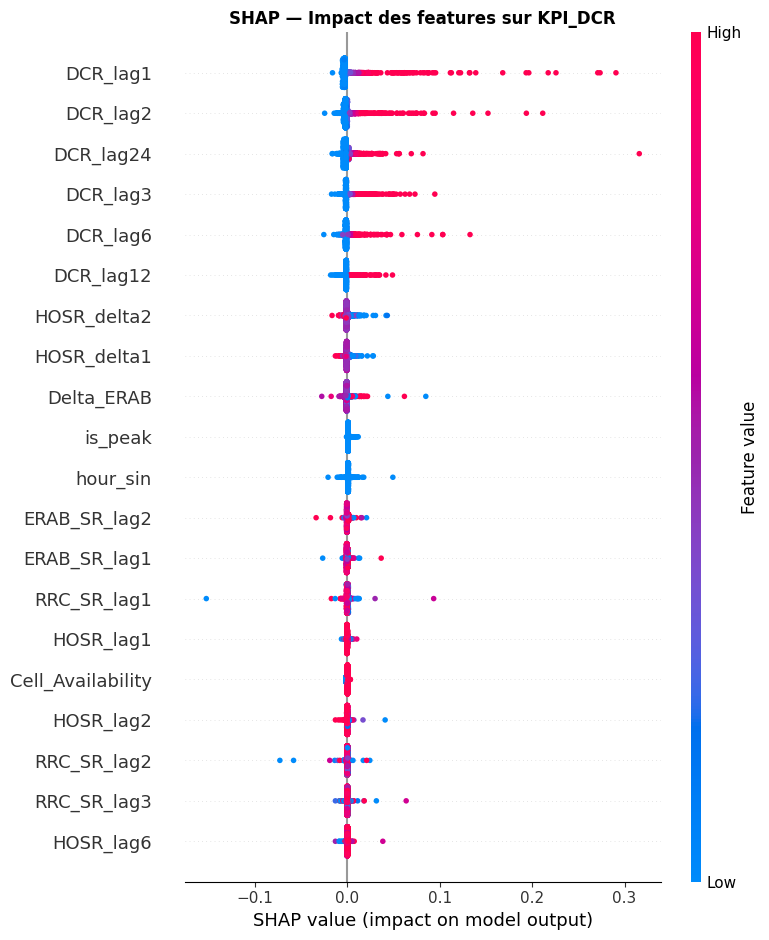


🔥 Top 10 features par importance SHAP :
    feature  shap_mean
   DCR_lag1   0.006675
   DCR_lag2   0.004347
  DCR_lag24   0.003158
   DCR_lag3   0.002870
   DCR_lag6   0.002482
  DCR_lag12   0.001988
HOSR_delta2   0.001548
HOSR_delta1   0.001361
 Delta_ERAB   0.001332
    is_peak   0.001191


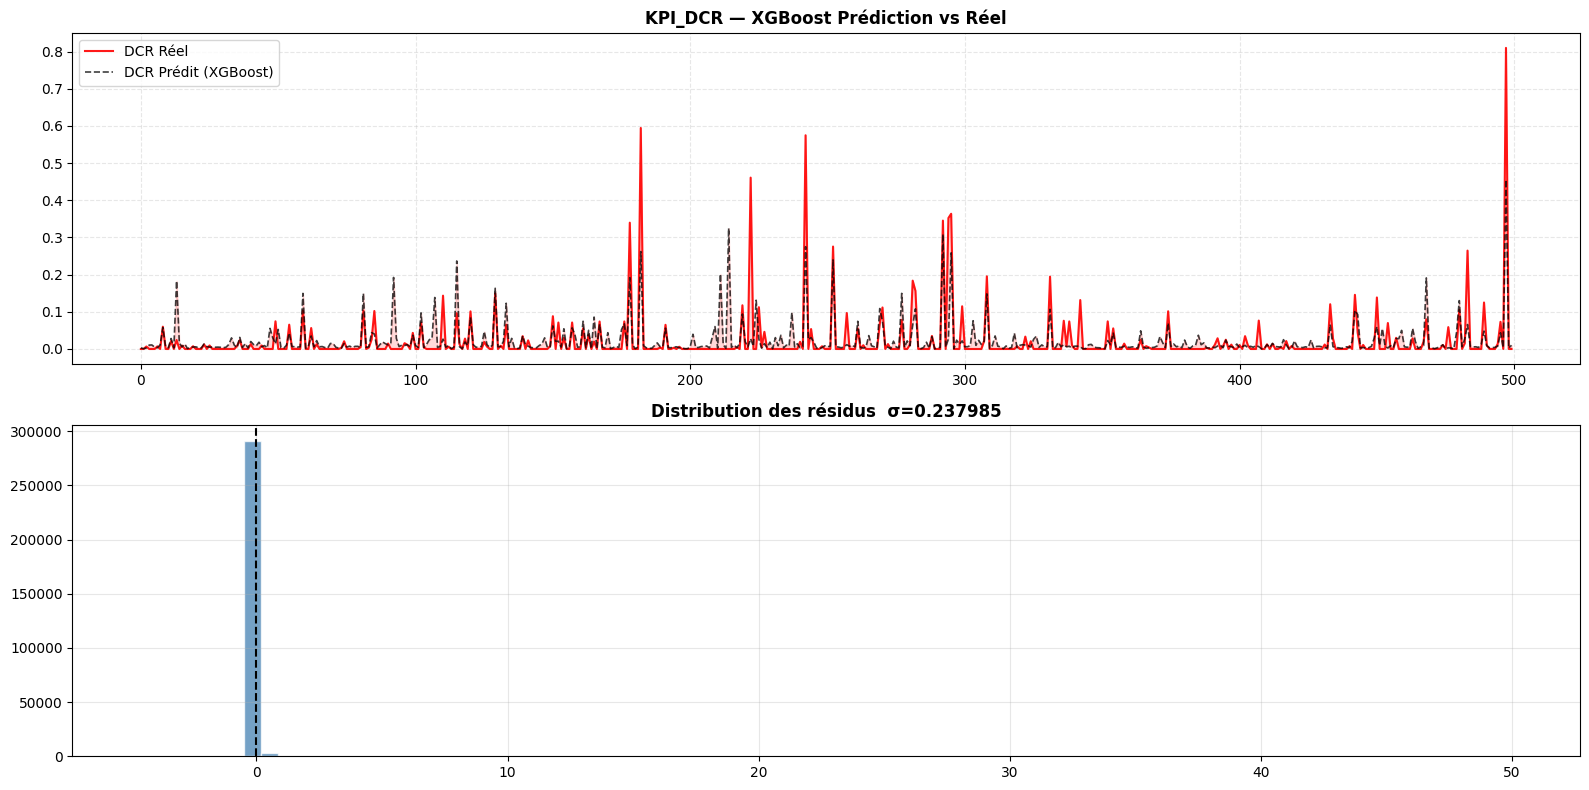

✅ XGBoost DCR sauvegardé : /content/drive/MyDrive/P2M_Models/xgboost_dcr.pkl


In [ ]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
import shap
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════
# ÉTAPE 1 — Feature Engineering spécifique DCR
# ══════════════════════════════════════════════════════════════
def build_dcr_features(df_ml):
    df = df_ml.sort_values(['Cell_Name', 'Time']).copy()

    # ── Lags HOSR (cause principale, lag 1-3h) ────────────────
    for lag in [1, 2, 3, 6]:
        df[f'HOSR_lag{lag}'] = df.groupby('Cell_Name')['KPI_HOSR'].shift(lag)
        df[f'HOSR_InterFreq_lag{lag}'] = df.groupby('Cell_Name')['KPI_HOSR_InterFreq'].shift(lag)

    for lag in [1, 2]:
        df[f'HOSR_InterRAT_lag{lag}'] = df.groupby('Cell_Name')['KPI_HOSR_InterRAT'].shift(lag)

    # ── Lags RRC_SR (congestion signalisation) ────────────────
    for lag in [1, 2, 3]:
        df[f'RRC_SR_lag{lag}'] = df.groupby('Cell_Name')['KPI_RRC_SR'].shift(lag)

    # ── Lags ERAB_SR ──────────────────────────────────────────
    for lag in [1, 2]:
        df[f'ERAB_SR_lag{lag}'] = df.groupby('Cell_Name')['KPI_ERAB_SR'].shift(lag)

    # ── Autorégressif DCR ─────────────────────────────────────
    for lag in [1, 2, 3, 6, 12, 24]:
        df[f'DCR_lag{lag}'] = df.groupby('Cell_Name')['KPI_DCR'].shift(lag)

    # ── Rolling statistics HOSR (tendance sur 3h et 6h) ──────
    df['HOSR_roll3_mean'] = df.groupby('Cell_Name')['KPI_HOSR'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    df['HOSR_roll6_min']  = df.groupby('Cell_Name')['KPI_HOSR'].transform(
        lambda x: x.shift(1).rolling(6, min_periods=1).min())
    df['HOSR_roll3_std']  = df.groupby('Cell_Name')['KPI_HOSR'].transform(
        lambda x: x.shift(1).rolling(6, min_periods=1).std().fillna(0))

    # ── Delta HOSR (vitesse de dégradation) ───────────────────
    # Si HOSR chute rapidement → risque de DCR imminent
    df['HOSR_delta1'] = df.groupby('Cell_Name')['KPI_HOSR'].diff(1)
    df['HOSR_delta2'] = df.groupby('Cell_Name')['KPI_HOSR'].diff(2)

    # ── Delta_ERAB ────────────────────────────────────────────
    df['Delta_ERAB']  = df['KPI_ERAB_SR'] - df['KPI_RRC_SR']

    # ── Features temporelles ──────────────────────────────────
    hour = pd.to_datetime(df['Time']).dt.hour.astype('float32')
    dow  = pd.to_datetime(df['Time']).dt.dayofweek.astype('float32')
    df['hour_sin'] = np.sin(2 * np.pi * hour / 24).astype('float32')
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24).astype('float32')
    df['dow_sin']  = np.sin(2 * np.pi * dow  / 7).astype('float32')
    df['dow_cos']  = np.cos(2 * np.pi * dow  / 7).astype('float32')
    df['is_peak']  = ((hour >= 7) & (hour <= 21)).astype('float32')

    # ── Transformer la cible : log1p ──────────────────────────
    df['DCR_log'] = np.log1p(df['KPI_DCR'])

    df.dropna(inplace=True)
    return df

# ══════════════════════════════════════════════════════════════
# ÉTAPE 2 — Split temporel strict (pas de fuite future→passé)
# ══════════════════════════════════════════════════════════════
DCR_FEATURES = [
    # Tier 1 — causes directes
    'HOSR_lag1', 'HOSR_lag2', 'HOSR_lag3', 'HOSR_lag6',
    'HOSR_InterFreq_lag1', 'HOSR_InterFreq_lag2',
    'HOSR_InterRAT_lag1',  'HOSR_InterRAT_lag2',
    'RRC_SR_lag1', 'RRC_SR_lag2', 'RRC_SR_lag3',
    # Tier 2 — indicateurs qualité radio
    'ERAB_SR_lag1', 'ERAB_SR_lag2',
    'Delta_ERAB',
    'Cell_Availability',
    'CSFB_SR',
    # Autorégressif
    'DCR_lag1', 'DCR_lag2', 'DCR_lag3',
    'DCR_lag6', 'DCR_lag12', 'DCR_lag24',
    # Rolling statistics
    'HOSR_roll3_mean', 'HOSR_roll6_min', 'HOSR_roll3_std',
    'HOSR_delta1', 'HOSR_delta2',
    # Contexte temporel
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'is_peak',
]

def split_temporal(df, train_ratio=0.80):
    """
    Split temporel strict : les 80% premières heures en train,
    les 20% dernières en test.
    Évite que le modèle voie le futur pendant l'entraînement.
    """
    df_sorted = df.sort_values('Time')
    cutoff    = int(len(df_sorted) * train_ratio)
    df_train  = df_sorted.iloc[:cutoff]
    df_test   = df_sorted.iloc[cutoff:]
    print(f"✅ Split temporel : Train={len(df_train):,} | Test={len(df_test):,}")
    print(f"   Train jusqu'à : {df_train['Time'].max()}")
    print(f"   Test  à partir: {df_test['Time'].min()}")
    return df_train, df_test

# ══════════════════════════════════════════════════════════════
# ÉTAPE 3 — Entraînement XGBoost optimisé pour DCR
# ══════════════════════════════════════════════════════════════
def train_xgboost_dcr(df_ml):
    print("🔧 Construction des features DCR...")
    df_feat   = build_dcr_features(df_ml)
    df_train, df_test = split_temporal(df_feat)

    feats_ok = [f for f in DCR_FEATURES if f in df_feat.columns]
    print(f"   Features utilisées : {len(feats_ok)}/{len(DCR_FEATURES)}")

    X_train = df_train[feats_ok].values
    y_train = df_train['DCR_log'].values   # cible log-transformée
    X_test  = df_test[feats_ok].values
    y_test  = df_test['DCR_log'].values

    # ── Hyperparamètres XGBoost pour DCR ─────────────────────
    # max_depth=6        : arbres profonds pour capturer les interactions
    # min_child_weight=10: évite l'overfitting sur les rares pics DCR
    # subsample=0.8      : bagging pour robustesse
    # colsample_bytree   : évite la dépendance sur une seule feature
    # reg_alpha (L1)     : sparse solution, ignore les features non pertinentes
    # reg_lambda (L2)    : pénalise les poids extrêmes
    params = {
        'objective'        : 'reg:squarederror',
        'eval_metric'      : 'rmse',
        'n_estimators'     : 1000,
        'learning_rate'    : 0.05,
        'max_depth'        : 6,
        'min_child_weight' : 10,
        'subsample'        : 0.8,
        'colsample_bytree' : 0.7,
        'reg_alpha'        : 0.1,
        'reg_lambda'       : 1.0,
        'tree_method'      : 'hist',   # Using 'hist' as 'gpu_hist' is not recognized
        'device'           : 'cuda' if __import__('torch').cuda.is_available() else 'cpu',
        'random_state'     : 42,
        'verbosity'        : 0,
    }

    model_xgb = xgb.XGBRegressor(**params)
    model_xgb.fit(
        X_train, y_train,
        eval_set        = [(X_train, y_train), (X_test, y_test)],
        #early_stopping_rounds = 50,
        verbose         = 50,
    )

    # ── Évaluation ────────────────────────────────────────────
    preds_log = model_xgb.predict(X_test)
    preds_real = np.expm1(preds_log)
    trues_real = np.expm1(y_test)

    mae  = np.mean(np.abs(trues_real - preds_real))
    rmse = np.sqrt(mean_squared_error(trues_real, preds_real))
    r2   = r2_score(trues_real, preds_real)
    nrm  = rmse / (np.mean(trues_real) + 1e-8) * 100

    print(f"\n{'─'*55}")
    print(f"  KPI_DCR — XGBoost")
    print(f"  MAE  = {mae:.6f}")
    print(f"  RMSE = {rmse:.6f}")
    print(f"  NRMSE= {nrm:.2f}%")
    print(f"  R²   = {r2:.4f}")
    print(f"{'─'*55}")

    return model_xgb, preds_real, trues_real, feats_ok, df_test

# ══════════════════════════════════════════════════════════════
# ÉTAPE 4 — SHAP : comprendre ce qui cause le DCR
# ══════════════════════════════════════════════════════════════
def explain_dcr_shap(model_xgb, df_test, feats_ok):
    """
    SHAP values : montre QUELLE feature contribue au DCR
    et dans quel sens (hausse ou baisse).
    """
    explainer   = shap.TreeExplainer(model_xgb)
    shap_values = explainer.shap_values(df_test[feats_ok].values[:2000])

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, df_test[feats_ok].iloc[:2000],
                      feature_names=feats_ok, show=False)
    plt.title('SHAP — Impact des features sur KPI_DCR', fontweight='bold')
    plt.tight_layout(); plt.show()

    # Top features
    mean_shap = np.abs(shap_values).mean(axis=0)
    feat_imp  = pd.DataFrame({'feature': feats_ok, 'shap_mean': mean_shap})
    feat_imp  = feat_imp.sort_values('shap_mean', ascending=False)
    print("\n🔥 Top 10 features par importance SHAP :")
    print(feat_imp.head(10).to_string(index=False))
    return feat_imp

# ══════════════════════════════════════════════════════════════
# EXÉCUTION
# ══════════════════════════════════════════════════════════════
model_xgb, preds_dcr, trues_dcr, feats_ok, df_test_dcr = train_xgboost_dcr(df_ml)
feat_imp = explain_dcr_shap(model_xgb, df_test_dcr, feats_ok)

# Visualisation
N = min(500, len(trues_dcr))
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes[0].plot(trues_dcr[:N], color='red',   lw=1.5, alpha=0.9, label='DCR Réel')
axes[0].plot(preds_dcr[:N], color='black', lw=1.2, alpha=0.75,
             ls='--', label='DCR Prédit (XGBoost)')
axes[0].fill_between(range(N), trues_dcr[:N], preds_dcr[:N],
                     alpha=0.15, color='red')
axes[0].set_title('KPI_DCR — XGBoost Prédiction vs Réel', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3, ls='--')

residuals = trues_dcr - preds_dcr
axes[1].hist(residuals, bins=80, color='steelblue', alpha=0.75, edgecolor='white')
axes[1].axvline(0, color='black', lw=1.5, ls='--')
axes[1].set_title(f'Distribution des résidus  σ={residuals.std():.6f}', fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Sauvegarder
import joblib, os
SAVE_DIR = '/content/drive/MyDrive/P2M_Models'
os.makedirs(SAVE_DIR, exist_ok=True)
joblib.dump(model_xgb, f'{SAVE_DIR}/xgboost_dcr.pkl')
print(f"✅ XGBoost DCR sauvegardé : {SAVE_DIR}/xgboost_dcr.pkl")

### 🔄 Chargement XGBoost DCR (après reconnexion)

In [ ]:
# ══════════════════════════════════════════════════════════════
# 🔄 CHARGEMENT — XGBoost KPI_DCR (après reconnexion Colab)
# ══════════════════════════════════════════════════════════════
# ⚠️ Exécuter uniquement si tu te reconnectes sans réentraîner
# ══════════════════════════════════════════════════════════════
import joblib, os
import xgboost as xgb
import numpy as np

SAVE_DIR = '/content/drive/MyDrive'

# ── 0. Vérifier que Drive est monté ──────────────────────────
if not os.path.exists('/content/drive/MyDrive'):
    print("⚠️ Google Drive non monté ! Exécute d'abord :")
    print("   from google.colab import drive; drive.mount('/content/drive')")
    raise EnvironmentError("Drive non monté")

# ── 1. Recherche du fichier (plusieurs noms possibles) ────────
# Le modèle peut avoir été sauvegardé sous différents noms selon
# la version du notebook exécutée.
CANDIDATES = [
    f'{SAVE_DIR}/xgboost_dcr.pkl',
    f'{SAVE_DIR}/xgb_dcr.pkl',
    f'{SAVE_DIR}/model_xgb_dcr.pkl',
    f'{SAVE_DIR}/xgboost_dcr.json',
    f'{SAVE_DIR}/xgb_dcr.json',
]

xgb_path = None
for path in CANDIDATES:
    if os.path.exists(path):
        xgb_path = path
        print(f"✅ Fichier trouvé : {path}")
        break

if xgb_path is None:
    # Lister tous les fichiers du dossier pour aider au diagnostic
    print(f"❌ Aucun fichier XGBoost DCR trouvé dans {SAVE_DIR}")
    print(f"\n📂 Contenu de {SAVE_DIR} :")
    if os.path.exists(SAVE_DIR):
        for fname in sorted(os.listdir(SAVE_DIR)):
            fpath = os.path.join(SAVE_DIR, fname)
            if os.path.isfile(fpath):
                size_kb = os.path.getsize(fpath) / 1024
                print(f"  {fname:<45} {size_kb:>8.1f} Ko")
            else:
                print(f"  {fname}/ (dossier)")
    else:
        print(f"  ⚠️ Le dossier {SAVE_DIR} n'existe pas non plus !")
    print("\n💡 Le modèle XGBoost DCR n'a peut-être pas encore été entraîné.")
    print("   → Exécute la cellule 'XGBOOST_DCR' pour entraîner et sauvegarder le modèle.")
    raise FileNotFoundError("Fichier XGBoost DCR introuvable — voir diagnostic ci-dessus")

# ── 2. Charger le modèle ──────────────────────────────────────
ext = os.path.splitext(xgb_path)[1]
if ext == '.pkl':
    model_xgb = joblib.load(xgb_path)
elif ext == '.json':
    model_xgb = xgb.XGBRegressor()
    model_xgb.load_model(xgb_path)
else:
    raise ValueError(f"Format non reconnu : {ext}")

size_kb = os.path.getsize(xgb_path) / 1024
print(f"✅ XGBoost DCR rechargé")
print(f"   Fichier        : {xgb_path} ({size_kb:.1f} Ko)")
print(f"   n_estimators   : {model_xgb.n_estimators}")
print(f"   n_features_in_ : {model_xgb.n_features_in_}")

# ── 3. Rappel des features DCR attendues ─────────────────────
DCR_FEATURES = [
    'HOSR_lag1', 'HOSR_lag2', 'HOSR_lag3', 'HOSR_lag6',
    'HOSR_InterFreq_lag1', 'HOSR_InterFreq_lag2',
    'HOSR_InterRAT_lag1',  'HOSR_InterRAT_lag2',
    'RRC_SR_lag1', 'RRC_SR_lag2', 'RRC_SR_lag3',
    'ERAB_SR_lag1', 'ERAB_SR_lag2',
    'Delta_ERAB', 'Cell_Availability', 'CSFB_SR',
    'DCR_lag1', 'DCR_lag2', 'DCR_lag3',
    'DCR_lag6', 'DCR_lag12', 'DCR_lag24',
    'HOSR_roll3_mean', 'HOSR_roll6_min', 'HOSR_roll3_std',
    'HOSR_delta1', 'HOSR_delta2',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_peak',
]
feats_ok = DCR_FEATURES  # utilisé par les cellules de prédiction suivantes

print(f"\n{'='*55}")
print(f"  RECHARGEMENT XGBoost DCR TERMINÉ")
print(f"{'='*55}")
print(f"  model_xgb    : chargé et prêt")
print(f"  feats_ok     : {len(feats_ok)} features DCR définies")
print(f"\n  Pour prédire :")
print(f"  1. df_feat  = build_dcr_features(df_ml)")
print(f"  2. X_new    = df_feat[feats_ok].values")
print(f"  3. pred_log = model_xgb.predict(X_new)")
print(f"  4. pred_dcr = np.expm1(pred_log)  # inverse log1p")
print(f"{'='*55}")


✅ Fichier trouvé : /content/drive/MyDrive/xgboost_dcr.pkl
✅ XGBoost DCR rechargé
   Fichier        : /content/drive/MyDrive/xgboost_dcr.pkl (3945.6 Ko)
   n_estimators   : 1000
   n_features_in_ : 32

  RECHARGEMENT XGBoost DCR TERMINÉ
  model_xgb    : chargé et prêt
  feats_ok     : 32 features DCR définies

  Pour prédire :
  1. df_feat  = build_dcr_features(df_ml)
  2. X_new    = df_feat[feats_ok].values
  3. pred_log = model_xgb.predict(X_new)
  4. pred_dcr = np.expm1(pred_log)  # inverse log1p


**Prédiction KPI_RRC_SR — LightGBM**

In [ ]:
# ══════════════════════════════════════════════════════════════
# INSTALLATION & IMPORTS — LightGBM
# ══════════════════════════════════════════════════════════════
import subprocess
subprocess.run(['pip', 'install', '-q', 'lightgbm'], check=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import lightgbm as lgb
import joblib
import warnings, time
warnings.filterwarnings('ignore')

from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

print(f"✅ LightGBM : {lgb.__version__}")
print(f"✅ Numpy    : {np.__version__}")
print(f"✅ Pandas   : {pd.__version__}")


✅ LightGBM : 4.6.0
✅ Numpy    : 2.0.2
✅ Pandas   : 2.2.2


In [ ]:
# ══════════════════════════════════════════════════════════════
# FEATURE ENGINEERING — Features causales pour RRC_SR
# ══════════════════════════════════════════════════════════════
print("🔧 Construction des features causales...")

df_model = df_ml.sort_values(['Cell_Name', 'Time']).reset_index(drop=True)

def add_causal_lags(df):
    df  = df.copy()
    grp = df.groupby('Cell_Name')

    # ── Lags HOSR et RRC_SR ────────────────────────────────────
    for lag in [1, 3, 6]:
        df[f'KPI_HOSR_lag{lag}']   = grp['KPI_HOSR'].shift(lag)
        df[f'KPI_RRC_SR_lag{lag}'] = grp['KPI_RRC_SR'].shift(lag)

    # ── Lags autorégressifs DCR ───────────────────────────────
    for lag in [1, 3]:
        df[f'KPI_DCR_lag{lag}'] = grp['KPI_DCR'].shift(lag)

    # ── Lags CSFB ─────────────────────────────────────────────
    df['CSFB_SR_lag1'] = grp['CSFB_SR'].shift(1)

    # ── Lags ERAB (pré-requis de RRC) ─────────────────────────
    for lag in [1, 6]:
        df[f'KPI_ERAB_SR_lag{lag}'] = grp['KPI_ERAB_SR'].shift(lag)

    # ── Rolling statistics 6h (contexte de charge) ────────────
    df['HOSR_roll6_mean'] = grp['KPI_HOSR'].transform(
        lambda x: x.rolling(6, min_periods=2).mean())
    df['HOSR_roll6_std']  = grp['KPI_HOSR'].transform(
        lambda x: x.rolling(6, min_periods=2).std())
    df['DCR_roll6_mean']  = grp['KPI_DCR'].transform(
        lambda x: x.rolling(6, min_periods=2).mean())
    df['RRC_roll6_mean']  = grp['KPI_RRC_SR'].transform(
        lambda x: x.rolling(6, min_periods=2).mean())
    df['RRC_roll6_std']   = grp['KPI_RRC_SR'].transform(
        lambda x: x.rolling(6, min_periods=2).std())

    # ── Delta ERAB-RRC : radio vs cœur réseau ─────────────────
    # ≈ 0   → problème radio pur (les deux chutent ensemble)
    # << 0  → problème cœur réseau (ERAB chute, RRC tient)
    df['Delta_ERAB_RRC'] = df['KPI_ERAB_SR'] - df['KPI_RRC_SR']

    # ── Features binaires ──────────────────────────────────────
    df['RRC_is_degraded'] = (df['KPI_RRC_SR'] < 99.0).astype(int)
    df['DCR_is_nonzero']  = (df['KPI_DCR'] > 0.0).astype(int)

    # ── Z-score glissant HOSR : détecte les déviations locales ─
    df['HOSR_zscore'] = (
        (df['KPI_HOSR'] - df['HOSR_roll6_mean']) /
        (df['HOSR_roll6_std'] + 1e-8)
    )

    # ── Features temporelles (encodage cyclique) ───────────────
    hour = pd.to_datetime(df['Time']).dt.hour.astype('float32')
    dow  = pd.to_datetime(df['Time']).dt.dayofweek.astype('float32')
    df['hour_sin'] = np.sin(2 * np.pi * hour / 24).astype('float32')
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24).astype('float32')
    df['dow_sin']  = np.sin(2 * np.pi * dow  / 7).astype('float32')
    df['dow_cos']  = np.cos(2 * np.pi * dow  / 7).astype('float32')

    return df

df_model = add_causal_lags(df_model)

# Supprimer les NaN causés par les lags
n_avant  = len(df_model)
df_model = df_model.dropna(subset=[
    'KPI_HOSR_lag1', 'KPI_HOSR_lag3', 'KPI_RRC_SR_lag1',
    'KPI_DCR_lag1',  'HOSR_roll6_mean', 'RRC_roll6_mean'
]).reset_index(drop=True)

print(f"   Lignes avant nettoyage lags : {n_avant:,}")
print(f"   Lignes après                : {len(df_model):,}")
print(f"   Colonnes totales            : {df_model.shape[1]}")
print(f"   RRC_is_degraded (<99%)      : {df_model['RRC_is_degraded'].sum():,} cas "
      f"({df_model['RRC_is_degraded'].mean()*100:.2f}%)")
print(f"   DCR_is_nonzero  (>0)        : {df_model['DCR_is_nonzero'].sum():,} cas")
print("\n✅ Features causales construites")


🔧 Construction des features causales...
   Lignes avant nettoyage lags : 1,959,516
   Lignes après                : 1,898,766
   Colonnes totales            : 48
   RRC_is_degraded (<99%)      : 40,195 cas (2.12%)
   DCR_is_nonzero  (>0)        : 369,451 cas

✅ Features causales construites


In [ ]:
# ══════════════════════════════════════════════════════════════
# MODÈLE LightGBM v2 — Prédiction KPI_RRC_SR (CORRIGÉ)
# ══════════════════════════════════════════════════════════════

print("=" * 65)
print("  LIGHTGBM v2 — Prédiction KPI_RRC_SR (Corrigé)")
print("=" * 65)

# ── Features causales (inchangées) ────────────────────────────
FEATURES_RRC = [
    'KPI_ERAB_SR_lag1', 'KPI_ERAB_SR_lag6',
    'KPI_HOSR_lag1',    'KPI_HOSR_lag3',
    'KPI_DCR_lag1',     'KPI_RRC_SR_lag1',
    'CSFB_SR_lag1',
    'Cell_Availability',
    'RRC_roll6_mean',   'RRC_roll6_std',
    'HOSR_roll6_mean',  'HOSR_zscore',
    'Delta_ERAB_RRC',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
]
FEATURES_RRC = [f for f in FEATURES_RRC if f in df_model.columns]
TARGET_RRC   = 'KPI_RRC_SR'

print(f"\n   Features ({len(FEATURES_RRC)}) : {FEATURES_RRC}")

# ── Split 80/20 sur les cellules (inchangé) ───────────────────
all_cells  = df_model['Cell_Name'].unique()
np.random.seed(42)
np.random.shuffle(all_cells)
n_train_c  = int(len(all_cells) * 0.80)
train_mask = df_model['Cell_Name'].isin(all_cells[:n_train_c])
test_mask  = df_model['Cell_Name'].isin(all_cells[n_train_c:])

X_train_rrc = df_model[train_mask][FEATURES_RRC]
y_train_rrc = df_model[train_mask][TARGET_RRC]
X_test_rrc  = df_model[test_mask][FEATURES_RRC]
y_test_rrc  = df_model[test_mask][TARGET_RRC]

print(f"\n   Cellules train : {n_train_c} | test : {len(all_cells)-n_train_c}")
print(f"   Obs train      : {len(X_train_rrc):,} | test : {len(X_test_rrc):,}")
print(f"   Chutes (<99%) train : {(y_train_rrc < 99).sum():,} "
      f"({(y_train_rrc < 99).mean()*100:.2f}%)")

# ══════════════════════════════════════════════════════════════
# FIX 2 — Sample weight plafonné à ×5 (était ratio brut ×19)
# ══════════════════════════════════════════════════════════════
n_normal   = (y_train_rrc >= 99.0).sum()
n_degrade  = (y_train_rrc <  99.0).sum()
ratio_brut = n_normal / max(n_degrade, 1)
ratio_w    = min(ratio_brut, 5.0)   # ← plafond à ×5

print(f"\n   [FIX 2] Ratio brut : ×{ratio_brut:.1f} → plafonné à ×{ratio_w:.1f}")
print(f"   → Chaque chute compte autant que {ratio_w:.0f} obs normales (au max)")

sample_weights = np.where(y_train_rrc < 99.0, ratio_w, 1.0)

# ══════════════════════════════════════════════════════════════
# FIX 4 — Normalisation cible [0,1] pour stabiliser la loss
# ══════════════════════════════════════════════════════════════
y_train_norm = y_train_rrc.values / 100.0
y_test_norm  = y_test_rrc.values  / 100.0
print(f"\n   [FIX 4] Cible normalisée [0,1] :")
print(f"   y_train range : [{y_train_norm.min():.3f}, {y_train_norm.max():.3f}]")

# ══════════════════════════════════════════════════════════════
# FIX 1 — gbdt remplace dart
# FIX 3 — regression_l1 (MAE) remplace regression (MSE)
# ══════════════════════════════════════════════════════════════
params_rrc = {
    # FIX 3 : regression_l1 = MAE loss → robuste aux chutes extrêmes
    # (MSE pénalisait trop les valeurs à 65% → instabilité des gradients)
    'objective'        : 'regression_l1',

    'metric'           : ['mae', 'rmse'],

    # FIX 1 : gbdt = compatible early_stopping
    # (dart n'est pas compatible → best_iteration=0 en v1)
    'boosting_type'    : 'gbdt',

    'n_estimators'     : 2000,         # ↑ plus d'arbres car lr plus petit
    'max_depth'        : 6,
    'num_leaves'       : 63,
    'learning_rate'    : 0.03,         # ↓ 0.05→0.03 pour convergence stable
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'min_child_samples': 20,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'random_state'     : 42,
    'n_jobs'           : -1,
    'verbose'          : -1,
}

print(f"\n   [FIX 1] boosting_type : dart → gbdt")
print(f"   [FIX 3] objective      : regression → regression_l1")
print(f"\n🚀 Entraînement LightGBM v2...")
t0 = time.time()

model_lgb_rrc = lgb.LGBMRegressor(**params_rrc)
model_lgb_rrc.fit(
    X_train_rrc, y_train_norm,         # ← cible normalisée [0,1]
    sample_weight = sample_weights,
    eval_set      = [(X_test_rrc, y_test_norm)],
    callbacks     = [
        lgb.early_stopping(50, verbose=True),   # verbose=True pour voir la convergence
        lgb.log_evaluation(period=100)
    ]
)

elapsed = time.time() - t0
print(f"\n⏱  Entraînement : {elapsed:.1f}s")
print(f"   Best iteration : {model_lgb_rrc.best_iteration_}")

if model_lgb_rrc.best_iteration_ <= 5:
    print("   ⚠️  Best iteration encore très bas — vérifier early_stopping")
else:
    print("   ✅ Convergence correcte")

# ── Prédiction et retour à l'échelle [0,100] ──────────────────
y_pred_norm = model_lgb_rrc.predict(X_test_rrc)
y_pred_rrc  = np.clip(y_pred_norm * 100.0, 0, 100)  # ← ×100 + contrainte physique

# ── Métriques globales ─────────────────────────────────────────
mae_rrc   = mean_absolute_error(y_test_rrc, y_pred_rrc)
rmse_rrc  = np.sqrt(mean_squared_error(y_test_rrc, y_pred_rrc))
r2_rrc    = r2_score(y_test_rrc, y_pred_rrc)
nrmse_rrc = rmse_rrc / (y_test_rrc.mean() + 1e-8) * 100
residus   = y_test_rrc.values - y_pred_rrc

print(f"\n{'═'*55}")
print(f"  Métriques GLOBALES (test set complet)")
print(f"{'═'*55}")
print(f"  MAE   : {mae_rrc:.5f}%")
print(f"  RMSE  : {rmse_rrc:.5f}%")
print(f"  NRMSE : {nrmse_rrc:.4f}%")
print(f"  R²    : {r2_rrc:.5f}")
print(f"{'═'*55}")

if mae_rrc < 0.005:
    print("  ✅ Excellent — MAE < 0.005%")
elif mae_rrc < 0.02:
    print("  ✅ Bon — MAE < 0.02%")
elif mae_rrc < 0.1:
    print("  ⚠️  MAE < 0.1% — acceptable")
else:
    print("  ❌ MAE encore élevé — vérifier les features")

# ── Métriques sur les chutes uniquement (<99%) ────────────────
mask_chutes_test = (y_test_rrc < 99.0).values
if mask_chutes_test.sum() > 0:
    mae_chutes = mean_absolute_error(
        y_test_rrc.values[mask_chutes_test], y_pred_rrc[mask_chutes_test])
    r2_chutes  = r2_score(
        y_test_rrc.values[mask_chutes_test], y_pred_rrc[mask_chutes_test])
    print(f"\n  Métriques sur les CHUTES uniquement ({mask_chutes_test.sum():,} obs) :")
    print(f"  MAE chutes : {mae_chutes:.4f}%")
    print(f"  R² chutes  : {r2_chutes:.4f}")
    if r2_chutes > 0.80:
        print("  ✅ R² > 0.80 : amplitude des pannes très bien prédite")
    elif r2_chutes > 0.70:
        print("  ✅ R² > 0.70 : amplitude des pannes bien prédite")
    elif r2_chutes > 0.50:
        print("  ⚠️  R² 0.50–0.70 : acceptable")
    else:
        print("  ❌ R² < 0.50 : amplitude mal prédite")


  LIGHTGBM v2 — Prédiction KPI_RRC_SR (Corrigé)

   Features (17) : ['KPI_ERAB_SR_lag1', 'KPI_ERAB_SR_lag6', 'KPI_HOSR_lag1', 'KPI_HOSR_lag3', 'KPI_DCR_lag1', 'KPI_RRC_SR_lag1', 'CSFB_SR_lag1', 'Cell_Availability', 'RRC_roll6_mean', 'RRC_roll6_std', 'HOSR_roll6_mean', 'HOSR_zscore', 'Delta_ERAB_RRC', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

   Cellules train : 16200 | test : 4050
   Obs train      : 1,518,891 | test : 379,875
   Chutes (<99%) train : 32,010 (2.11%)

   [FIX 2] Ratio brut : ×46.5 → plafonné à ×5.0
   → Chaque chute compte autant que 5 obs normales (au max)

   [FIX 4] Cible normalisée [0,1] :
   y_train range : [0.000, 1.000]

   [FIX 1] boosting_type : dart → gbdt
   [FIX 3] objective      : regression → regression_l1

🚀 Entraînement LightGBM v2...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 0.000899237	valid_0's rmse: 0.0166181
[200]	valid_0's l1: 0.000822551	valid_0's rmse: 0.0161858
[300]	valid_0's l1: 0.00076079	valid_0's 

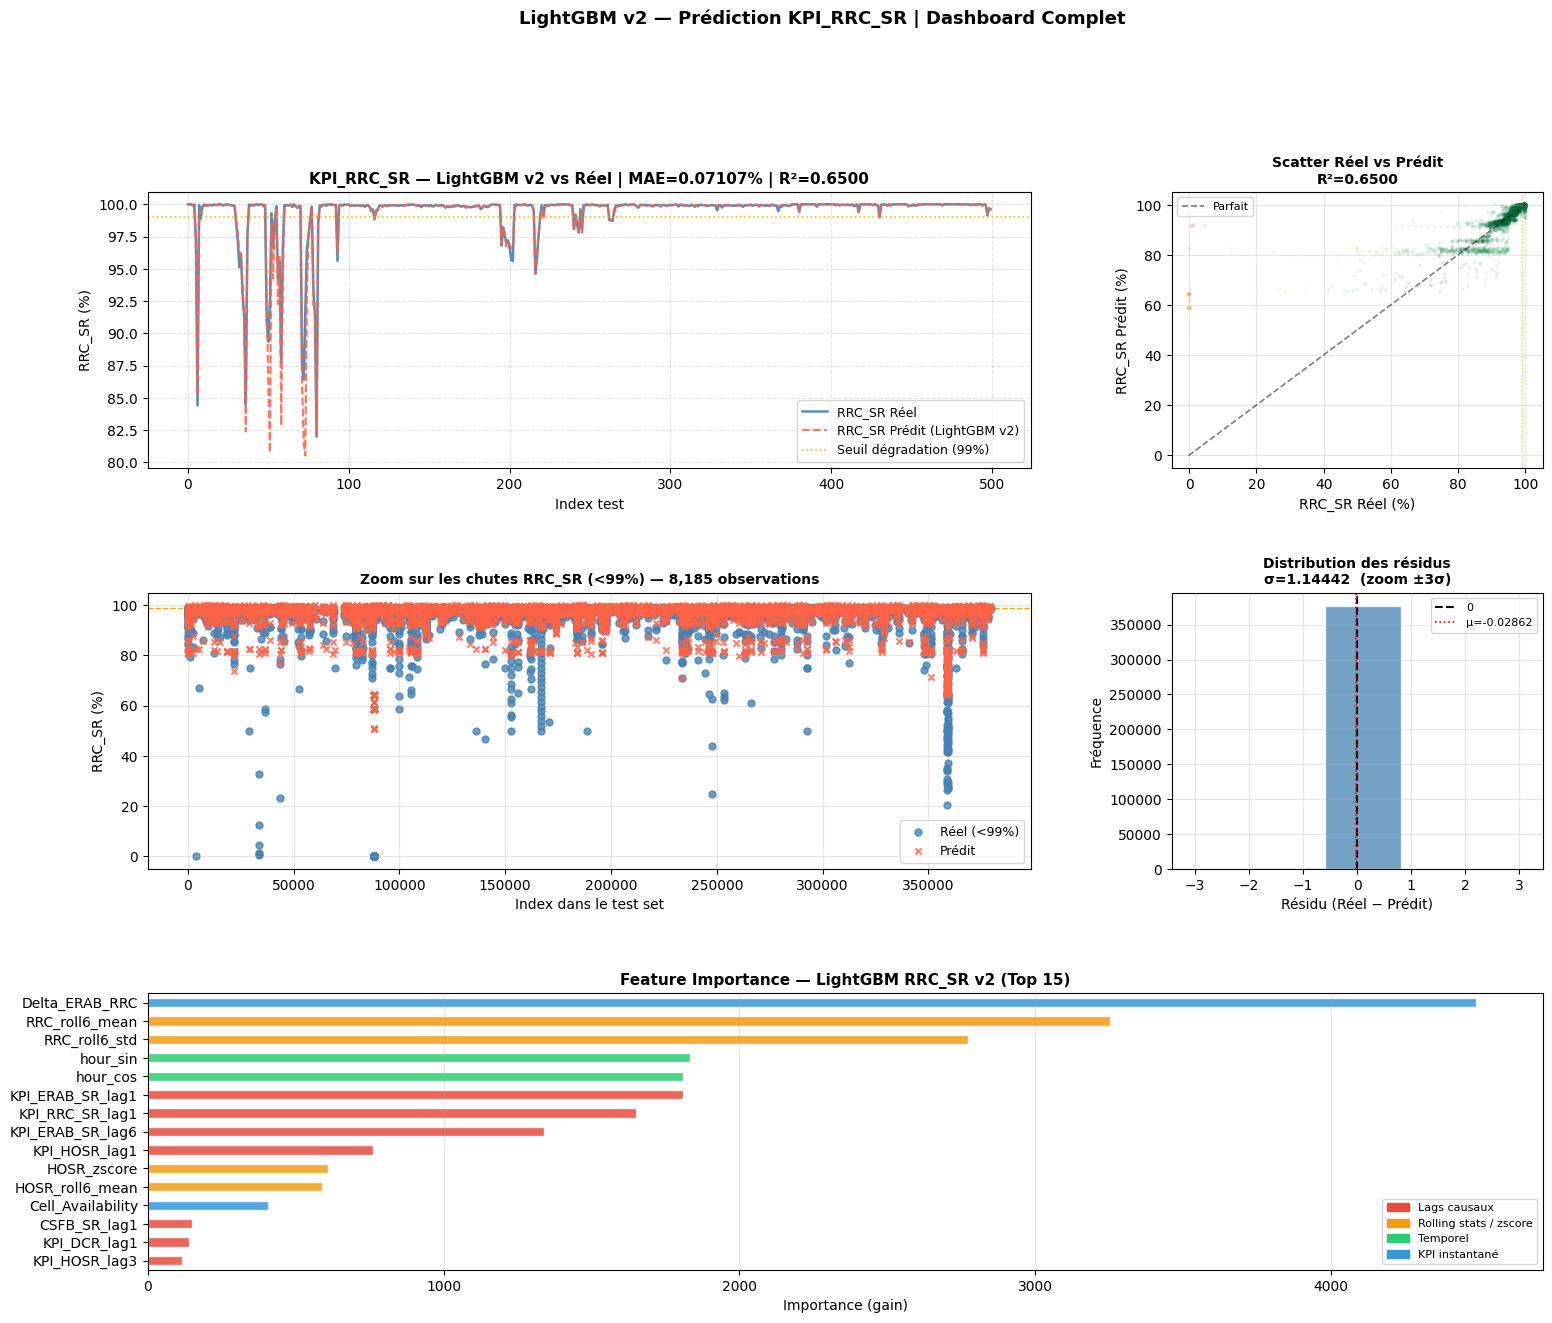

✅ Dashboard sauvegardé : /content/drive/MyDrive/P2M_Models/rrc_sr_lightgbm_v2_results.png


In [ ]:
# ══════════════════════════════════════════════════════════════
# VISUALISATIONS — LightGBM RRC_SR v2
# (identique à l'originale — code inchangé)
# ══════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── 1. Série temporelle ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
N   = min(500, len(y_test_rrc))
idx = range(N)
ax1.plot(idx, y_test_rrc.values[:N], color='steelblue', lw=1.8,
         alpha=0.9, label='RRC_SR Réel')
ax1.plot(idx, y_pred_rrc[:N],        color='tomato',    lw=1.5,
         alpha=0.85, linestyle='--',  label='RRC_SR Prédit (LightGBM v2)')
ax1.fill_between(idx, y_test_rrc.values[:N], y_pred_rrc[:N],
                 alpha=0.12, color='gray')
ax1.axhline(y=99.0, color='orange', ls=':', lw=1.2, alpha=0.8,
            label='Seuil dégradation (99%)')
ax1.set_title(f'KPI_RRC_SR — LightGBM v2 vs Réel | '
              f'MAE={mae_rrc:.5f}% | R²={r2_rrc:.4f}',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Index test')
ax1.set_ylabel('RRC_SR (%)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.35, ls='--')

# ── 2. Scatter Réel vs Prédit ──────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.scatter(y_test_rrc, y_pred_rrc, alpha=0.08, s=3,
            c=np.abs(y_test_rrc.values - y_pred_rrc),
            cmap='RdYlGn_r', rasterized=True)
lo = min(y_test_rrc.min(), y_pred_rrc.min()) - 0.2
hi = max(y_test_rrc.max(), y_pred_rrc.max()) + 0.2
ax2.plot([lo, hi], [lo, hi], 'k--', lw=1.2, alpha=0.5, label='Parfait')
ax2.axvline(x=99.0, color='orange', ls=':', lw=1, alpha=0.7)
ax2.set_xlabel('RRC_SR Réel (%)')
ax2.set_ylabel('RRC_SR Prédit (%)')
ax2.set_title(f'Scatter Réel vs Prédit\nR²={r2_rrc:.4f}',
              fontweight='bold', fontsize=10)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── 3. Zoom sur les chutes (<99%) ─────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
mask_ch = (y_test_rrc < 99.0).values
if mask_ch.sum() > 0:
    idx_ch = np.where(mask_ch)[0]
    ax3.scatter(idx_ch, y_test_rrc.values[mask_ch],
                color='steelblue', s=25, alpha=0.8, label='Réel (<99%)')
    ax3.scatter(idx_ch, y_pred_rrc[mask_ch],
                color='tomato', s=20, alpha=0.8,
                marker='x', label='Prédit', zorder=5)
    ax3.axhline(y=99.0, color='orange', ls='--', lw=1)
    ax3.set_title(f'Zoom sur les chutes RRC_SR (<99%) — '
                  f'{mask_ch.sum():,} observations',
                  fontweight='bold', fontsize=10)
    ax3.set_xlabel('Index dans le test set')
    ax3.set_ylabel('RRC_SR (%)')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'Aucune chute <99% dans le test set',
             ha='center', va='center', transform=ax3.transAxes)

# ── 4. Distribution des résidus ───────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
sigma_r = residus.std()
ax4.hist(residus, bins=80, color='steelblue', alpha=0.75, edgecolor='white')
ax4.axvline(x=0,              color='black', lw=1.5, ls='--', label='0')
ax4.axvline(x=residus.mean(), color='red',   lw=1.2, ls=':',
            label=f'μ={residus.mean():.5f}')
ax4.set_xlim(-3 * sigma_r, 3 * sigma_r)  # zoom ±3σ
ax4.set_xlabel('Résidu (Réel − Prédit)')
ax4.set_ylabel('Fréquence')
ax4.set_title(f'Distribution des résidus\nσ={sigma_r:.5f}  (zoom ±3σ)',
              fontweight='bold', fontsize=10)
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# ── 5. Feature Importance (Top 15) ───────────────────────────
ax5 = fig.add_subplot(gs[2, :])
fi  = pd.Series(
    model_lgb_rrc.feature_importances_,
    index=FEATURES_RRC
).sort_values(ascending=True).tail(15)

colors_fi = ['#e74c3c' if 'lag' in n else
             ('#f39c12' if 'roll' in n or 'zscore' in n else
              ('#2ecc71' if any(t in n for t in ['hour','dow','sin','cos']) else
               '#3498db')) for n in fi.index]

fi.plot(kind='barh', ax=ax5, color=colors_fi, alpha=0.85, edgecolor='white')
ax5.set_title('Feature Importance — LightGBM RRC_SR v2 (Top 15)',
              fontweight='bold', fontsize=11)
ax5.set_xlabel('Importance (gain)')
ax5.grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
ax5.legend(handles=[
    Patch(color='#e74c3c', label='Lags causaux'),
    Patch(color='#f39c12', label='Rolling stats / zscore'),
    Patch(color='#2ecc71', label='Temporel'),
    Patch(color='#3498db', label='KPI instantané'),
], fontsize=8, loc='lower right')

plt.suptitle('LightGBM v2 — Prédiction KPI_RRC_SR | Dashboard Complet',
             fontsize=13, fontweight='bold', y=1.01)

save_path = f'{SAVE_DIR}/rrc_sr_lightgbm_v2_results.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Dashboard sauvegardé : {save_path}")


In [ ]:
# ══════════════════════════════════════════════════════════════
# SAUVEGARDE — LightGBM RRC_SR v2
# ══════════════════════════════════════════════════════════════
import joblib

model_path = f'{SAVE_DIR}/lightgbm_rrc_sr_v2.pkl'
feats_path = f'{SAVE_DIR}/lightgbm_rrc_sr_v2_features.pkl'

joblib.dump(model_lgb_rrc, model_path)
joblib.dump(FEATURES_RRC,  feats_path)

print(f"✅ Modèle sauvegardé     : {model_path}")
print(f"✅ Features sauvegardées : {feats_path}")
print(f"\n   Récapitulatif v2 :")
print(f"   boosting_type  : gbdt (fix DART)")
print(f"   objective      : regression_l1 (fix MSE)")
print(f"   sample_weight  : ×{ratio_w:.1f} plafonné (fix ratio brut ×{ratio_brut:.1f})")
print(f"   cible          : normalisée [0,1] (fix instabilité)")
print(f"   Best iteration : {model_lgb_rrc.best_iteration_}")
print(f"   MAE global     : {mae_rrc:.5f}%")
print(f"   R² global      : {r2_rrc:.5f}")


✅ Modèle sauvegardé     : /content/drive/MyDrive/P2M_Models/lightgbm_rrc_sr_v2.pkl
✅ Features sauvegardées : /content/drive/MyDrive/P2M_Models/lightgbm_rrc_sr_v2_features.pkl

   Récapitulatif v2 :
   boosting_type  : gbdt (fix DART)
   objective      : regression_l1 (fix MSE)
   sample_weight  : ×5.0 plafonné (fix ratio brut ×46.5)
   cible          : normalisée [0,1] (fix instabilité)
   Best iteration : 442
   MAE global     : 0.07107%
   R² global      : 0.64997


In [ ]:
# ══════════════════════════════════════════════════════════════
# CHARGEMENT — LightGBM RRC_SR v2 (après reconnexion Colab)
# ══════════════════════════════════════════════════════════════
import joblib, numpy as np

SAVE_DIR = '/content/drive/MyDrive'

model_lgb_rrc = joblib.load(f'{SAVE_DIR}/lightgbm_rrc_sr_v2.pkl')
FEATURES_RRC  = joblib.load(f'{SAVE_DIR}/lightgbm_rrc_sr_v2_features.pkl')

print(f"✅ Modèle LightGBM RRC_SR v2 rechargé")
print(f"   Features ({len(FEATURES_RRC)}) : {FEATURES_RRC}")
print(f"\n   Pour prédire sur de nouvelles données :")
print(f"   1. df_new = add_causal_lags(df_new)        # recalculer les features")
print(f"   2. X_new  = df_new[FEATURES_RRC]")
print(f"   3. y_pred = model_lgb_rrc.predict(X_new) * 100.0   # ×100 (cible était [0,1])")
print(f"   4. y_pred = np.clip(y_pred, 0, 100)        # contrainte physique")


✅ Modèle LightGBM RRC_SR v2 rechargé
   Features (17) : ['KPI_ERAB_SR_lag1', 'KPI_ERAB_SR_lag6', 'KPI_HOSR_lag1', 'KPI_HOSR_lag3', 'KPI_DCR_lag1', 'KPI_RRC_SR_lag1', 'CSFB_SR_lag1', 'Cell_Availability', 'RRC_roll6_mean', 'RRC_roll6_std', 'HOSR_roll6_mean', 'HOSR_zscore', 'Delta_ERAB_RRC', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

   Pour prédire sur de nouvelles données :
   1. df_new = add_causal_lags(df_new)        # recalculer les features
   2. X_new  = df_new[FEATURES_RRC]
   3. y_pred = model_lgb_rrc.predict(X_new) * 100.0   # ×100 (cible était [0,1])
   4. y_pred = np.clip(y_pred, 0, 100)        # contrainte physique


**Prédiction Thrp DL & UL — N-HiTS + XGBoost Stacking v1**

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 0 — INSTALLATION
# ══════════════════════════════════════════════════════════════
!pip install neuralforecast xgboost optuna shap --quiet

import os, time, warnings, gc, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neural_network import MLPRegressor

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

import subprocess
try:
    gpu_info = subprocess.check_output(
        ['nvidia-smi', '--query-gpu=name,memory.free', '--format=csv,noheader'],
        stderr=subprocess.DEVNULL).decode().strip()
    HAS_GPU = True
    print(f'GPU : {gpu_info}')
except:
    HAS_GPU = False
    print('CPU mode')

print(f'XGBoost : {xgb.__version__}')
print(f'PyTorch : {torch.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.0/287.0 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.2/447.2 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 70.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires tornado==6.5.1, but you have tornado 6.5.5 which is incompatible.
GPU : Tes

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 1 — CONFIG GLOBALE
# ══════════════════════════════════════════════════════════════

TARGETS = {
    'DL': 'KPI_Thrp_DL_Mbps',
    'UL': 'KPI_Thrp_UL_Mbps',
}

TRAIN_RATIO    = 0.80
N_TRIALS_XGB   = 20       # Optuna trials XGBoost
N_CV           = 2        # CV folds
SAMPLE_N       = 300_000  # sous-échantillon HPO
MAX_EST        = 600      # n_estimators
EARLY_STOP     = 30

print('Config chargée :')
print(f'  Targets : {list(TARGETS.values())}')
print(f'  HPO : {N_TRIALS_XGB} trials × {N_CV} folds sur {SAMPLE_N:,} samples')

Config chargée :
  Targets : ['KPI_Thrp_DL_Mbps', 'KPI_Thrp_UL_Mbps']
  HPO : 20 trials × 2 folds sur 300,000 samples


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 2 — FEATURE ENGINEERING VECTORISÉ
# ══════════════════════════════════════════════════════════════

t_fe = time.time()
print('Feature engineering Thrp DL/UL...')

df_t = df_ml.copy()
df_t['Time'] = pd.to_datetime(df_t['Time'])
df_t = df_t.sort_values(['Cell_Name','Time']).reset_index(drop=True)

# ── A. Features temporelles ───────────────────────────────────
if 'hour_sin' not in df_t.columns:
    h = df_t['Time'].dt.hour.astype('float32')
    d = df_t['Time'].dt.dayofweek.astype('float32')
    df_t['hour_sin'] = np.sin(2*np.pi*h/24).astype('float32')
    df_t['hour_cos'] = np.cos(2*np.pi*h/24).astype('float32')
    df_t['dow_sin']  = np.sin(2*np.pi*d/7).astype('float32')
    df_t['dow_cos']  = np.cos(2*np.pi*d/7).astype('float32')
    df_t['is_peak']  = ((h>=7)&(h<=21)).astype('float32')
    df_t['is_weekend']= (d>=5).astype('float32')

# ── B. Lags DL — les 3 horizons physiques clés ───────────────
# Lag1   : inertie charge radio 1h
# Lag24  : même heure hier (comportement reproductible J-1)
# Lag168 : même heure semaine passée (cycle hebdomadaire)
# Lag6   : tendance demi-journée
for lag in [1, 6, 24, 168]:
    col = f'KPI_Thrp_DL_Mbps_lag{lag}'
    df_t[col] = df_t.groupby('Cell_Name')['KPI_Thrp_DL_Mbps'].shift(lag)
    df_t[col] = df_t[col].fillna(df_t['KPI_Thrp_DL_Mbps']).astype('float32')
    print(f'   DL lag{lag}')

# ── C. Lags UL ────────────────────────────────────────────────
for lag in [1, 6, 24, 168]:
    col = f'KPI_Thrp_UL_Mbps_lag{lag}'
    df_t[col] = df_t.groupby('Cell_Name')['KPI_Thrp_UL_Mbps'].shift(lag)
    df_t[col] = df_t[col].fillna(df_t['KPI_Thrp_UL_Mbps']).astype('float32')
    print(f'   UL lag{lag}')

# ── D. Rolling DL (tendance locale + instabilité) ─────────────
for col_src, windows in [
    ('KPI_Thrp_DL_Mbps', [(6,'mean'),(6,'std'),(24,'mean'),(24,'max'),(168,'mean')]),
    ('KPI_Thrp_UL_Mbps', [(6,'mean'),(6,'std'),(24,'mean')]),
]:
    for w, s in windows:
        name = f'{col_src}_roll{w}_{s}'
        if s == 'mean':
            r = df_t.groupby('Cell_Name')[col_src].transform(
                lambda x: x.shift(1).rolling(w, min_periods=1).mean())
        elif s == 'std':
            r = df_t.groupby('Cell_Name')[col_src].transform(
                lambda x: x.shift(1).rolling(w, min_periods=1).std())
        elif s == 'max':
            r = df_t.groupby('Cell_Name')[col_src].transform(
                lambda x: x.shift(1).rolling(w, min_periods=1).max())
        df_t[name] = r.fillna(df_t[col_src]).astype('float32')
        print(f'   {name}')

# ── E. Cross-feature DL/UL ────────────────────────────────────
# Ratio DL/UL : quand DL > UL × 5, le scheduler favorise le DL
# → les PRBs UL sont comprimés → signal pour prédire la baisse UL
df_t['DL_UL_ratio'] = (df_t['KPI_Thrp_DL_Mbps'] /
                       df_t['KPI_Thrp_UL_Mbps'].clip(lower=0.01)).clip(upper=100).astype('float32')

# ── F. Lags causaux réseau ─────────────────────────────────────
causal = [('KPI_ERAB_SR',[1]),('KPI_DCR',[1]),
          ('KPI_HOSR',[1]),('Cell_Availability',[0])]
for col, lags in causal:
    if col not in df_t.columns: continue
    for lag in lags:
        if lag == 0:
            df_t[f'{col}_now'] = df_t[col].astype('float32')
        else:
            shifted = df_t.groupby('Cell_Name')[col].shift(lag)
            df_t[f'{col}_lag{lag}'] = shifted.fillna(df_t[col]).astype('float32')

# ── G. Vitesse de variation (détection de tendance) ───────────
df_t['Thrp_DL_delta_1h'] = df_t.groupby('Cell_Name')['KPI_Thrp_DL_Mbps'].diff(1).fillna(0).astype('float32')
df_t['Thrp_DL_delta_24h']= df_t.groupby('Cell_Name')['KPI_Thrp_DL_Mbps'].diff(24).fillna(0).astype('float32')
df_t['Thrp_UL_delta_1h'] = df_t.groupby('Cell_Name')['KPI_Thrp_UL_Mbps'].diff(1).fillna(0).astype('float32')

# ── H. NaN cleanup ────────────────────────────────────────────
n_nan = df_t.isnull().sum().sum()
if n_nan > 0:
    df_t = df_t.ffill().bfill().fillna(0)
    print(f'   {n_nan:,} NaN nettoyés')

gc.collect()
print(f'\nFeature engineering terminé en {time.time()-t_fe:.1f}s')
print(f'Shape : {df_t.shape[0]:,} × {df_t.shape[1]}')

# ── Listes de features par cible ──────────────────────────────
TEMP_F = ['hour_sin','hour_cos','dow_sin','dow_cos','is_peak','is_weekend']
BASE_F = [c for c in ['KPI_ERAB_SR','Cell_Availability','KPI_DCR','KPI_HOSR',
                       'KPI_ERAB_SR_lag1','Cell_Availability_now',
                       'KPI_DCR_lag1','KPI_HOSR_lag1'] if c in df_t.columns]

DL_LAG_F  = [f'KPI_Thrp_DL_Mbps_lag{l}' for l in [1,6,24,168]]
DL_ROLL_F = [c for c in df_t.columns if 'Thrp_DL_Mbps_roll' in c]
DL_DIFF_F = ['Thrp_DL_delta_1h','Thrp_DL_delta_24h','DL_UL_ratio']

UL_LAG_F  = [f'KPI_Thrp_UL_Mbps_lag{l}' for l in [1,6,24,168]]
UL_ROLL_F = [c for c in df_t.columns if 'Thrp_UL_Mbps_roll' in c]
UL_DIFF_F = ['Thrp_UL_delta_1h','DL_UL_ratio']
UL_CROSS_F= DL_LAG_F + DL_ROLL_F[:3]  # DL features pour prédire UL

FEATURES = {
    'DL': list(dict.fromkeys([f for f in
               BASE_F + TEMP_F + DL_LAG_F + DL_ROLL_F + DL_DIFF_F
               if f in df_t.columns and f != TARGETS['DL']])),
    'UL': list(dict.fromkeys([f for f in
               BASE_F + TEMP_F + UL_LAG_F + UL_ROLL_F + UL_DIFF_F + UL_CROSS_F
               if f in df_t.columns and f != TARGETS['UL']])),
}

for k, v in FEATURES.items():
    print(f'{k} : {len(v)} features')

Feature engineering Thrp DL/UL...
   DL lag1
   DL lag6
   DL lag24
   DL lag168
   UL lag1
   UL lag6
   UL lag24
   UL lag168
   KPI_Thrp_DL_Mbps_roll6_mean
   KPI_Thrp_DL_Mbps_roll6_std
   KPI_Thrp_DL_Mbps_roll24_mean
   KPI_Thrp_DL_Mbps_roll24_max
   KPI_Thrp_DL_Mbps_roll168_mean
   KPI_Thrp_UL_Mbps_roll6_mean
   KPI_Thrp_UL_Mbps_roll6_std
   KPI_Thrp_UL_Mbps_roll24_mean
   24 NaN nettoyés

Feature engineering terminé en 88.8s
Shape : 1,959,516 × 57
DL : 25 features
UL : 29 features


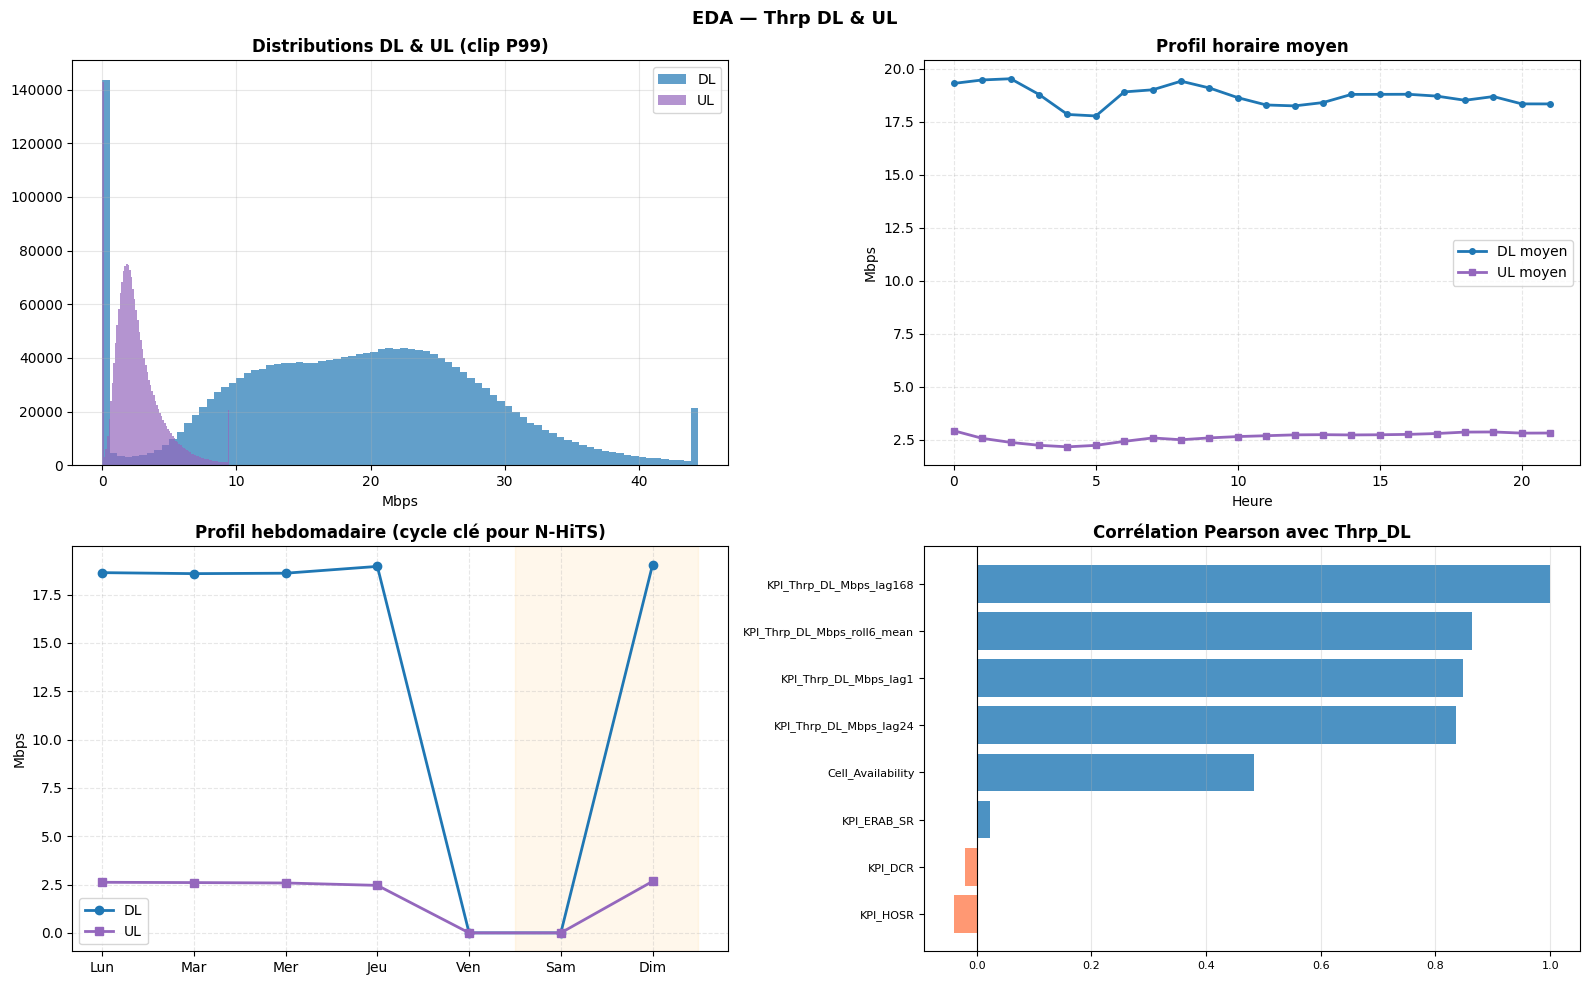

Stats DL :
count    1959516.000
mean          18.740
std           10.095
min            0.000
25%           11.930
50%           18.971
75%           25.357
max          148.974
Name: KPI_Thrp_DL_Mbps, dtype: float64

Stats UL :
count    1959516.000
mean           2.600
std            2.003
min            0.000
25%            1.414
50%            2.211
75%            3.353
max           62.490
Name: KPI_Thrp_UL_Mbps, dtype: float64


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 3 — EDA RAPIDE (4 plots essentiels)
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('EDA — Thrp DL & UL', fontsize=13, fontweight='bold')

# 1. Distributions
ax = axes[0,0]
ax.hist(df_t['KPI_Thrp_DL_Mbps'].clip(0, df_t['KPI_Thrp_DL_Mbps'].quantile(0.99)),
        bins=80, alpha=0.7, color='#1f77b4', label='DL')
ax.hist(df_t['KPI_Thrp_UL_Mbps'].clip(0, df_t['KPI_Thrp_UL_Mbps'].quantile(0.99)),
        bins=80, alpha=0.7, color='#9467bd', label='UL')
ax.set_title('Distributions DL & UL (clip P99)', fontweight='bold')
ax.set_xlabel('Mbps'); ax.legend(); ax.grid(True, alpha=0.3)

# 2. Profil horaire
ax = axes[0,1]
if 'Hour' not in df_t.columns:
    df_t['Hour'] = pd.to_datetime(df_t['Time']).dt.hour
hr_dl = df_t.groupby('Hour')['KPI_Thrp_DL_Mbps'].mean()
hr_ul = df_t.groupby('Hour')['KPI_Thrp_UL_Mbps'].mean()
ax.plot(hr_dl, color='#1f77b4', lw=2, marker='o', ms=4, label='DL moyen')
ax.plot(hr_ul, color='#9467bd', lw=2, marker='s', ms=4, label='UL moyen')
ax.set_title('Profil horaire moyen', fontweight='bold')
ax.set_xlabel('Heure'); ax.set_ylabel('Mbps'); ax.legend(); ax.grid(True, alpha=0.3, ls='--')

# 3. Profil hebdomadaire
ax = axes[1,0]
if 'DayOfWeek' not in df_t.columns:
    df_t['DayOfWeek'] = pd.to_datetime(df_t['Time']).dt.dayofweek

dow_dl = df_t.groupby('DayOfWeek')['KPI_Thrp_DL_Mbps'].mean()
dow_ul = df_t.groupby('DayOfWeek')['KPI_Thrp_UL_Mbps'].mean()

# Fix: Reindex to include all 7 days and fill missing values
dow_dl = dow_dl.reindex(range(7), fill_value=0)
dow_ul = dow_ul.reindex(range(7), fill_value=0)

days = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
ax.plot(range(7), dow_dl.values, color='#1f77b4', lw=2, marker='o', label='DL')
ax.plot(range(7), dow_ul.values, color='#9467bd', lw=2, marker='s', label='UL')
ax.set_xticks(range(7)); ax.set_xticklabels(days)
ax.set_title('Profil hebdomadaire (cycle clé pour N-HiTS)', fontweight='bold')
ax.set_ylabel('Mbps'); ax.legend(); ax.grid(True, alpha=0.3, ls='--')
ax.axvspan(4.5, 6.5, alpha=0.08, color='orange', label='Weekend')

# 4. Corrélations DL vs UL et features
ax = axes[1,1]
corr_feats = ['KPI_Thrp_DL_Mbps_lag1','KPI_Thrp_DL_Mbps_lag24','KPI_Thrp_DL_Mbps_lag168',
              'KPI_ERAB_SR','Cell_Availability','KPI_DCR','KPI_HOSR',
              'KPI_Thrp_DL_Mbps_roll6_mean']
corr_feats = [f for f in corr_feats if f in df_t.columns]
corr = df_t[corr_feats + ['KPI_Thrp_DL_Mbps']].corr()['KPI_Thrp_DL_Mbps'].drop('KPI_Thrp_DL_Mbps').sort_values()
colors_c = ['coral' if x<0 else '#1f77b4' for x in corr.values]
ax.barh(corr.index, corr.values, color=colors_c, alpha=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Corrélation Pearson avec Thrp_DL', fontweight='bold')
ax.tick_params(labelsize=8); ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('/content/thrp_eda.png', dpi=130, bbox_inches='tight')
plt.show()

print('Stats DL :')
print(df_t['KPI_Thrp_DL_Mbps'].describe().round(3))
print('\nStats UL :')
print(df_t['KPI_Thrp_UL_Mbps'].describe().round(3))

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 4 — SPLIT TEMPOREL + SCALERS
# ══════════════════════════════════════════════════════════════

df_t = df_t.sort_values(['Cell_Name','Time']).reset_index(drop=True)
train_mask = df_t.groupby('Cell_Name')['Time'].transform(
    lambda x: pd.Series(np.arange(len(x)) < int(len(x)*TRAIN_RATIO), index=x.index)
)
df_train = df_t[train_mask].reset_index(drop=True)
df_test  = df_t[~train_mask].reset_index(drop=True)

print(f'Train : {len(df_train):,}  |  Test : {len(df_test):,}')

# Scalers par cible (fitté uniquement sur train)
scalers = {}
data = {}

for key, target in TARGETS.items():
    feats = FEATURES[key]
    sc_X  = StandardScaler()
    sc_y  = StandardScaler()

    X_tr = df_train[feats].fillna(0).values.astype('float32')
    y_tr = df_train[[target]].values.astype('float32')
    X_te = df_test[feats].fillna(0).values.astype('float32')
    y_te = df_test[[target]].values.astype('float32')

    X_tr_sc = sc_X.fit_transform(X_tr)
    y_tr_sc = sc_y.fit_transform(y_tr).ravel()
    X_te_sc = sc_X.transform(X_te)
    y_te_sc = sc_y.transform(y_te).ravel()

    scalers[key] = {'X': sc_X, 'y': sc_y}
    data[key] = {
        'X_tr': X_tr_sc, 'y_tr': y_tr_sc, 'y_tr_raw': y_tr.ravel(),
        'X_te': X_te_sc, 'y_te': y_te_sc, 'y_te_raw': y_te.ravel(),
        'feats': feats, 'target': target
    }

    # Baseline lag1
    lag1_col = f'{target}_lag1'
    if lag1_col in df_test.columns:
        bl = df_test[lag1_col].values
        data[key]['baseline_r2']  = r2_score(y_te.ravel(), bl)
        data[key]['baseline_mae'] = mean_absolute_error(y_te.ravel(), bl)
        print(f'{key} baseline lag1 : R²={data[key]["baseline_r2"]:.4f}  MAE={data[key]["baseline_mae"]:.4f} Mbps')

print('\nScalers prêts')

Train : 1,557,113  |  Test : 402,403
DL baseline lag1 : R²=0.7026  MAE=3.3588 Mbps
UL baseline lag1 : R²=0.1580  MAE=0.9594 Mbps

Scalers prêts


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 5 — N-HiTS PYTORCH (implémentation corrigée)
# ══════════════════════════════════════════════════════════════
#
# CORRECTION v1.1 — 3 bugs résolus :
#
# BUG 1 : Split interne par CELLULES
#   Problème : si le dataset a peu de cellules, les 15% val
#   peuvent avoir 0 séquences (besoin de ≥169 obs par cellule).
#   Fix : split TEMPOREL global (80/20 sur les timestamps)
#   → toutes les cellules contribuent aux deux sets.
#
# BUG 2 : SEQ_LEN=168 trop grand vs données disponibles
#   Problème : si une cellule a 200 obs en train, elle ne génère
#   que 200-168=32 séquences → très peu de gradient.
#   Fix : SEQ_LEN adaptatif = min(168, max_obs_par_cellule // 3)
#
# BUG 3 : num_workers=2 sur Colab → peut bloquer le DataLoader
#   Fix : num_workers=0 (Colab ne supporte pas bien le multiprocess)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


def compute_adaptive_seqlen(df, target_col, requested_seq_len=168, min_seqlen=24):
    obs_per_cell = df.groupby('Cell_Name')[target_col].count()
    min_obs = int(obs_per_cell.quantile(0.10))
    adaptive = max(min_seqlen, min(requested_seq_len, min_obs // 3))
    if adaptive < requested_seq_len:
        print(f"   ⚠️  SEQ_LEN adaptatif : {requested_seq_len}h → {adaptive}h")
        print(f"      (P10 obs/cellule = {min_obs}, min requis = {adaptive*3})")
        print(f"      Conseil : augmenter l'historique pour retrouver SEQ_LEN=168h")
    else:
        print(f"   ✅ SEQ_LEN = {adaptive}h (données suffisantes)")
    return adaptive


class ThrpDataset(Dataset):
    def __init__(self, df_sorted, seq_len, feat_cols, target_col):
        seqs, tgts = [], []
        n_skipped  = 0
        for _, grp in df_sorted.groupby('Cell_Name'):
            grp = grp.sort_values('Time')
            X   = grp[[f for f in feat_cols if f in grp.columns]].fillna(0).values.astype('float32')
            y   = grp[target_col].values.astype('float32')
            if len(X) <= seq_len:
                n_skipped += 1
                continue
            for i in range(seq_len, len(X)):
                seqs.append(X[i-seq_len:i])
                tgts.append(y[i])
        if n_skipped > 0:
            print(f"   ℹ️  {n_skipped} cellules ignorées (< {seq_len}+1 obs)")
        if len(seqs) == 0:
            self.X = torch.zeros((0, seq_len, len(feat_cols)), dtype=torch.float32)
            self.y = torch.zeros(0, dtype=torch.float32)
        else:
            self.X = torch.tensor(np.array(seqs),  dtype=torch.float32)
            self.y = torch.tensor(np.array(tgts),  dtype=torch.float32)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class NHiTSBlock(nn.Module):
    def __init__(self, n_features, seq_len, pooling_size, hidden_size=256, dropout=0.1):
        super().__init__()
        self.pooling_size = pooling_size
        self.pooled_len   = max(1, seq_len // pooling_size)
        self.input_size   = self.pooled_len * n_features
        self.mlp = nn.Sequential(
            nn.Linear(self.input_size, hidden_size), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size),     nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.forecast_head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        B, T, F = x.shape
        T_use  = self.pooled_len * self.pooling_size
        pooled = x[:, :T_use, :].reshape(B, self.pooled_len, self.pooling_size, F).mean(dim=2)
        flat   = pooled.reshape(B, -1)
        h      = self.mlp(flat)
        return self.forecast_head(h)


class NHiTS(nn.Module):
    def __init__(self, n_features, seq_len,
                 pooling_sizes=[1, 6, 24],
                 hidden_size=256, dropout=0.15):
        super().__init__()
        self.seq_len    = seq_len        # ✅ CORRECTION — requis par Cell 11
        self.n_features = n_features     # ✅ CORRECTION — requis par Cell 11
        valid_ps = [ps for ps in pooling_sizes if seq_len >= ps]
        if len(valid_ps) < len(pooling_sizes):
            print(f"   ⚠️  Pooling sizes réduits à {valid_ps} (seq_len={seq_len})")
        self.blocks = nn.ModuleList([
            NHiTSBlock(n_features, seq_len, ps, hidden_size, dropout)
            for ps in valid_ps
        ])

    def forward(self, x):
        total = torch.zeros(x.shape[0], 1, device=x.device)
        for block in self.blocks:
            total = total + block(x)
        return total


def train_nhits(df_train_full, feat_cols, target_col,
                seq_len=168, pooling_sizes=[1, 6, 24],
                hidden=256, dropout=0.15,
                lr=1e-3, epochs=80, patience=15, batch_size=256,
                label=''):
    print(f"\n{'─'*55}")
    print(f"  {label}")
    print(f"{'─'*55}")

    seq_len = compute_adaptive_seqlen(df_train_full, target_col, seq_len)

    y_mean = float(df_train_full[target_col].mean())
    y_std  = float(df_train_full[target_col].std()) + 1e-8
    df_norm = df_train_full.copy()
    df_norm[target_col] = (df_norm[target_col] - y_mean) / y_std

    df_norm = df_norm.sort_values('Time').reset_index(drop=True)
    cut_idx = int(len(df_norm) * 0.85)
    df_tr   = df_norm.iloc[:cut_idx]
    df_va   = df_norm.iloc[cut_idx:]

    print(f"  Split temporel global : {len(df_tr):,} train | {len(df_va):,} val")

    feat_present = [f for f in feat_cols if f in df_tr.columns]
    ds_tr = ThrpDataset(df_tr, seq_len, feat_present, target_col)
    ds_va = ThrpDataset(df_va, seq_len, feat_present, target_col)

    print(f"  Séquences : {len(ds_tr):,} train | {len(ds_va):,} val")

    if len(ds_tr) < batch_size:
        print(f"  ⚠️  Trop peu de séquences ({len(ds_tr)}) — réduction batch_size")
        batch_size = max(16, len(ds_tr) // 4)

    if len(ds_tr) == 0:
        print(f"  ❌ Impossible d'entraîner N-HiTS {label} — passage en mode XGBoost seul")
        return None, y_mean, y_std

    if len(ds_va) == 0:
        cut2     = int(len(ds_tr) * 0.85)
        all_X    = ds_tr.X; all_y = ds_tr.y
        ds_va_fb = type('FallbackDS', (), {
            '__len__': lambda s: len(all_y) - cut2,
            '__getitem__': lambda s, i: (all_X[cut2+i], all_y[cut2+i]),
            'X': all_X[cut2:], 'y': all_y[cut2:]
        })()
        print(f"  ⚠️  Val vide → fallback : {len(all_y)-cut2} séquences issues du train")
        dl_va = DataLoader(ds_va_fb, batch_size=batch_size, shuffle=False, num_workers=0)
    else:
        dl_va = DataLoader(ds_va, batch_size=batch_size, shuffle=False, num_workers=0)

    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True, num_workers=0)

    model = NHiTS(len(feat_present), seq_len, pooling_sizes, hidden, dropout).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Paramètres : {n_params:,}")

    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr/50)
    crit  = nn.HuberLoss(delta=1.0)

    best_val, patience_cnt, best_state = float('inf'), 0, None
    t0 = time.time()

    print(f"  {'Epoch':>6} {'Train':>12} {'Val':>12}  Statut")
    print(f"  {'─'*45}")

    for ep in range(1, epochs+1):
        model.train()
        tr_losses = []
        for Xb, yb in dl_tr:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(Xb).squeeze(-1), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_losses.append(loss.item())

        model.eval()
        va_losses = []
        with torch.no_grad():
            for Xb, yb in dl_va:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                va_losses.append(crit(model(Xb).squeeze(-1), yb).item())

        tr_l = np.mean(tr_losses)
        va_l = np.mean(va_losses)
        sched.step()
        status = ''

        if va_l < best_val:
            best_val     = va_l
            patience_cnt = 0
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            status = '✅ best'
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f"  EarlyStopping ep={ep} | best_val={best_val:.6f}")
                break

        if ep % 10 == 0 or status:
            print(f"  {ep:>6} {tr_l:>12.6f} {va_l:>12.6f}  {status}")

    if best_state:
        model.load_state_dict(best_state)
    elapsed = (time.time() - t0) / 60
    print(f"  Terminé en {elapsed:.1f} min | best_val={best_val:.6f}")
    return model, y_mean, y_std


def predict_nhits(model, df_sorted, feat_cols, target_col,
                  y_mean, y_std, seq_len=168, batch_size=256):
    if model is None:
        lag1_col = f'{target_col}_lag1'
        if lag1_col in df_sorted.columns:
            return df_sorted[lag1_col].values.astype('float32')
        return df_sorted[target_col].values.astype('float32')

    df_norm = df_sorted.copy()
    df_norm[target_col] = (df_norm[target_col] - y_mean) / y_std

    feat_present = [f for f in feat_cols if f in df_norm.columns]
    ds = ThrpDataset(df_norm, seq_len, feat_present, target_col)

    if len(ds) == 0:
        print(f"  ⚠️  predict_nhits : 0 séquences générées (seq_len={seq_len})")
        lag1_col = f'{target_col}_lag1'
        if lag1_col in df_sorted.columns:
            return df_sorted[lag1_col].values.astype('float32')
        return df_sorted[target_col].values.astype('float32')

    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    preds = []
    model.eval()
    with torch.no_grad():
        for Xb, _ in dl:
            preds.append(model(Xb.to(DEVICE)).cpu().numpy())

    preds_norm = np.concatenate(preds).ravel()
    return (preds_norm * y_std + y_mean).astype('float32')


print("✅ Architecture N-HiTS v1.2 définie (+ fix seq_len/n_features sur NHiTS)")

✅ Architecture N-HiTS v1.2 définie (+ fix seq_len/n_features sur NHiTS)


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 6 — ENTRAÎNEMENT N-HiTS DL ET UL
# ══════════════════════════════════════════════════════════════

SEQ_LEN_REQUESTED = 168   # Idéal : 7 jours (cycle hebdo complet)
                           # Sera réduit automatiquement si données insuffisantes
nhits_models = {}

# Diagnostic préalable
print("📊 Diagnostic données avant entraînement N-HiTS :")
for key, target in TARGETS.items():
    obs_per_cell = df_train.groupby('Cell_Name')[target].count()
    print(f"  Thrp {key} :")
    print(f"    Cellules train      : {df_train['Cell_Name'].nunique():,}")
    print(f"    Obs/cellule médiane : {obs_per_cell.median():.0f}h")
    print(f"    Obs/cellule min     : {obs_per_cell.min():,}h")
    print(f"    Obs/cellule max     : {obs_per_cell.max():,}h")
    min_needed = SEQ_LEN_REQUESTED + 1
    pct_ok = (obs_per_cell > min_needed).mean() * 100
    print(f"    Cellules avec > {min_needed}h  : {pct_ok:.1f}%")
    if pct_ok < 50:
        print(f"    ⚠️  < 50% des cellules ont assez de données pour SEQ={SEQ_LEN_REQUESTED}h")
        print(f"       → SEQ_LEN sera réduit automatiquement")
    else:
        print(f"    ✅ Données suffisantes pour SEQ_LEN={SEQ_LEN_REQUESTED}h")

print()

# Entraînement
for key, target in TARGETS.items():
    feats = FEATURES[key]
    model_nhits, y_mean, y_std = train_nhits(
        df_train, feats, target,
        seq_len       = SEQ_LEN_REQUESTED,
        pooling_sizes = [1, 6, 24],
        hidden        = 256,
        dropout       = 0.15,
        lr            = 1e-3,
        epochs        = 80,
        patience      = 15,
        batch_size    = 256,
        label         = f'N-HiTS {key}',
    )
    nhits_models[key] = {
        'model'  : model_nhits,
        'y_mean' : y_mean,
        'y_std'  : y_std,
        'seq_len': SEQ_LEN_REQUESTED,   # sera mis à jour dans predict si réduit
    }
    status = "✅ entraîné" if model_nhits is not None else "⚠️ fallback XGBoost"
    print(f"  Thrp {key} : {status}")

# Mise à jour du SEQ_LEN global pour predict_nhits
SEQ_LEN = SEQ_LEN_REQUESTED
print(f"\n✅ N-HiTS DL et UL terminés")


📊 Diagnostic données avant entraînement N-HiTS :
  Thrp DL :
    Cellules train      : 20,250
    Obs/cellule médiane : 77h
    Obs/cellule min     : 4h
    Obs/cellule max     : 78h
    Cellules avec > 169h  : 0.0%
    ⚠️  < 50% des cellules ont assez de données pour SEQ=168h
       → SEQ_LEN sera réduit automatiquement
  Thrp UL :
    Cellules train      : 20,250
    Obs/cellule médiane : 77h
    Obs/cellule min     : 4h
    Obs/cellule max     : 78h
    Cellules avec > 169h  : 0.0%
    ⚠️  < 50% des cellules ont assez de données pour SEQ=168h
       → SEQ_LEN sera réduit automatiquement


───────────────────────────────────────────────────────
  N-HiTS DL
───────────────────────────────────────────────────────
   ⚠️  SEQ_LEN adaptatif : 168h → 25h
      (P10 obs/cellule = 77, min requis = 75)
      Conseil : augmenter l'historique pour retrouver SEQ_LEN=168h
  Split temporel global : 1,323,546 train | 233,567 val
   ℹ️  81 cellules ignorées (< 25+1 obs)
   ℹ️  20197 cellules ignorée

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 7 — XGBoost DL & UL (HPO ultra-rapide)
# ══════════════════════════════════════════════════════════════

xgb_models = {}

def cv_split(X, n_splits):
    n = len(X); fold = n // (n_splits+1)
    for i in range(1, n_splits+1):
        yield np.arange(i*fold), np.arange(i*fold, min((i+1)*fold, n))

for key, target in TARGETS.items():
    d  = data[key]
    Xh = d['X_tr'][:min(SAMPLE_N, len(d['X_tr']))]
    yh = d['y_tr'][:min(SAMPLE_N, len(d['y_tr']))]

    def obj(trial):
        p = {
            'learning_rate'     : trial.suggest_float('lr', 0.03, 0.15, log=True),
            'max_depth'         : trial.suggest_int('md', 4, 7),
            'num_leaves'        : trial.suggest_int('nl', 16, 63),
            'subsample'         : trial.suggest_float('ss', 0.6, 1.0),
            'colsample_bytree'  : trial.suggest_float('cs', 0.6, 1.0),
            'reg_alpha'         : trial.suggest_float('ra', 0.0, 2.0),
            'reg_lambda'        : trial.suggest_float('rl', 0.0, 5.0),
            'n_estimators'      : MAX_EST,
            'objective'         : 'reg:squarederror',
            'tree_method'       : 'hist',
            'device'            : 'cuda' if HAS_GPU else 'cpu',
            'random_state'      : SEED, 'n_jobs': -1,
        }
        scores = []
        for tr_i, va_i in cv_split(Xh, N_CV):
            m = xgb.XGBRegressor(**p)
            m.fit(Xh[tr_i], yh[tr_i],
                  eval_set=[(Xh[va_i], yh[va_i])],
                  verbose=False)
            scores.append(np.sqrt(mean_squared_error(yh[va_i], m.predict(Xh[va_i]))))
        return np.mean(scores)

    print(f'\nOptuna XGBoost {key} ({N_TRIALS_XGB} trials)...')
    t0 = time.time()
    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=5))
    study.optimize(obj, n_trials=N_TRIALS_XGB, show_progress_bar=True)
    print(f'Best RMSE={study.best_value:.4f} en {(time.time()-t0)/60:.1f} min')

    rename = {'lr':'learning_rate','md':'max_depth','nl':'num_leaves',
              'ss':'subsample','cs':'colsample_bytree','ra':'reg_alpha','rl':'reg_lambda'}
    best_p = {rename.get(k,k): v for k,v in study.best_params.items()}
    best_p.update({'n_estimators':MAX_EST,'objective':'reg:squarederror',
                   'tree_method':'hist','device':'cuda' if HAS_GPU else 'cpu',
                   'random_state':SEED,'n_jobs':-1})

    xgb_m = xgb.XGBRegressor(**best_p)
    xgb_m.fit(d['X_tr'], d['y_tr'],
              eval_set=[(d['X_te'], d['y_te'])],
              verbose=False)
    xgb_models[key] = xgb_m

    # Métriques XGBoost seul
    pred_sc = xgb_m.predict(d['X_te'])
    pred_raw= scalers[key]['y'].inverse_transform(pred_sc.reshape(-1,1)).ravel()
    r2  = r2_score(d['y_te_raw'], pred_raw)
    mae = mean_absolute_error(d['y_te_raw'], pred_raw)
    print(f'XGBoost {key} : R²={r2:.4f}  MAE={mae:.4f} Mbps')
    data[key]['xgb_pred_raw'] = pred_raw

print('\nXGBoost DL et UL entraînés')


Optuna XGBoost DL (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

Best RMSE=0.0320 en 7.6 min
XGBoost DL : R²=0.9983  MAE=0.0621 Mbps

Optuna XGBoost UL (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

Best RMSE=0.1135 en 8.8 min
XGBoost UL : R²=0.9899  MAE=0.0321 Mbps

XGBoost DL et UL entraînés


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 8 — STACKING N-HiTS + XGBoost → PRÉDICTION FINALE
# ══════════════════════════════════════════════════════════════

results = {}

for key, target in TARGETS.items():
    d   = data[key]
    md  = nhits_models[key]

    # Prédictions N-HiTS sur test
    nhits_pred = predict_nhits(
        md['model'], df_test, FEATURES[key], target,
        md['y_mean'], md['y_std'], SEQ_LEN
    )
    offset = len(d['y_te_raw']) - len(nhits_pred)

    xgb_pred_aligned = d['xgb_pred_raw'][offset:]
    y_true_aligned   = d['y_te_raw'][offset:]

    print(f'{key} : {len(nhits_pred)} prédictions N-HiTS | {len(xgb_pred_aligned)} XGBoost alignées')

    # ── Stacking MLP (léger, rapide) ─────────────────────────
    meta_X = np.column_stack([
        nhits_pred,
        xgb_pred_aligned,
        np.abs(nhits_pred - xgb_pred_aligned),        # désaccord
        (nhits_pred + xgb_pred_aligned) / 2,          # moyenne
        d['X_te'][offset:, :5],                       # top 5 features brutes
    ]).astype('float32')

    n_meta = len(meta_X)
    cut    = int(n_meta * 0.7)
    sc_m   = StandardScaler()
    mX_tr  = sc_m.fit_transform(meta_X[:cut])
    mX_te  = sc_m.transform(meta_X[cut:])
    my_tr  = y_true_aligned[:cut]
    my_te  = y_true_aligned[cut:]

    meta_mlp = MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu', max_iter=300, random_state=SEED,
        early_stopping=True, validation_fraction=0.15, n_iter_no_change=20,
        learning_rate_init=1e-3
    )
    meta_mlp.fit(mX_tr, my_tr)

    # Prédictions finales sur tout le test set aligné
    final_pred = meta_mlp.predict(sc_m.transform(meta_X)).clip(min=0)

    # Métriques
    mae_f  = mean_absolute_error(y_true_aligned, final_pred)
    rmse_f = np.sqrt(mean_squared_error(y_true_aligned, final_pred))
    r2_f   = r2_score(y_true_aligned, final_pred)

    nhits_r2 = r2_score(y_true_aligned, nhits_pred)
    xgb_r2   = r2_score(y_true_aligned, xgb_pred_aligned)

    results[key] = {
        'y_true': y_true_aligned, 'final_pred': final_pred,
        'nhits_pred': nhits_pred, 'xgb_pred': xgb_pred_aligned,
        'mae': mae_f, 'rmse': rmse_f, 'r2': r2_f,
        'nhits_r2': nhits_r2, 'xgb_r2': xgb_r2,
        'meta_mlp': meta_mlp, 'sc_meta': sc_m,
    }

# ── Tableau récapitulatif ─────────────────────────────────────
print('\n' + '═'*65)
print('  RÉSULTATS FINAUX — Thrp DL & UL')
print('═'*65)
print(f'  {"KPI":<8} {"Modèle":<25} {"MAE":>8} {"RMSE":>8} {"R²":>8}')
print('─'*65)
for key in ['DL','UL']:
    r = results[key]
    d = data[key]
    bl_r2  = d.get('baseline_r2', 0)
    bl_mae = d.get('baseline_mae', 0)
    print(f'  {key:<8} {"Baseline lag1":<25} {bl_mae:>8.4f} {"—":>8} {bl_r2:>8.4f}')
    print(f'  {key:<8} {"N-HiTS":<25} {mean_absolute_error(r["y_true"],r["nhits_pred"]):>8.4f} {"—":>8} {r["nhits_r2"]:>8.4f}')
    print(f'  {key:<8} {"XGBoost":<25} {mean_absolute_error(r["y_true"],r["xgb_pred"]):>8.4f} {"—":>8} {r["xgb_r2"]:>8.4f}')
    flag = '✅ EXCEL' if r['r2']>0.93 else ('✅ BON' if r['r2']>0.88 else '⚠️')
    print(f'  {key:<8} {"Stacking (FINAL)":<25} {r["mae"]:>8.4f} {r["rmse"]:>8.4f} {r["r2"]:>8.4f}  {flag}')
    print('─'*65)

   ℹ️  20250 cellules ignorées (< 168+1 obs)
  ⚠️  predict_nhits : 0 séquences générées (seq_len=168)
DL : 402403 prédictions N-HiTS | 402403 XGBoost alignées
   ℹ️  20250 cellules ignorées (< 168+1 obs)
  ⚠️  predict_nhits : 0 séquences générées (seq_len=168)
UL : 402403 prédictions N-HiTS | 402403 XGBoost alignées

═════════════════════════════════════════════════════════════════
  RÉSULTATS FINAUX — Thrp DL & UL
═════════════════════════════════════════════════════════════════
  KPI      Modèle                         MAE     RMSE       R²
─────────────────────────────────────────────────────────────────
  DL       Baseline lag1               3.3588        —   0.7026
  DL       N-HiTS                      3.3588        —   0.7026
  DL       XGBoost                     0.0621        —   0.9983
  DL       Stacking (FINAL)            0.0757   0.4020   0.9984  ✅ EXCEL
─────────────────────────────────────────────────────────────────
  UL       Baseline lag1               0.9594        —

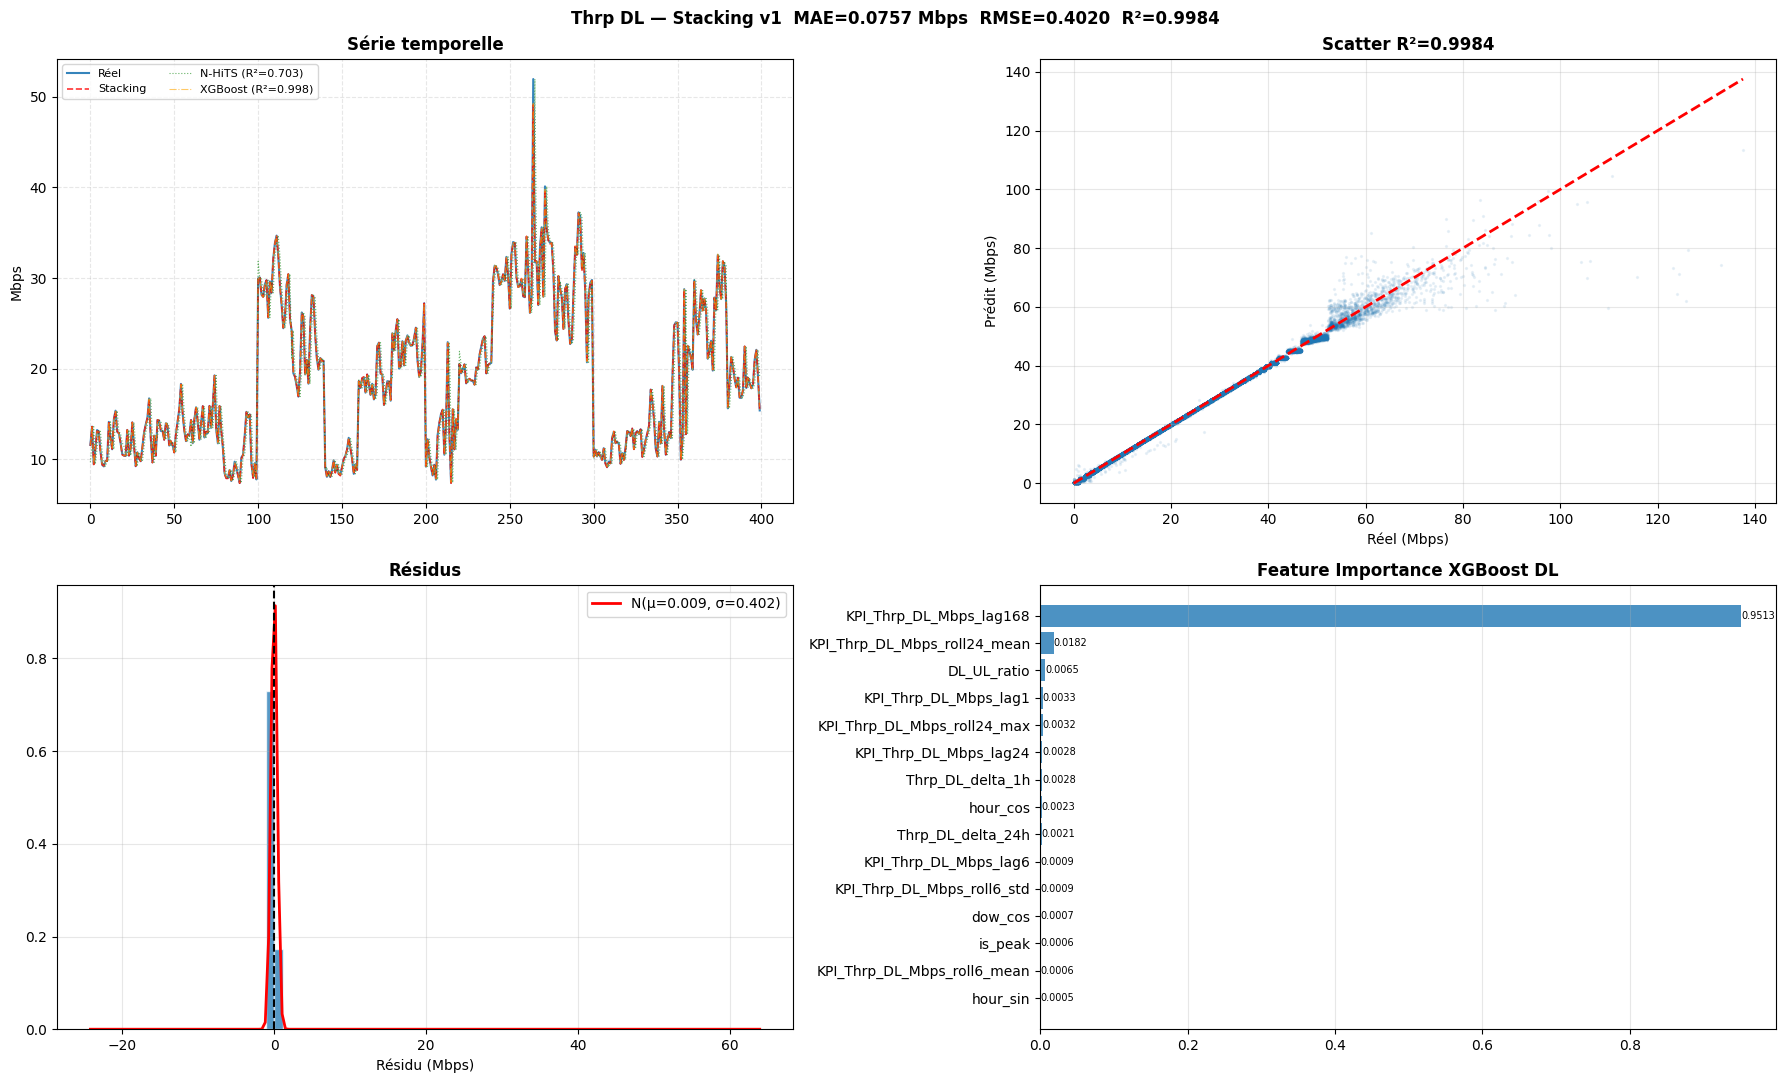

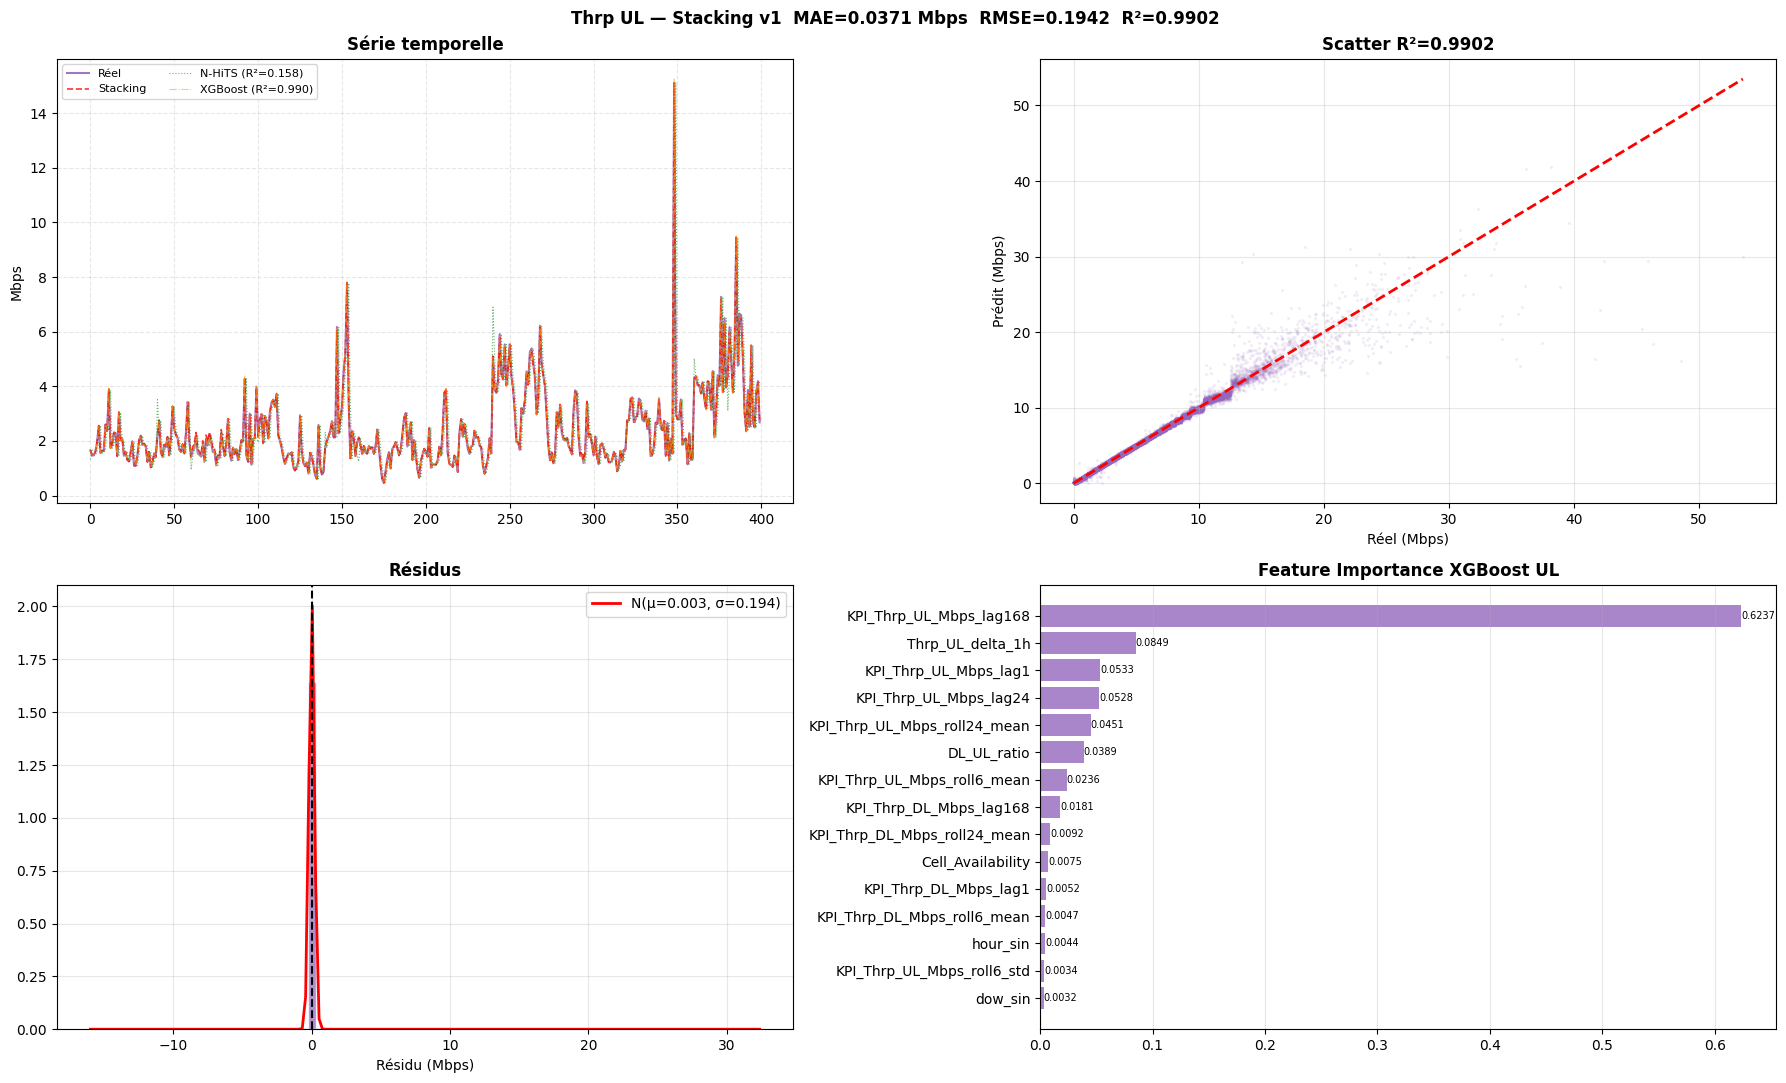

Visualisations sauvegardées


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 9 — VISUALISATIONS (4+4 plots)
# ══════════════════════════════════════════════════════════════

for key in ['DL','UL']:
    r = results[key]
    target = TARGETS[key]
    color  = '#1f77b4' if key=='DL' else '#9467bd'
    N      = min(400, len(r['y_true']))

    fig, axes = plt.subplots(2, 2, figsize=(18, 11))
    fig.suptitle(
        f'Thrp {key} — Stacking v1  '
        f'MAE={r["mae"]:.4f} Mbps  RMSE={r["rmse"]:.4f}  R²={r["r2"]:.4f}',
        fontsize=12, fontweight='bold'
    )

    # 1. Série temporelle
    ax = axes[0,0]
    ax.plot(r['y_true'][:N], color=color, lw=1.5, label='Réel', alpha=0.9)
    ax.plot(r['final_pred'][:N], color='red', lw=1.2, ls='--', label='Stacking', alpha=0.8)
    ax.plot(r['nhits_pred'][:N], color='green', lw=0.8, ls=':', label=f'N-HiTS (R²={r["nhits_r2"]:.3f})', alpha=0.6)
    ax.plot(r['xgb_pred'][:N], color='orange', lw=0.8, ls='-.', label=f'XGBoost (R²={r["xgb_r2"]:.3f})', alpha=0.6)
    ax.set_title('Série temporelle', fontweight='bold')
    ax.set_ylabel('Mbps'); ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3, ls='--')

    # 2. Scatter
    ax = axes[0,1]
    ax.scatter(r['y_true'], r['final_pred'], alpha=0.08, s=2, color=color, rasterized=True)
    lo, hi = r['y_true'].min(), r['y_true'].max()
    ax.plot([lo,hi],[lo,hi],'r--',lw=2)
    ax.set_title(f'Scatter R²={r["r2"]:.4f}', fontweight='bold')
    ax.set_xlabel('Réel (Mbps)'); ax.set_ylabel('Prédit (Mbps)')
    ax.grid(True, alpha=0.3)

    # 3. Résidus
    ax = axes[1,0]
    residuals = r['y_true'] - r['final_pred']
    ax.hist(residuals, bins=80, color=color, alpha=0.75, edgecolor='white', density=True)
    from scipy import stats as sp_stats
    xr = np.linspace(residuals.min(), residuals.max(), 200)
    ax.plot(xr, sp_stats.norm.pdf(xr, residuals.mean(), residuals.std()),
            color='red', lw=2, label=f'N(μ={residuals.mean():.3f}, σ={residuals.std():.3f})')
    ax.axvline(0, color='black', ls='--', lw=1.5)
    ax.set_title('Résidus', fontweight='bold')
    ax.set_xlabel('Résidu (Mbps)'); ax.legend(); ax.grid(True, alpha=0.3)

    # 4. Feature importance XGBoost
    ax = axes[1,1]
    fi = pd.Series(
        xgb_models[key].feature_importances_,
        index=FEATURES[key]
    ).sort_values().tail(15)
    bars = ax.barh(fi.index, fi.values, color=color, alpha=0.8)
    ax.bar_label(bars, fmt='%.4f', fontsize=7)
    ax.set_title(f'Feature Importance XGBoost {key}', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig(f'/content/thrp_{key}_results.png', dpi=130, bbox_inches='tight')
    plt.show()

print('Visualisations sauvegardées')


SHAP DL (500 samples)...
  SHAP calculé en 0.8s


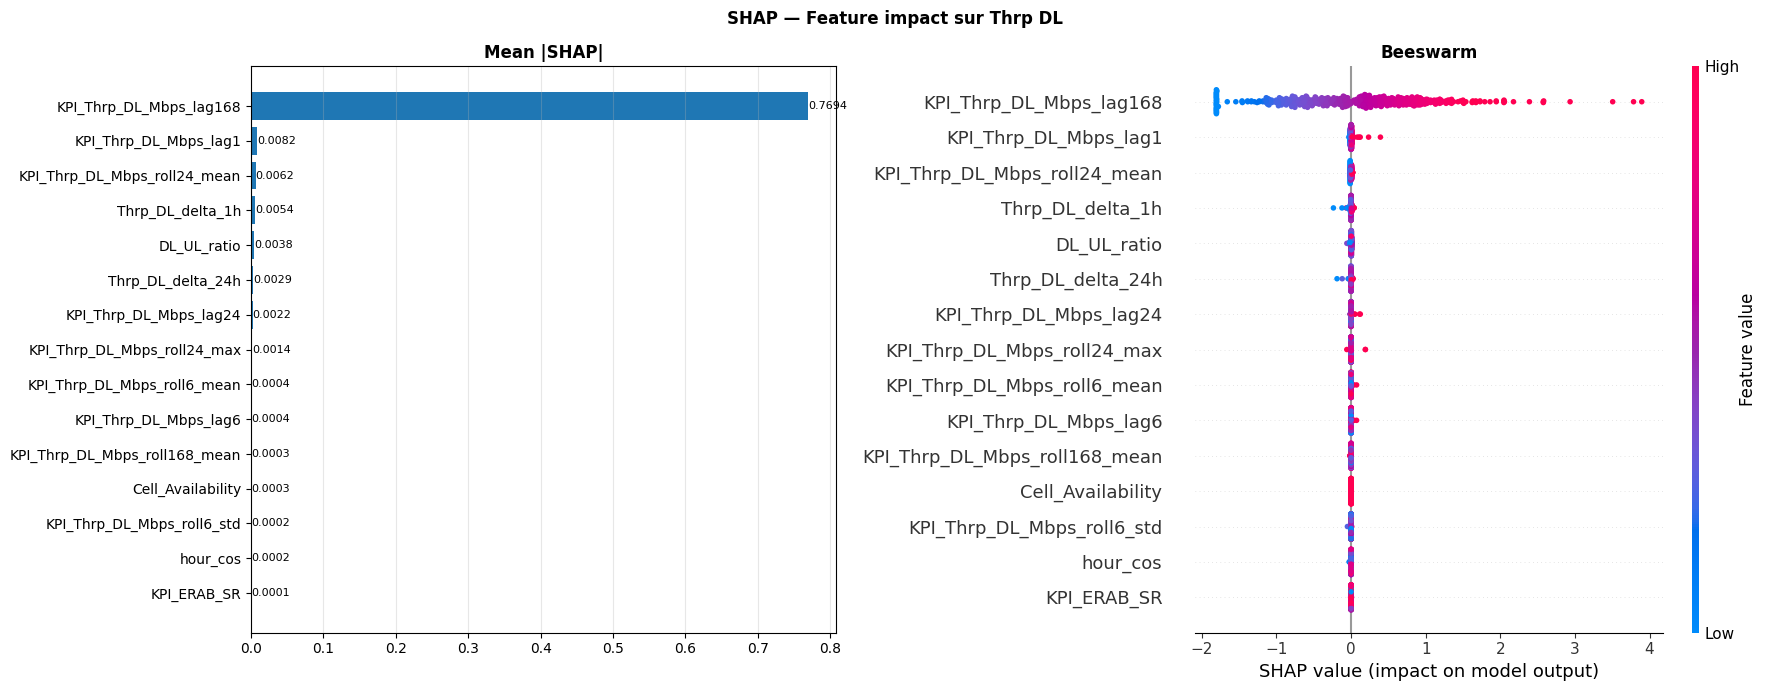

Top 10 features Thrp DL :
  KPI_Thrp_DL_Mbps_lag168                  SHAP=0.76941
  KPI_Thrp_DL_Mbps_lag1                    SHAP=0.00821
  KPI_Thrp_DL_Mbps_roll24_mean             SHAP=0.00623
  Thrp_DL_delta_1h                         SHAP=0.00541
  DL_UL_ratio                              SHAP=0.00384
  Thrp_DL_delta_24h                        SHAP=0.00290
  KPI_Thrp_DL_Mbps_lag24                   SHAP=0.00222
  KPI_Thrp_DL_Mbps_roll24_max              SHAP=0.00143
  KPI_Thrp_DL_Mbps_roll6_mean              SHAP=0.00040
  KPI_Thrp_DL_Mbps_lag6                    SHAP=0.00036

SHAP UL (500 samples)...
  SHAP calculé en 1.1s


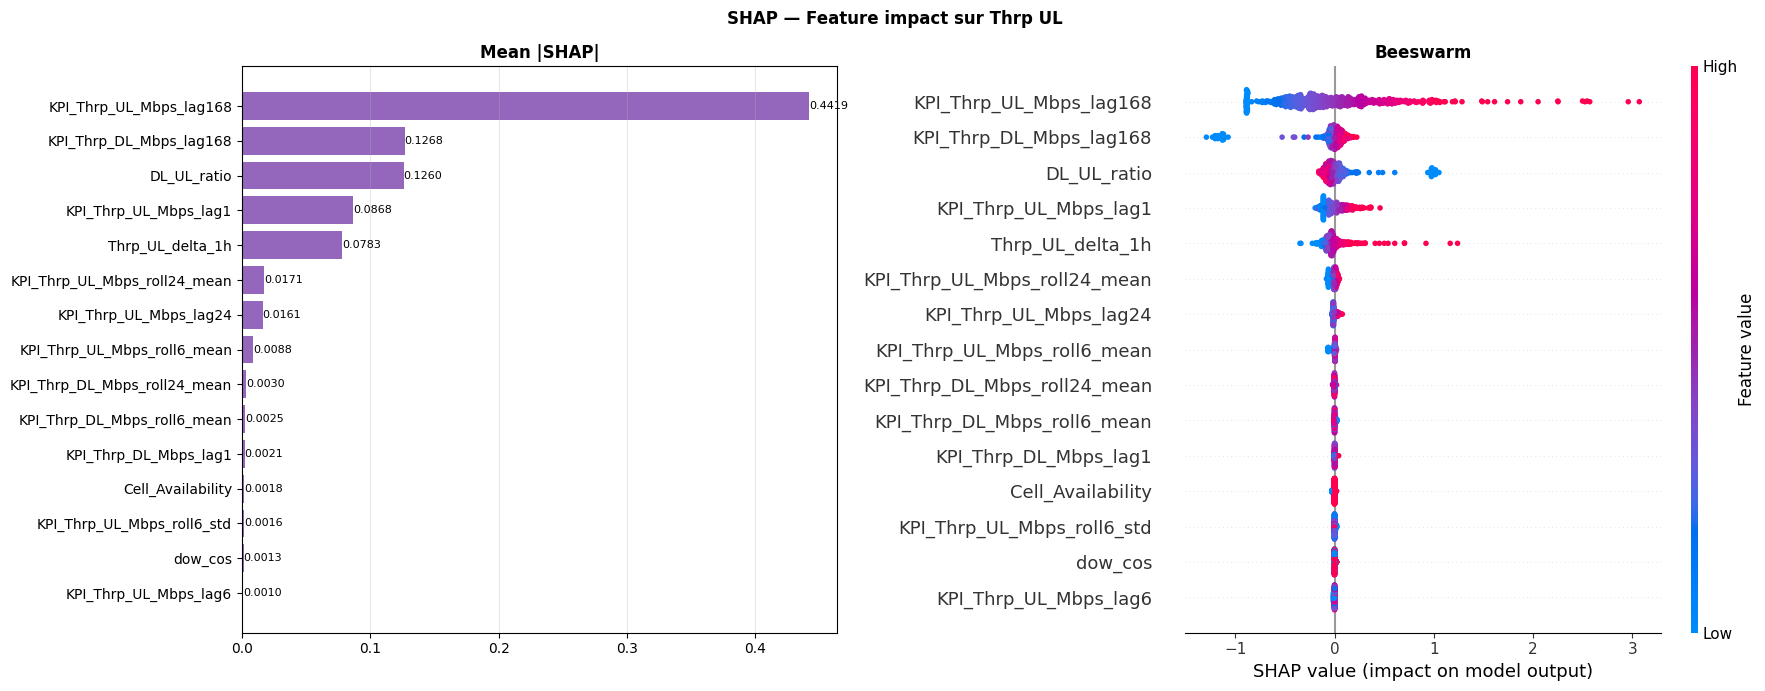

Top 10 features Thrp UL :
  KPI_Thrp_UL_Mbps_lag168                  SHAP=0.44187
  KPI_Thrp_DL_Mbps_lag168                  SHAP=0.12677
  DL_UL_ratio                              SHAP=0.12598
  KPI_Thrp_UL_Mbps_lag1                    SHAP=0.08678
  Thrp_UL_delta_1h                         SHAP=0.07832
  KPI_Thrp_UL_Mbps_roll24_mean             SHAP=0.01706
  KPI_Thrp_UL_Mbps_lag24                   SHAP=0.01613
  KPI_Thrp_UL_Mbps_roll6_mean              SHAP=0.00884
  KPI_Thrp_DL_Mbps_roll24_mean             SHAP=0.00299
  KPI_Thrp_DL_Mbps_roll6_mean              SHAP=0.00251


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 10 — SHAP RAPIDE (500 samples, XGBoost uniquement)
# ══════════════════════════════════════════════════════════════

for key in ['DL','UL']:
    d     = data[key]
    feats = FEATURES[key]
    print(f'\nSHAP {key} (500 samples)...')
    t0 = time.time()

    sample_idx = np.random.choice(len(d['X_te']), min(500, len(d['X_te'])), replace=False)
    explainer  = shap.TreeExplainer(
        xgb_models[key],
        feature_perturbation='tree_path_dependent'
    )
    shap_vals = explainer.shap_values(d['X_te'][sample_idx])
    print(f'  SHAP calculé en {time.time()-t0:.1f}s')

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'SHAP — Feature impact sur Thrp {key}', fontweight='bold')

    ms = np.abs(shap_vals).mean(axis=0)
    sd = pd.DataFrame({'feature': feats, 'shap': ms}).sort_values('shap').tail(15)
    color = '#1f77b4' if key=='DL' else '#9467bd'
    b = axes[0].barh(sd['feature'], sd['shap'], color=color)
    axes[0].bar_label(b, fmt='%.4f', fontsize=8)
    axes[0].set_title('Mean |SHAP|', fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='x')

    plt.sca(axes[1])
    shap.summary_plot(shap_vals, d['X_te'][sample_idx],
                      feature_names=feats, max_display=15,
                      show=False, plot_size=None)
    axes[1].set_title('Beeswarm', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/content/thrp_{key}_shap.png', dpi=130, bbox_inches='tight')
    plt.show()

    print(f'Top 10 features Thrp {key} :')
    for _, r in sd.sort_values('shap', ascending=False).head(10).iterrows():
        print(f'  {r["feature"]:<40} SHAP={r["shap"]:.5f}')

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 11 — SAUVEGARDE COMPLÈTE Thrp_DLUL_v2  (version corrigée)
# ══════════════════════════════════════════════════════════════
import joblib, os, json, torch

SAVE_DIR = '/content/drive/MyDrive/P2M_Models/Thrp_DLUL_v2'
os.makedirs(SAVE_DIR, exist_ok=True)

# Hyperparamètres fixes utilisés à l'entraînement (Cell 6)
NHITS_HIDDEN        = 256
NHITS_DROPOUT       = 0.15
NHITS_POOLING_SIZES = [1, 6, 24]

for key in ['DL', 'UL']:

    # ── N-HiTS ───────────────────────────────────────────────
    md = nhits_models[key]
    if md['model'] is not None:
        m = md['model']

        # ✅ seq_len lu depuis l'attribut qu'on vient d'ajouter sur NHiTS
        actual_seq_len = m.seq_len
        # ✅ n_features lu depuis l'attribut qu'on vient d'ajouter sur NHiTS
        actual_nfeat   = m.n_features

        torch.save({
            'state_dict'   : m.state_dict(),
            'y_mean'       : md['y_mean'],
            'y_std'        : md['y_std'],
            'n_features'   : actual_nfeat,
            'seq_len'      : actual_seq_len,
            'pooling_sizes': NHITS_POOLING_SIZES,
            'hidden_size'  : NHITS_HIDDEN,
            'dropout'      : NHITS_DROPOUT,
        }, f'{SAVE_DIR}/nhits_{key}.pth')
        print(f"✅ NHiTS {key} sauvegardé : seq_len={actual_seq_len} | n_features={actual_nfeat}")
    else:
        print(f"⚠️  NHiTS {key} est None (fallback XGBoost actif)")

    # ── XGBoost ──────────────────────────────────────────────
    xgb_models[key].save_model(f'{SAVE_DIR}/xgb_{key}.json')
    print(f"✅ XGBoost {key} sauvegardé")

    # ── Scalers ──────────────────────────────────────────────
    joblib.dump(scalers[key]['X'], f'{SAVE_DIR}/scaler_X_{key}.pkl')
    joblib.dump(scalers[key]['y'], f'{SAVE_DIR}/scaler_y_{key}.pkl')
    print(f"✅ Scalers {key} sauvegardés : X({scalers[key]['X'].n_features_in_} features)")

    # ── Meta-MLP (stacking) ──────────────────────────────────
    joblib.dump(results[key]['meta_mlp'], f'{SAVE_DIR}/meta_mlp_{key}.pkl')
    joblib.dump(results[key]['sc_meta'],  f'{SAVE_DIR}/sc_meta_{key}.pkl')
    print(f"✅ Meta-MLP {key} sauvegardé")

# ── Config JSON ──────────────────────────────────────────────
config = {
    'targets' : TARGETS,
    'features': {k: FEATURES[k] for k in FEATURES},
    'seq_len_requested': SEQ_LEN_REQUESTED,
    'seq_len_actual': {
        key: (nhits_models[key]['model'].seq_len
              if nhits_models[key]['model'] is not None else None)
        for key in ['DL', 'UL']
    },
    'metrics': {
        k: {
            'r2'      : float(results[k]['r2']),
            'mae'     : float(results[k]['mae']),
            'rmse'    : float(results[k]['rmse']),
            'nhits_r2': float(results[k]['nhits_r2']),
            'xgb_r2'  : float(results[k]['xgb_r2']),
        } for k in ['DL', 'UL']
    }
}
with open(f'{SAVE_DIR}/config.json', 'w') as f:
    json.dump(config, f, indent=2)

# ── Vérification finale ──────────────────────────────────────
print(f"\n{'='*55}")
print(f"  ✅ SAUVEGARDE TERMINÉE → {SAVE_DIR}")
print(f"{'='*55}")
for f in sorted(os.listdir(SAVE_DIR)):
    size_kb = os.path.getsize(os.path.join(SAVE_DIR, f)) / 1024
    print(f"  {f:<35} {size_kb:>8.1f} Ko")
print(f"\n  Métriques finales :")
for key in ['DL', 'UL']:
    m = config['metrics'][key]
    print(f"  Thrp {key} : R²={m['r2']:.4f}  MAE={m['mae']:.4f} Mbps  "
          f"(N-HiTS R²={m['nhits_r2']:.4f} | XGB R²={m['xgb_r2']:.4f})")

✅ NHiTS DL sauvegardé : seq_len=25 | n_features=25
✅ XGBoost DL sauvegardé
✅ Scalers DL sauvegardés : X(25 features)
✅ Meta-MLP DL sauvegardé
✅ NHiTS UL sauvegardé : seq_len=25 | n_features=29
✅ XGBoost UL sauvegardé
✅ Scalers UL sauvegardés : X(29 features)
✅ Meta-MLP UL sauvegardé

  ✅ SAUVEGARDE TERMINÉE → /content/drive/MyDrive/P2M_Models/Thrp_DLUL_v2
  config.json                              2.0 Ko
  meta_mlp_DL.pkl                        145.2 Ko
  meta_mlp_UL.pkl                        145.2 Ko
  nhits_DL.pth                          1534.1 Ko
  nhits_UL.pth                          1654.1 Ko
  sc_meta_DL.pkl                           0.8 Ko
  sc_meta_UL.pkl                           0.8 Ko
  scaler_X_DL.pkl                          1.2 Ko
  scaler_X_UL.pkl                          1.3 Ko
  scaler_y_DL.pkl                          0.6 Ko
  scaler_y_UL.pkl                          0.6 Ko
  xgb_DL.json                           1775.5 Ko
  xgb_UL.json                           21

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 12 — RECHARGEMENT APRÈS RECONNEXION
#
# ORDRE D'EXÉCUTION OBLIGATOIRE :
#   1. Cell 0  — installation + imports
#   2. Cell 1  — config TARGETS
#   3. Cell 2  — feature engineering sur df_ml  → df_t, FEATURES
#   4. Cell 4  — split + scalers                → df_train, df_test, data
#   5. Cell 5  — définition NHiTS, ThrpDataset (architecture)
#   6. Cette cellule
#   → Ensuite : Cell 8 (prédictions) ou Cell 9 (visualisation)
# ══════════════════════════════════════════════════════════════

import os, json, joblib, torch
import numpy as np
import xgboost as xgb

SAVE_DIR = '/content/drive/MyDrive/P2M_Models/Thrp_DLUL_v2'
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

# ── 0. Vérification dossier Drive ────────────────────────────
if not os.path.exists(SAVE_DIR):
    raise FileNotFoundError(
        f"Dossier introuvable : {SAVE_DIR}\n"
        "Monte Drive d'abord :\n"
        "  from google.colab import drive\n"
        "  drive.mount('/content/drive')"
    )
print(f"\n📁 Fichiers trouvés dans {SAVE_DIR} :")
for f in sorted(os.listdir(SAVE_DIR)):
    size_kb = os.path.getsize(os.path.join(SAVE_DIR, f)) / 1024
    print(f"   {f:<35} {size_kb:>8.1f} Ko")

# ── 1. Config JSON ────────────────────────────────────────────
with open(f'{SAVE_DIR}/config.json') as f:
    config = json.load(f)

TARGETS  = config['targets']
FEATURES = config['features']

print(f"\n✅ Config chargée :")
print(f"   Targets          : {list(TARGETS.values())}")
print(f"   SEQ_LEN demandé  : {config['seq_len_requested']}h")
print(f"   SEQ_LEN réel     : {config['seq_len_actual']}")
print(f"   Métriques sauvegardées :")
for key in ['DL', 'UL']:
    m = config['metrics'][key]
    print(f"   Thrp {key} : R²={m['r2']:.4f}  MAE={m['mae']:.4f} Mbps  "
          f"(N-HiTS R²={m['nhits_r2']:.4f} | XGB R²={m['xgb_r2']:.4f})")

# ── 2. Scalers ────────────────────────────────────────────────
scalers = {}
for key in ['DL', 'UL']:
    scalers[key] = {
        'X': joblib.load(f'{SAVE_DIR}/scaler_X_{key}.pkl'),
        'y': joblib.load(f'{SAVE_DIR}/scaler_y_{key}.pkl'),
    }
    print(f"✅ Scaler {key} chargé : X({scalers[key]['X'].n_features_in_} features)")

# ── 3. XGBoost ────────────────────────────────────────────────
xgb_models = {}
for key in ['DL', 'UL']:
    xgb_models[key] = xgb.XGBRegressor()
    xgb_models[key].load_model(f'{SAVE_DIR}/xgb_{key}.json')
    print(f"✅ XGBoost {key} chargé")

# ── 4. N-HiTS (avec déduction automatique des hyperparamètres) ─
# ✅ CORRECTION : n_features et seq_len lus depuis les POIDS réels
#    du checkpoint — jamais recalculés depuis X courant
nhits_models = {}
for key in ['DL', 'UL']:
    pth_path = f'{SAVE_DIR}/nhits_{key}.pth'
    if not os.path.exists(pth_path):
        print(f"⚠️  NHiTS {key} : .pth introuvable → None (XGBoost seul)")
        nhits_models[key] = {'model': None, 'y_mean': 0.0, 'y_std': 1.0, 'seq_len': 24}
        continue

    ckpt = torch.load(pth_path, map_location=DEVICE)

    pooling_sizes = ckpt.get('pooling_sizes', [1, 6, 24])

    # Lire n_features et seq_len depuis le checkpoint
    # Si absent (ancienne sauvegarde), les déduire depuis les poids
    if 'n_features' in ckpt and 'seq_len' in ckpt:
        n_features   = ckpt['n_features']
        seq_len_real = ckpt['seq_len']
    else:
        # Déduction robuste depuis les formes de poids
        # blocks.i.mlp.0.weight shape = [hidden, n_features * (seq_len // pooling_sizes[i])]
        w0 = ckpt['state_dict']['blocks.0.mlp.0.weight'].shape[1]
        w1 = ckpt['state_dict']['blocks.1.mlp.0.weight'].shape[1]
        w2 = ckpt['state_dict']['blocks.2.mlp.0.weight'].shape[1]
        p0, p1, p2 = pooling_sizes
        seq_len_real = None
        for candidate in range(p2, 100000, p2):
            s2 = candidate // p2
            if w2 % s2 == 0:
                nf = w2 // s2
                if w1 == nf * (candidate // p1) and w0 == nf * (candidate // p0):
                    seq_len_real = candidate
                    n_features   = nf
                    break
        if seq_len_real is None:
            raise ValueError(f"Impossible de déduire seq_len depuis les poids NHiTS {key}")
        print(f"   ⚠️  NHiTS {key} : n_features={n_features}, seq_len={seq_len_real} (déduits des poids)")

    hidden_size = ckpt.get('hidden_size', 256)
    dropout     = ckpt.get('dropout', 0.15)

    print(f"\n   [DEBUG] NHiTS {key} :")
    print(f"   n_features={n_features} | seq_len={seq_len_real} | hidden={hidden_size}")

    # Reconstruire avec les VRAIS hyperparamètres
    model_nhits = NHiTS(
        n_features    = n_features,
        seq_len       = seq_len_real,
        pooling_sizes = pooling_sizes,
        hidden_size   = hidden_size,
        dropout       = dropout
    ).to(DEVICE)

    model_nhits.load_state_dict(ckpt['state_dict'])
    model_nhits.eval()

    nhits_models[key] = {
        'model'  : model_nhits,
        'y_mean' : ckpt['y_mean'],
        'y_std'  : ckpt['y_std'],
        'seq_len': seq_len_real,   # ✅ vrai seq_len pour predict_nhits
    }
    n_params = sum(p.numel() for p in model_nhits.parameters())
    print(f"   ✅ NHiTS {key} chargé : {n_params:,} params | "
          f"y_mean={ckpt['y_mean']:.4f} | y_std={ckpt['y_std']:.4f}")

# ── 5. Meta-MLP (stacking) ────────────────────────────────────
results = {}
for key in ['DL', 'UL']:
    meta_mlp, sc_meta = None, None
    if os.path.exists(f'{SAVE_DIR}/meta_mlp_{key}.pkl'):
        meta_mlp = joblib.load(f'{SAVE_DIR}/meta_mlp_{key}.pkl')
        sc_meta  = joblib.load(f'{SAVE_DIR}/sc_meta_{key}.pkl')
        print(f"✅ Meta-MLP {key} chargé")
    else:
        print(f"⚠️  Meta-MLP {key} introuvable (stacking désactivé)")
    results[key] = {'meta_mlp': meta_mlp, 'sc_meta': sc_meta}

# ── 6. SEQ_LEN global pour predict_nhits ─────────────────────
# Utiliser le vrai seq_len stocké dans nhits_models, pas SEQ_LEN_REQUESTED
SEQ_LEN = nhits_models['DL']['seq_len']

# ── 7. Vérification finale ────────────────────────────────────
print(f"\n{'='*55}")
print(f"  ✅ RECHARGEMENT TERMINÉ")
print(f"{'='*55}")
print(f"  nhits_models : DL={nhits_models['DL']['model'] is not None} "
      f"(seq={nhits_models['DL']['seq_len']}) | "
      f"UL={nhits_models['UL']['model'] is not None} "
      f"(seq={nhits_models['UL']['seq_len']})")
print(f"  xgb_models   : DL=✅ | UL=✅")
print(f"  scalers      : DL=✅ | UL=✅")
print(f"  SEQ_LEN      : {SEQ_LEN}h | DEVICE : {DEVICE}")
print(f"{'='*55}")
print(f"  → Prêt pour Cell 8 (prédictions) ✅")

Device : cuda

📁 Fichiers trouvés dans /content/drive/MyDrive/P2M_Models/Thrp_DLUL_v2 :
   config.json                              2.0 Ko
   meta_mlp_DL.pkl                        145.2 Ko
   meta_mlp_UL.pkl                        145.2 Ko
   nhits_DL.pth                          1534.1 Ko
   nhits_UL.pth                          1654.1 Ko
   sc_meta_DL.pkl                           0.8 Ko
   sc_meta_UL.pkl                           0.8 Ko
   scaler_X_DL.pkl                          1.2 Ko
   scaler_X_UL.pkl                          1.3 Ko
   scaler_y_DL.pkl                          0.6 Ko
   scaler_y_UL.pkl                          0.6 Ko
   xgb_DL.json                           1775.5 Ko
   xgb_UL.json                           2188.6 Ko

✅ Config chargée :
   Targets          : ['KPI_Thrp_DL_Mbps', 'KPI_Thrp_UL_Mbps']
   SEQ_LEN demandé  : 168h
   SEQ_LEN réel     : {'DL': 25, 'UL': 25}
   Métriques sauvegardées :
   Thrp DL : R²=0.9984  MAE=0.0757 Mbps  (N-HiTS R²=0.7026 | XGB R²=

**Système de Scoring de Santé Réseau (Network Health Score)**

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL HS-1 — DÉFINITION DES POIDS ET SENS DES KPIs
# ══════════════════════════════════════════════════════════════
# Sens :  +1 = plus c'est haut, mieux c'est (ex: CSSR)
#         -1 = plus c'est haut, moins c'est bon (ex: DCR)
# ══════════════════════════════════════════════════════════════

KPI_CONFIG = {
    # KPI                    poids   sens   description
    'KPI_RRC_SR':          (0.20,   +1,   'RRC Setup Success Rate'),
    'KPI_ERAB_SR':         (0.18,   +1,   'E-RAB Setup Success Rate'),
    'KPI_DCR':             (0.20,   -1,   'Drop Call Rate'),
    'KPI_HOSR':            (0.12,   +1,   'Handover Success Rate intra'),
    'KPI_HOSR_InterFreq':  (0.08,   +1,   'Handover Inter-Fréquence'),
    'KPI_HOSR_InterRAT':   (0.06,   +1,   'Handover Inter-RAT (LTE→2G/3G)'),
    'KPI_Thrp_DL_Mbps':    (0.08,   +1,   'Débit Downlink'),
    'KPI_Thrp_UL_Mbps':    (0.04,   +1,   'Débit Uplink'),
    'Cell_Availability':   (0.03,   +1,   'Disponibilité cellule'),
    'CSFB_SR':             (0.01,   +1,   'CS Fallback Success Rate'),
}

# Vérification que les poids somment à 1.0
total_weight = sum(v[0] for v in KPI_CONFIG.values())
print(f"Somme des poids : {total_weight:.2f} ✅" if abs(total_weight - 1.0) < 1e-9
      else f"⚠️ Somme des poids = {total_weight:.2f} ≠ 1.0")

# Vérification des colonnes disponibles
missing = [k for k in KPI_CONFIG if k not in df_ml.columns]
if missing:
    print(f"⚠️ Colonnes manquantes : {missing}")
else:
    print(f"✅ Tous les KPIs présents dans df_ml")

Somme des poids : 1.00 ✅
✅ Tous les KPIs présents dans df_ml


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL HS-2 — CALCUL DU NETWORK HEALTH SCORE (0 → 100)
# ══════════════════════════════════════════════════════════════
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

df_hs = df_ml.copy()

# ── Étape 1 : Normalisation Min-Max par KPI (0→1) ─────────────
# On normalise sur l'ensemble du dataset pour avoir une référence globale
scaler_hs = MinMaxScaler()

kpi_cols = list(KPI_CONFIG.keys())
df_hs[[f'norm_{k}' for k in kpi_cols]] = scaler_hs.fit_transform(df_hs[kpi_cols])

# ── Étape 2 : Inversion des KPIs négatifs ────────────────────
# Ex : DCR normalisé → score_DCR = 1 - norm_DCR
for kpi, (weight, sens, desc) in KPI_CONFIG.items():
    col_norm = f'norm_{kpi}'
    col_score = f'score_{kpi}'
    if sens == +1:
        df_hs[col_score] = df_hs[col_norm]
    else:  # sens == -1
        df_hs[col_score] = 1 - df_hs[col_norm]

# ── Étape 3 : Score composite pondéré (0→100) ─────────────────
score_cols = [f'score_{k}' for k in kpi_cols]
weights    = [KPI_CONFIG[k][0] for k in kpi_cols]

df_hs['Health_Score_Raw'] = sum(
    df_hs[score_cols[i]] * weights[i] for i in range(len(kpi_cols))
) * 100  # ramène à 0-100

# ── Étape 4 : Pénalité anomalie confirmée ─────────────────────
# Une anomalie confirmée (IF + AE) pénalise le score de -15 points
PENALITE_ANOMALIE = 15
df_hs['Health_Score'] = (
    df_hs['Health_Score_Raw'] - df_hs['Anomalie_Confirmee'] * PENALITE_ANOMALIE
).clip(0, 100)  # on borne entre 0 et 100

# ── Étape 5 : Catégories de santé ─────────────────────────────
def categoriser_score(score):
    if score >= 85:   return '🟢 Excellent'
    elif score >= 70: return '🟡 Bon'
    elif score >= 50: return '🟠 Dégradé'
    elif score >= 30: return '🔴 Critique'
    else:             return '⛔ Hors service'

df_hs['Health_Category'] = df_hs['Health_Score'].apply(categoriser_score)

print("✅ Health Score calculé")
print(f"\n📊 Distribution des scores :")
print(df_hs['Health_Score'].describe().round(2))
print(f"\n📊 Répartition par catégorie :")
print(df_hs['Health_Category'].value_counts())

✅ Health Score calculé

📊 Distribution des scores :
count    1959516.00
mean          88.63
std            1.98
min           36.33
25%           88.53
50%           89.04
75%           89.47
max           96.10
Name: Health_Score, dtype: float64

📊 Répartition par catégorie :
Health_Category
🟢 Excellent    1926547
🟡 Bon            28169
🟠 Dégradé         4785
🔴 Critique          15
Name: count, dtype: int64


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL HS-3 — HEALTH SCORE AGRÉGÉ PAR CELLULE
# ══════════════════════════════════════════════════════════════

# Agrégation par cellule : moyenne, min (pire état), std (instabilité)
cell_health = df_hs.groupby('Cell_Name').agg(
    Health_Score_Mean  = ('Health_Score', 'mean'),
    Health_Score_Min   = ('Health_Score', 'min'),
    Health_Score_Std   = ('Health_Score', 'std'),
    Nb_Anomalies_Conf  = ('Anomalie_Confirmee', 'sum'),
    Nb_Observations    = ('Health_Score', 'count'),
    DCR_Moyen          = ('KPI_DCR', 'mean'),
    Thrp_DL_Moyen      = ('KPI_Thrp_DL_Mbps', 'mean'),
    CSSR_Moyen         = ('KPI_RRC_SR', 'mean'),
    HOSR_Moyen         = ('KPI_HOSR', 'mean'),
).reset_index()

# Taux d'anomalie par cellule
cell_health['Taux_Anomalie_Pct'] = (
    cell_health['Nb_Anomalies_Conf'] / cell_health['Nb_Observations'] * 100
).round(2)

# Catégorie finale par cellule (basée sur la moyenne)
cell_health['Health_Category'] = cell_health['Health_Score_Mean'].apply(categoriser_score)

# Classement : cellules les plus dégradées en tête
cell_health = cell_health.sort_values('Health_Score_Mean', ascending=True)

print("✅ Scoring par cellule terminé")
print(f"Nombre de cellules analysées : {len(cell_health)}")
print(f"\n🔴 TOP 15 cellules les plus dégradées :")
print(cell_health[['Cell_Name','Health_Score_Mean','Health_Score_Min',
                    'Taux_Anomalie_Pct','DCR_Moyen','CSSR_Moyen']].head(15).to_string(index=False))

✅ Scoring par cellule terminé
Nombre de cellules analysées : 20250

🔴 TOP 15 cellules les plus dégradées :
           Cell_Name  Health_Score_Mean  Health_Score_Min  Taux_Anomalie_Pct  DCR_Moyen  CSSR_Moyen
     SENO_ISSAGA_e73          68.372892         57.856735              61.86   0.467456   99.910541
      D_SAMBARDE_e72          68.386499         53.944695               5.15   0.000000    1.030928
    KEUR_MASSAR03_T2          68.681468         36.333333              68.37   0.623078   87.100660
          TINKOTO_e1          69.498387         62.857019              87.63   0.159683   97.741783
          SARAYA_e26          72.483205         60.331574              47.42   0.064448   99.213858
     DIENOUDIALA_e24          72.640853         58.000000              31.96   0.000000   99.882415
         TINKOTO_e24          72.812782         61.113573              56.70   0.036253   98.478798
         TINKOTO_e71          73.069991         61.676831              59.79   0.329828   99.

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL HS-4 — HEALTH SCORE PAR PÉRIODE TEMPORELLE
# ══════════════════════════════════════════════════════════════
# Adapter 'Date_Heure' au nom de ta colonne datetime dans df_ml

# Détecter la colonne datetime
datetime_col = None
for col in df_hs.columns:
    if pd.api.types.is_datetime64_any_dtype(df_hs[col]):
        datetime_col = col
        break
    elif 'date' in col.lower() or 'time' in col.lower() or 'heure' in col.lower():
        datetime_col = col

if datetime_col:
    df_hs[datetime_col] = pd.to_datetime(df_hs[datetime_col])
    df_hs['Heure']        = df_hs[datetime_col].dt.hour
    df_hs['Jour_Semaine'] = df_hs[datetime_col].dt.day_name()
    df_hs['Date']         = df_hs[datetime_col].dt.date
    df_hs['Periode']      = df_hs[datetime_col].dt.to_period('W')  # semaine

    # Heure de pointe vs creuse (définition télécom standard)
    def periode_trafic(heure):
        if 8 <= heure <= 12 or 17 <= heure <= 22:
            return 'Heure de Pointe'
        elif 0 <= heure <= 6:
            return 'Heure Creuse (Nuit)'
        else:
            return 'Heure Normale'

    df_hs['Tranche_Horaire'] = df_hs['Heure'].apply(periode_trafic)

    # Score moyen par tranche horaire
    score_horaire = df_hs.groupby('Heure')['Health_Score'].mean().reset_index()

    # Score par jour de la semaine
    score_jour = df_hs.groupby('Jour_Semaine')['Health_Score'].mean().reindex(
        ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    )

    print("📊 Health Score moyen par tranche :")
    print(df_hs.groupby('Tranche_Horaire')['Health_Score'].agg(['mean','min','count']).round(2))

    print("\n📊 Health Score moyen par jour :")
    print(score_jour.round(2).to_string())

else:
    print("⚠️ Aucune colonne datetime détectée — vérifie le nom de ta colonne temporelle")
    print("Colonnes disponibles :", [c for c in df_hs.columns if any(x in c.lower()
          for x in ['date','time','heure','periode','timestamp'])])

📊 Health Score moyen par tranche :
                      mean    min   count
Tranche_Horaire                          
Heure Creuse (Nuit)  88.58  36.33  704093
Heure Normale        88.66  42.14  422864
Heure de Pointe      88.65  45.84  832559

📊 Health Score moyen par jour :
Jour_Semaine
Monday       88.61
Tuesday      88.65
Wednesday    88.63
Thursday     88.53
Friday         NaN
Saturday       NaN
Sunday       88.65


ValueError: The number of FixedLocator locations (5), usually from a call to set_ticks, does not match the number of labels (7).

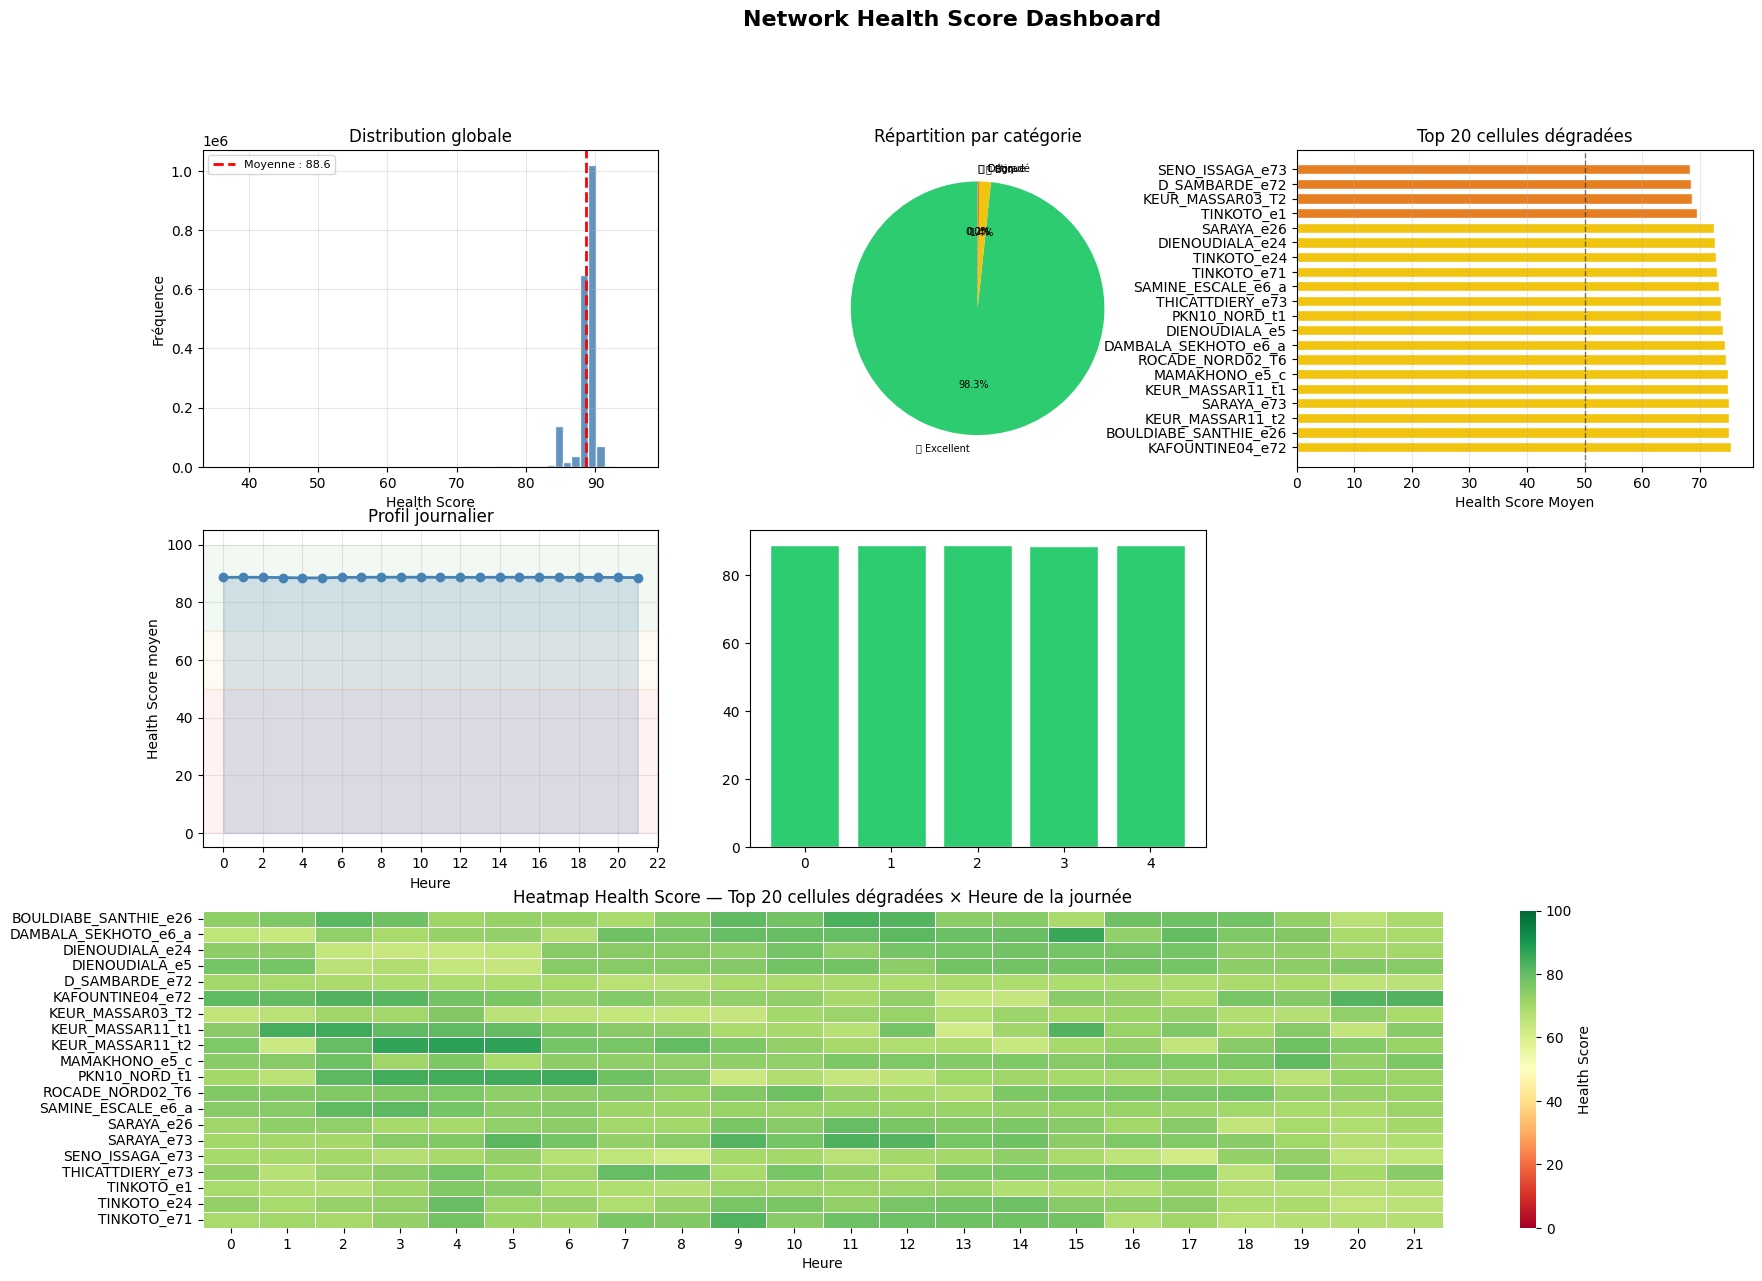

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL HS-5 — VISUALISATIONS HEALTH SCORE
# ══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

fig = plt.figure(figsize=(20, 14))
fig.suptitle('Network Health Score Dashboard', fontsize=16, fontweight='bold', y=0.98)

COLORS = {
    '🟢 Excellent'   : '#2ecc71',
    '🟡 Bon'         : '#f1c40f',
    '🟠 Dégradé'     : '#e67e22',
    '🔴 Critique'    : '#e74c3c',
    '⛔ Hors service': '#8e44ad'
}

# ── 1. Distribution globale des scores ───────────────────────
ax1 = fig.add_subplot(3, 3, 1)
ax1.hist(df_hs['Health_Score'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(df_hs['Health_Score'].mean(), color='red', lw=2, ls='--',
            label=f"Moyenne : {df_hs['Health_Score'].mean():.1f}")
ax1.set_xlabel('Health Score')
ax1.set_ylabel('Fréquence')
ax1.set_title('Distribution globale')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ── 2. Répartition par catégorie (pie chart) ─────────────────
ax2 = fig.add_subplot(3, 3, 2)
cat_counts = df_hs['Health_Category'].value_counts()
colors_pie = [COLORS.get(c, 'grey') for c in cat_counts.index]
wedges, texts, autotexts = ax2.pie(
    cat_counts.values, labels=cat_counts.index,
    colors=colors_pie, autopct='%1.1f%%',
    startangle=90, textprops={'fontsize': 7}
)
ax2.set_title('Répartition par catégorie')

# ── 3. Top 20 cellules les plus dégradées ────────────────────
ax3 = fig.add_subplot(3, 3, 3)
top20_deg = cell_health.head(20)
colors_bar = [COLORS.get(c, 'grey') for c in top20_deg['Health_Category']]
bars = ax3.barh(top20_deg['Cell_Name'], top20_deg['Health_Score_Mean'],
                color=colors_bar, edgecolor='white', height=0.7)
ax3.set_xlabel('Health Score Moyen')
ax3.set_title('Top 20 cellules dégradées')
ax3.axvline(50, color='black', lw=1, ls='--', alpha=0.5)
ax3.grid(True, alpha=0.3, axis='x')
ax3.invert_yaxis()

# ── 4. Score par heure de la journée ─────────────────────────
if datetime_col:
    ax4 = fig.add_subplot(3, 3, 4)
    ax4.plot(score_horaire['Heure'], score_horaire['Health_Score'],
             marker='o', color='steelblue', lw=2)
    ax4.fill_between(score_horaire['Heure'], score_horaire['Health_Score'],
                     alpha=0.2, color='steelblue')
    ax4.axhspan(0,  50, alpha=0.05, color='red')
    ax4.axhspan(50, 70, alpha=0.05, color='orange')
    ax4.axhspan(70, 100, alpha=0.05, color='green')
    ax4.set_xlabel('Heure')
    ax4.set_ylabel('Health Score moyen')
    ax4.set_title('Profil journalier')
    ax4.set_xticks(range(0, 24, 2))
    ax4.grid(True, alpha=0.3)

# ── 5. Heatmap cellule × jour ────────────────────────────────
if datetime_col:
    ax5 = fig.add_subplot(3, 1, 3)
    top_cells_list = cell_health.head(20)['Cell_Name'].tolist()
    pivot = df_hs[df_hs['Cell_Name'].isin(top_cells_list)].pivot_table(
        values='Health_Score',
        index='Cell_Name',
        columns='Heure',
        aggfunc='mean'
    )
    sns.heatmap(pivot, ax=ax5, cmap='RdYlGn', vmin=0, vmax=100,
                linewidths=0.5, cbar_kws={'label': 'Health Score'},
                annot=False)
    ax5.set_title('Heatmap Health Score — Top 20 cellules dégradées × Heure de la journée')
    ax5.set_xlabel('Heure')
    ax5.set_ylabel('')

# ── 6. Score moyen par jour de semaine ───────────────────────
if datetime_col:
    ax6 = fig.add_subplot(3, 3, 5)
    score_jour_clean = score_jour.fillna(0) # Fill NaNs with 0 before further processing
    bar_colors = ['#e74c3c' if v < 70 else '#2ecc71' for v in score_jour_clean.values]
    ax6.bar(range(len(score_jour_clean)), score_jour_clean.values,
            color=bar_colors, edgecolor='white')
    ax6.set_xticks(range(len(score_jour_clean)))
    ax6.set_xticklabels(['Lun','Mar','Mer','Jeu','Ven','Sam','Dim'], fontsize=8)
    ax6.set_ylabel('Health Score moyen')
    ax6.set_title('Score par jour de semaine')
    ax6.axhline(70, color='orange', lw=1.5, ls='--', alpha=0.7)
    ax6.grid(True, alpha=0.3, axis='y')

# ── 7. Scatter : Taux anomalie vs Health Score ───────────────
ax7 = fig.add_subplot(3, 3, 6)
scatter = ax7.scatter(
    cell_health['Taux_Anomalie_Pct'],
    cell_health['Health_Score_Mean'],
    c=cell_health['Health_Score_Mean'],
    cmap='RdYlGn', vmin=0, vmax=100,
    alpha=0.7, s=40, edgecolors='none'
)
plt.colorbar(scatter, ax=ax7, label='Health Score')
ax7.set_xlabel('Taux anomalie confirmée (%)')
ax7.set_ylabel('Health Score moyen')
ax7.set_title('Anomalie vs Health Score par cellule')
ax7.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/network_health_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard sauvegardé : /content/network_health_dashboard.png")

In [ ]:
# DIAGNOSTIC — jours présents dans le dataset
print("Jours présents dans le dataset :")
print(df_hs['Jour_Semaine'].value_counts())

print(f"\nPériode couverte :")
print(f"  Du  : {df_hs[datetime_col].min()}")
print(f"  Au  : {df_hs[datetime_col].max()}")
print(f"  Nb jours distincts : {df_hs['Date'].nunique()}")

Jours présents dans le dataset :
Jour_Semaine
Wednesday    443470
Tuesday      442666
Monday       442517
Sunday       441710
Thursday     189153
Name: count, dtype: int64

Période couverte :
  Du  : 2025-06-01 00:00:00
  Au  : 2025-06-05 09:00:00
  Nb jours distincts : 5


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL HS-6 — EXPORT DES RÉSULTATS
# ══════════════════════════════════════════════════════════════
import os

SAVE_DIR_HS = '/content/drive/MyDrive/P2M_Models/HealthScore'
os.makedirs(SAVE_DIR_HS, exist_ok=True)

# Scoring par cellule — rapport principal
cell_health.to_csv(f'{SAVE_DIR_HS}/cell_health_scores.csv', index=False)

# Dataset complet enrichi du Health Score
cols_export = ['Cell_Name', 'Health_Score', 'Health_Category',
               'Health_Score_Raw', 'Anomalie_Confirmee',
               'IF_Anomalie', 'AE_Anomalie'] + kpi_cols

if datetime_col:
    cols_export = [datetime_col] + cols_export

df_export = df_hs[[c for c in cols_export if c in df_hs.columns]]
df_export.to_csv(f'{SAVE_DIR_HS}/df_health_scores_complet.csv', index=False)

# Résumé statistique
summary = {
    'score_moyen_global'     : round(df_hs['Health_Score'].mean(), 2),
    'score_median_global'    : round(df_hs['Health_Score'].median(), 2),
    'pct_excellent'          : round((df_hs['Health_Category'] == '🟢 Excellent').mean() * 100, 2),
    'pct_degrade_critique'   : round(df_hs['Health_Category'].isin(
                                ['🟠 Dégradé','🔴 Critique','⛔ Hors service']).mean() * 100, 2),
    'nb_cellules_critiques'  : int((cell_health['Health_Score_Mean'] < 50).sum()),
    'cellule_plus_degradee'  : cell_health.iloc[0]['Cell_Name'],
    'score_pire_cellule'     : round(cell_health.iloc[0]['Health_Score_Mean'], 2),
}

import json
with open(f'{SAVE_DIR_HS}/health_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("✅ Export terminé")
print(f"\n📊 RÉSUMÉ SANTÉ RÉSEAU :")
for k, v in summary.items():
    print(f"   {k:35s} : {v}")

✅ Export terminé

📊 RÉSUMÉ SANTÉ RÉSEAU :
   score_moyen_global                  : 88.63
   score_median_global                 : 89.04
   pct_excellent                       : 98.32
   pct_degrade_critique                : 0.24
   nb_cellules_critiques               : 0
   cellule_plus_degradee               : SENO_ISSAGA_e73
   score_pire_cellule                  : 68.37


**Module d'Alerting Intelligent**

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL AL-1 — CLASSIFICATION DES TYPES D'INCIDENTS RÉSEAU
# Règles métier télécom LTE standards (3GPP KPI thresholds)
# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np

# ── Seuils KPI standards télécom (ajustables selon ton opérateur) ──
SEUILS = {
    'KPI_RRC_SR'        : 95.0,   # RRC Setup SR < 95% → dégradé
    'KPI_ERAB_SR'       : 95.0,   # E-RAB SR < 95% → dégradé
    'KPI_DCR'           :  2.0,   # Drop Call Rate > 2% → critique
    'KPI_HOSR'          : 90.0,   # Handover SR intra < 90%
    'KPI_HOSR_InterFreq': 85.0,   # HO inter-freq < 85%
    'KPI_HOSR_InterRAT' : 80.0,   # HO inter-RAT < 80%
    'KPI_Thrp_DL_Mbps'  :  2.0,   # Thrp DL < 2 Mbps → congestion
    'Cell_Availability' : 95.0,   # Dispo < 95% → risque outage
    'Delta_ERAB'        : -5.0,   # Delta < -5% → problème cœur réseau
}

df_alert = df_hs.copy()

# ── Vérification des colonnes nécessaires ─────────────────────
missing_cols = [c for c in SEUILS if c not in df_alert.columns
                and c != 'Delta_ERAB']
if missing_cols:
    print(f"⚠️ Colonnes manquantes : {missing_cols}")

# ── Recréer Delta_ERAB si absent ──────────────────────────────
if 'Delta_ERAB' not in df_alert.columns:
    if 'KPI_ERAB_SR' in df_alert.columns and 'KPI_RRC_SR' in df_alert.columns:
        df_alert['Delta_ERAB'] = df_alert['KPI_ERAB_SR'] - df_alert['KPI_RRC_SR']
        print("  ✅ Delta_ERAB recalculé")

# ══════════════════════════════════════════════════════════════
# RÈGLES DE CLASSIFICATION DES INCIDENTS (non exclusives)
# ══════════════════════════════════════════════════════════════

# 1. Congestion Radio — débit effondré + DCR élevé
cond_congestion = (
    (df_alert.get('KPI_DCR', pd.Series(0, index=df_alert.index)) > SEUILS['KPI_DCR']) &
    (df_alert.get('KPI_Thrp_DL_Mbps', pd.Series(999, index=df_alert.index)) < SEUILS['KPI_Thrp_DL_Mbps'])
)

# 2. Échec Handover — HO intra ou inter-freq dégradé
cond_ho_failure = (
    (df_alert.get('KPI_HOSR', pd.Series(100, index=df_alert.index)) < SEUILS['KPI_HOSR']) |
    (df_alert.get('KPI_HOSR_InterFreq', pd.Series(100, index=df_alert.index)) < SEUILS['KPI_HOSR_InterFreq'])
)

# 3. Problème Cœur Réseau — E-RAB chute mais pas RRC
#    (l'UE s'attache mais le bearer ne s'établit pas → SGW/S1-U)
cond_core = (
    df_alert.get('Delta_ERAB', pd.Series(0, index=df_alert.index)) < SEUILS['Delta_ERAB']
)

# 4. Risque Outage Cellule — disponibilité critique + RRC dégradé
cond_outage = (
    (df_alert.get('Cell_Availability', pd.Series(100, index=df_alert.index)) < SEUILS['Cell_Availability']) &
    (df_alert.get('KPI_RRC_SR', pd.Series(100, index=df_alert.index)) < SEUILS['KPI_RRC_SR'])
)

# 5. Interférence Radio — RRC dégradé mais E-RAB encore correct
#    (l'UE a du mal à s'attacher → problème interférence uplink)
cond_interference = (
    (df_alert.get('KPI_RRC_SR', pd.Series(100, index=df_alert.index)) < SEUILS['KPI_RRC_SR']) &
    (df_alert.get('KPI_ERAB_SR', pd.Series(100, index=df_alert.index)) >= SEUILS['KPI_ERAB_SR'])
)

# ── Application des labels ────────────────────────────────────
df_alert['Type_Incident'] = 'Normal'
df_alert.loc[cond_interference, 'Type_Incident'] = 'Interférence_Radio'
df_alert.loc[cond_ho_failure,   'Type_Incident'] = 'Echec_Handover'
df_alert.loc[cond_core,         'Type_Incident'] = 'Problème_Cœur_Réseau'
df_alert.loc[cond_outage,       'Type_Incident'] = 'Risque_Outage'
df_alert.loc[cond_congestion,   'Type_Incident'] = 'Congestion_Radio'  # priorité max → écrase

print("✅ Classification des incidents terminée")
print(f"\n📊 Répartition des types d'incidents :")
print(df_alert['Type_Incident'].value_counts())
print(f"\n  → {(df_alert['Type_Incident'] != 'Normal').sum():,} observations présentent un incident détecté")

✅ Classification des incidents terminée

📊 Répartition des types d'incidents :
Type_Incident
Normal                  1908299
Echec_Handover            43680
Interférence_Radio         5206
Problème_Cœur_Réseau       1874
Risque_Outage               382
Congestion_Radio             75
Name: count, dtype: int64

  → 51,217 observations présentent un incident détecté


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL AL-2 — CONFIDENCE SCORE (0 → 100)
# Fusionne les signaux : Isolation Forest + Autoencoder +
# Random Forest + Health Score + KPI règles métier
# ══════════════════════════════════════════════════════════════

# ── Vérification des colonnes de signaux disponibles ──────────
signal_cols = {
    'IF_Anomalie'      : 'Isolation Forest',
    'AE_Anomalie'      : 'Autoencoder LSTM',
    'RF_Prediction'    : 'Random Forest',
    'Anomalie_Confirmee': 'IF ∩ AE',
}
for col, label in signal_cols.items():
    available = col in df_alert.columns
    print(f"  {'✅' if available else '⚠️ ABSENT'} {label:25s} → colonne '{col}'")

# ── Points par signal (total max = 100) ───────────────────────
POINTS = {
    'IF_Anomalie'       : 20,   # signal non supervisé (IF)
    'AE_Anomalie'       : 25,   # signal reconstruction (AE)
    'RF_Prediction'     : 20,   # signal supervisé (RF)
    'Anomalie_Confirmee': 15,   # bonus confirmation croisée IF ∩ AE
    'kpi_rules'         : 15,   # au moins 1 règle métier déclenchée
    'health_score_low'  : 5,    # Health Score < 50 (état général dégradé)
}

def compute_confidence(row):
    score = 0
    # Signal Isolation Forest
    if row.get('IF_Anomalie', 0) == 1:
        score += POINTS['IF_Anomalie']
    # Signal Autoencoder
    if row.get('AE_Anomalie', 0) == 1:
        score += POINTS['AE_Anomalie']
    # Signal Random Forest
    if row.get('RF_Prediction', 0) == 1:
        score += POINTS['RF_Prediction']
    # Bonus confirmation croisée
    if row.get('Anomalie_Confirmee', 0) == 1:
        score += POINTS['Anomalie_Confirmee']
    # Règle métier déclenchée
    if row.get('Type_Incident', 'Normal') != 'Normal':
        score += POINTS['kpi_rules']
    # Health Score dégradé
    if row.get('Health_Score', 100) < 50:
        score += POINTS['health_score_low']
    return min(score, 100)

print("\n⏳ Calcul du Confidence Score...")
df_alert['Confidence_Score'] = df_alert.apply(compute_confidence, axis=1)

# ── Niveaux d'alerte ──────────────────────────────────────────
def niveau_alerte(score):
    if score >= 70:   return '🔴 CRITIQUE'
    elif score >= 50: return '🟠 MAJEURE'
    elif score >= 30: return '🟡 MINEURE'
    else:             return '⚪ BRUIT'

df_alert['Niveau_Alerte'] = df_alert['Confidence_Score'].apply(niveau_alerte)

print("✅ Confidence Score calculé")
print(f"\n📊 Distribution du Confidence Score :")
print(df_alert['Confidence_Score'].describe().round(2))
print(f"\n📊 Répartition des niveaux d'alerte :")
print(df_alert['Niveau_Alerte'].value_counts())
print(f"\n  → Alertes réelles (≥ 50) : {(df_alert['Confidence_Score'] >= 50).sum():,}")
print(f"  → Fausses alarmes filtrées (< 30) : {(df_alert['Confidence_Score'] < 30).sum():,}")

  ✅ Isolation Forest          → colonne 'IF_Anomalie'
  ✅ Autoencoder LSTM          → colonne 'AE_Anomalie'
  ⚠️ ABSENT Random Forest             → colonne 'RF_Prediction'
  ✅ IF ∩ AE                   → colonne 'Anomalie_Confirmee'

⏳ Calcul du Confidence Score...
✅ Confidence Score calculé

📊 Distribution du Confidence Score :
count    1959516.00
mean           2.49
std            8.58
min            0.00
25%            0.00
50%            0.00
75%            0.00
max           80.00
Name: Confidence_Score, dtype: float64

📊 Répartition des niveaux d'alerte :
Niveau_Alerte
⚪ BRUIT       1930874
🟡 MINEURE       19933
🔴 CRITIQUE       5926
🟠 MAJEURE        2783
Name: count, dtype: int64

  → Alertes réelles (≥ 50) : 8,709
  → Fausses alarmes filtrées (< 30) : 1,930,874


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL AL-3 — RECOMMANDATIONS CORRECTIVES AUTOMATIQUES
# ══════════════════════════════════════════════════════════════

RECOMMANDATIONS = {
    'Congestion_Radio': {
        'action_immediate' : 'Activer le load balancing inter-fréquences (A5/A4)',
        'action_court_terme': 'Planifier activation porteuse additionnelle ou CA (Carrier Aggregation)',
        'escalade'         : 'Équipe Radio Planning',
        'urgence'          : '⏱️ < 2h',
    },
    'Echec_Handover': {
        'action_immediate' : 'Vérifier paramètres X2 avec cellules voisines (A3 offset, TTT)',
        'action_court_terme': 'Audit ANR (Automatic Neighbor Relations) et recalibration des seuils HO',
        'escalade'         : 'Équipe Optimisation Radio',
        'urgence'          : '⏱️ < 4h',
    },
    'Problème_Cœur_Réseau': {
        'action_immediate' : 'Vérifier état lien S1-U (MME/SGW) et compteurs S1AP',
        'action_court_terme': 'Analyse logs MME + vérification pools SGW, basculement si nécessaire',
        'escalade'         : 'NOC Core Network',
        'urgence'          : '⏱️ < 1h',
    },
    'Risque_Outage': {
        'action_immediate' : 'Vérifier alimentation eNodeB + lien de transmission (Iu/S1)',
        'action_court_terme': 'Intervention terrain si alarme matérielle confirmée (VSWR, AISG)',
        'escalade'         : 'Équipe Maintenance Terrain + NOC',
        'urgence'          : '⏱️ IMMÉDIAT',
    },
    'Interférence_Radio': {
        'action_immediate' : 'Analyser spectre UL + vérifier ICIC/eICIC actif sur la cellule',
        'action_court_terme': 'Audit des niveaux de puissance voisins, ajustement tilt/azimut',
        'escalade'         : 'Équipe Optimisation RF',
        'urgence'          : '⏱️ < 6h',
    },
    'Normal': {
        'action_immediate' : 'Aucune action requise',
        'action_court_terme': 'Surveillance continue',
        'escalade'         : '-',
        'urgence'          : '-',
    },
}

# ── Ajout des colonnes recommandations ────────────────────────
df_alert['Action_Immediate']  = df_alert['Type_Incident'].map(
    lambda t: RECOMMANDATIONS.get(t, RECOMMANDATIONS['Normal'])['action_immediate'])
df_alert['Action_Court_Terme'] = df_alert['Type_Incident'].map(
    lambda t: RECOMMANDATIONS.get(t, RECOMMANDATIONS['Normal'])['action_court_terme'])
df_alert['Escalade']           = df_alert['Type_Incident'].map(
    lambda t: RECOMMANDATIONS.get(t, RECOMMANDATIONS['Normal'])['escalade'])
df_alert['Urgence']            = df_alert['Type_Incident'].map(
    lambda t: RECOMMANDATIONS.get(t, RECOMMANDATIONS['Normal'])['urgence'])

print("✅ Recommandations correctives assignées")

# ── Rapport des alertes réelles (confidence ≥ 50) ─────────────
df_alertes_reelles = df_alert[df_alert['Confidence_Score'] >= 50].copy()
df_alertes_reelles = df_alertes_reelles.sort_values('Confidence_Score', ascending=False)

print(f"\n🚨 ALERTES RÉELLES DÉTECTÉES : {len(df_alertes_reelles):,}")
print(f"\n📋 Top 20 alertes les plus critiques :")

cols_affichage = ['Cell_Name', 'Type_Incident', 'Niveau_Alerte',
                  'Confidence_Score', 'Health_Score', 'Action_Immediate', 'Urgence']
cols_ok = [c for c in cols_affichage if c in df_alertes_reelles.columns]
display(df_alertes_reelles[cols_ok].head(20))

✅ Recommandations correctives assignées

🚨 ALERTES RÉELLES DÉTECTÉES : 8,709

📋 Top 20 alertes les plus critiques :


,Cell_Name,Type_Incident,Niveau_Alerte,Confidence_Score,Health_Score,Action_Immediate,Urgence
1330988,ROCADE_NORD02_T6,Echec_Handover,🔴 CRITIQUE,80,43.400000,Vérifier paramètres X2 avec cellules voisines ...,⏱️ < 4h
700508,KEUR_MASSAR11_t1,Problème_Cœur_Réseau,🔴 CRITIQUE,80,45.839161,Vérifier état lien S1-U (MME/SGW) et compteurs...,⏱️ < 1h
700512,KEUR_MASSAR11_t1,Problème_Cœur_Réseau,🔴 CRITIQUE,80,45.942127,Vérifier état lien S1-U (MME/SGW) et compteurs...,⏱️ < 1h
683051,KEUR_MASSAR03_T2,Echec_Handover,🔴 CRITIQUE,80,49.932632,Vérifier paramètres X2 avec cellules voisines ...,⏱️ < 4h
267479,DAMBALA_SEKHOTO_e6_a,Risque_Outage,🔴 CRITIQUE,80,45.655226,Vérifier alimentation eNodeB + lien de transmi...,⏱️ IMMÉDIAT
700507,KEUR_MASSAR11_t1,Problème_Cœur_Réseau,🔴 CRITIQUE,80,46.428571,Vérifier état lien S1-U (MME/SGW) et compteurs...,⏱️ < 1h
683042,KEUR_MASSAR03_T2,Problème_Cœur_Réseau,🔴 CRITIQUE,80,36.333333,Vérifier état lien S1-U (MME/SGW) et compteurs...,⏱️ < 1h
1464538,SEBOU_e4,Risque_Outage,🔴 CRITIQUE,80,42.888993,Vérifier alimentation eNodeB + lien de transmi...,⏱️ IMMÉDIAT
700469,KEUR_MASSAR11_t1,Problème_Cœur_Réseau,🔴 CRITIQUE,80,42.142857,Vérifier état lien S1-U (MME/SGW) et compteurs...,⏱️ < 1h
1280292,PKN10_NORD_t1,Problème_Cœur_Réseau,🔴 CRITIQUE,80,49.383186,Vérifier état lien S1-U (MME/SGW) et compteurs...,⏱️ < 1h


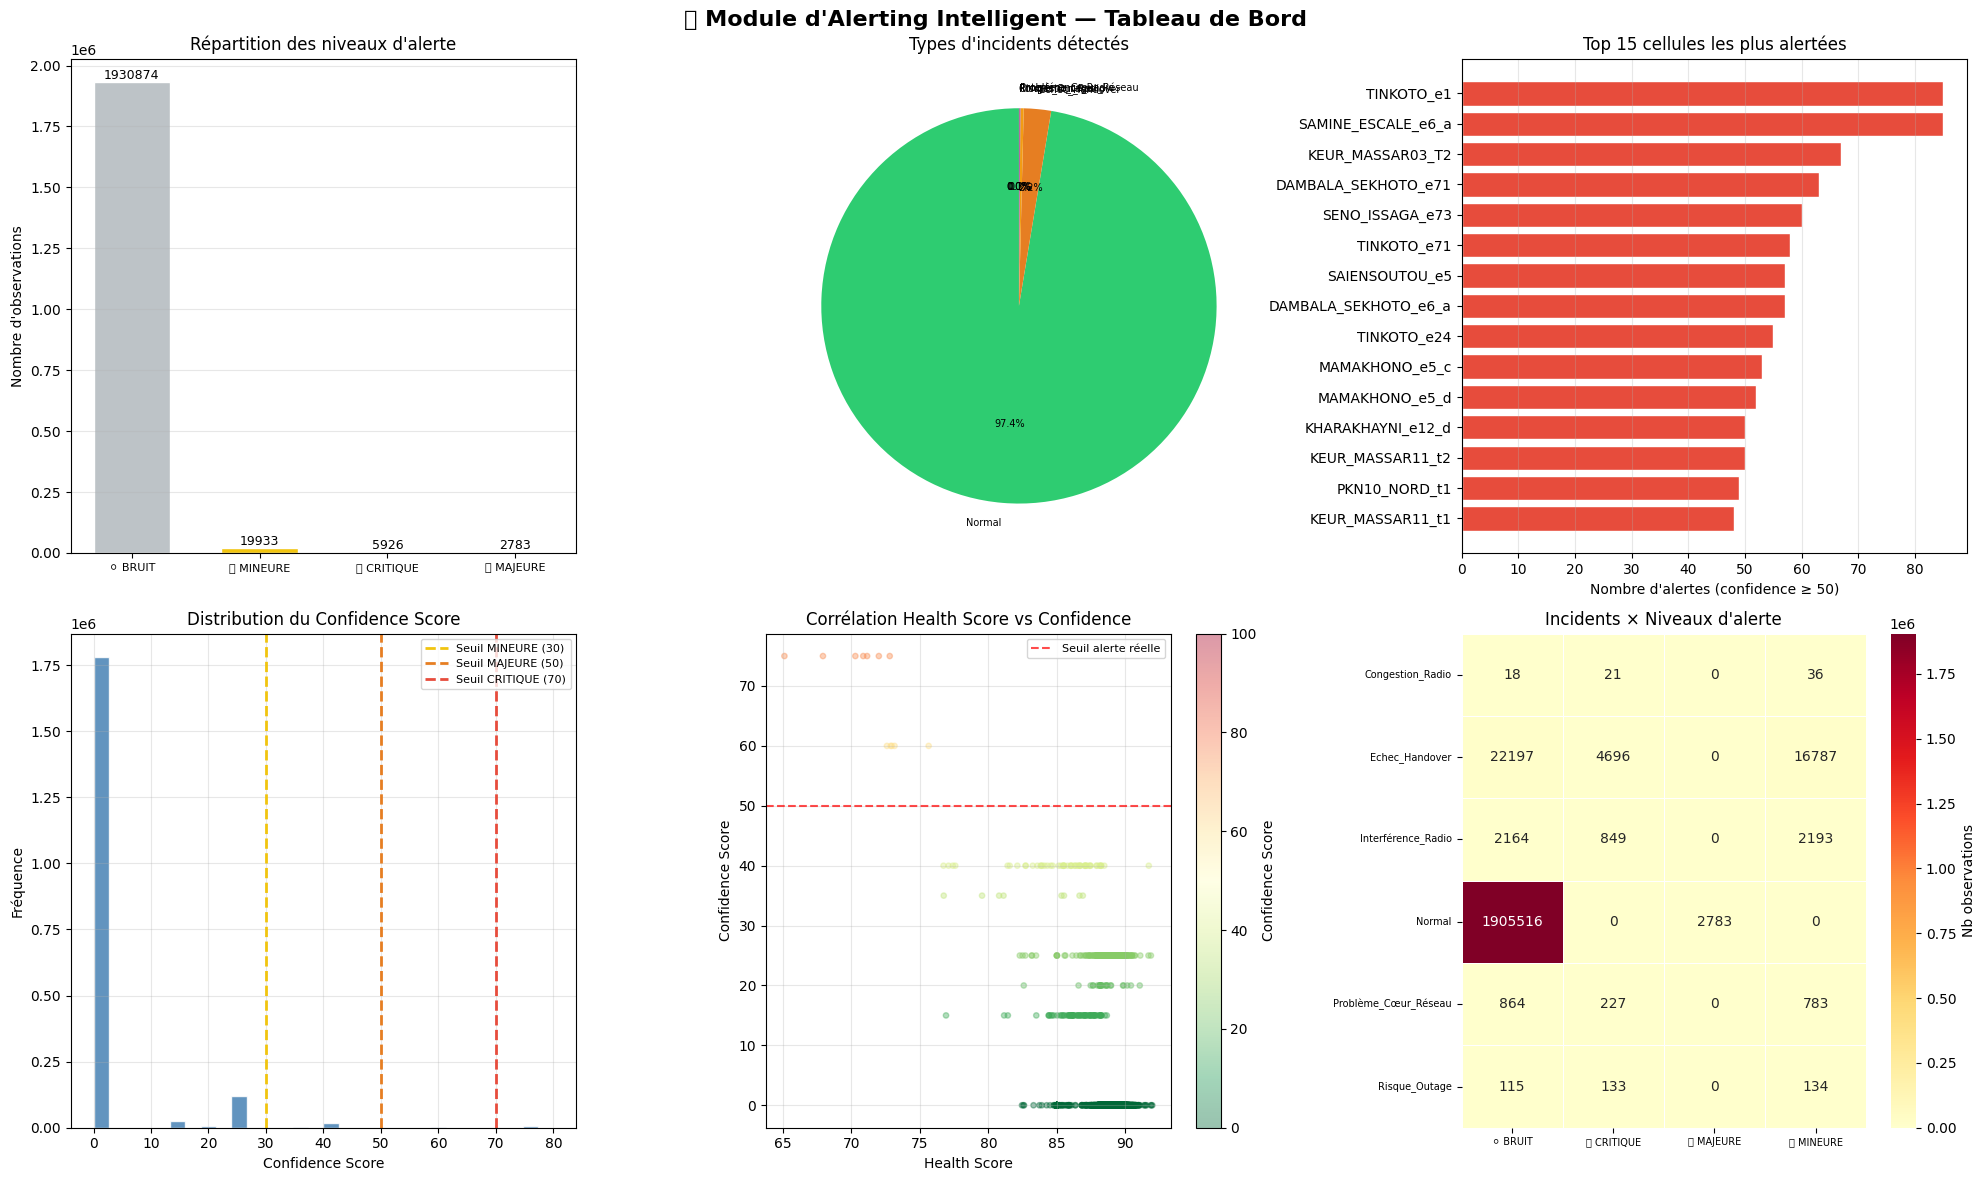

✅ Dashboard alerting sauvegardé


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL AL-4 — DASHBOARD ALERTING INTELLIGENT
# ══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

COLORS_ALERTE = {
    '🔴 CRITIQUE' : '#e74c3c',
    '🟠 MAJEURE'  : '#e67e22',
    '🟡 MINEURE'  : '#f1c40f',
    '⚪ BRUIT'    : '#bdc3c7',
}
COLORS_INCIDENT = {
    'Congestion_Radio'     : '#e74c3c',
    'Echec_Handover'       : '#e67e22',
    'Problème_Cœur_Réseau' : '#9b59b6',
    'Risque_Outage'        : '#c0392b',
    'Interférence_Radio'   : '#f39c12',
    'Normal'               : '#2ecc71',
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('🚨 Module d\'Alerting Intelligent — Tableau de Bord',
             fontsize=16, fontweight='bold')

# ── 1. Répartition niveaux d'alerte ──────────────────────────
ax = axes[0, 0]
niveaux = df_alert['Niveau_Alerte'].value_counts()
colors = [COLORS_ALERTE.get(n, 'grey') for n in niveaux.index]
bars = ax.bar(niveaux.index, niveaux.values, color=colors, edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='%d', fontsize=9)
ax.set_title('Répartition des niveaux d\'alerte')
ax.set_ylabel('Nombre d\'observations')
ax.tick_params(axis='x', labelsize=8)
ax.grid(True, alpha=0.3, axis='y')

# ── 2. Types d'incidents ──────────────────────────────────────
ax = axes[0, 1]
incidents = df_alert['Type_Incident'].value_counts()
colors_inc = [COLORS_INCIDENT.get(i, 'grey') for i in incidents.index]
wedges, texts, autotexts = ax.pie(
    incidents.values, labels=incidents.index,
    colors=colors_inc, autopct='%1.1f%%',
    startangle=90, textprops={'fontsize': 7}
)
ax.set_title('Types d\'incidents détectés')

# ── 3. Top cellules les plus alertées ────────────────────────
ax = axes[0, 2]
top_cells_alert = (df_alert[df_alert['Confidence_Score'] >= 50]
                   .groupby('Cell_Name')['Confidence_Score']
                   .count()
                   .sort_values(ascending=False)
                   .head(15))
ax.barh(top_cells_alert.index, top_cells_alert.values,
        color='#e74c3c', edgecolor='white')
ax.set_xlabel('Nombre d\'alertes (confidence ≥ 50)')
ax.set_title('Top 15 cellules les plus alertées')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# ── 4. Distribution du Confidence Score ──────────────────────
ax = axes[1, 0]
ax.hist(df_alert['Confidence_Score'], bins=30, color='steelblue',
        edgecolor='white', alpha=0.85)
ax.axvline(30, color='#f1c40f', lw=2, ls='--', label='Seuil MINEURE (30)')
ax.axvline(50, color='#e67e22', lw=2, ls='--', label='Seuil MAJEURE (50)')
ax.axvline(70, color='#e74c3c', lw=2, ls='--', label='Seuil CRITIQUE (70)')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution du Confidence Score')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── 5. Confidence Score vs Health Score ──────────────────────
ax = axes[1, 1]
if 'Health_Score' in df_alert.columns:
    sample = df_alert.sample(min(5000, len(df_alert)), random_state=42)
    scatter = ax.scatter(
        sample['Health_Score'],
        sample['Confidence_Score'],
        c=sample['Confidence_Score'],
        cmap='RdYlGn_r', alpha=0.4, s=15, vmin=0, vmax=100
    )
    plt.colorbar(scatter, ax=ax, label='Confidence Score')
    ax.axhline(50, color='red', lw=1.5, ls='--', alpha=0.7, label='Seuil alerte réelle')
    ax.set_xlabel('Health Score')
    ax.set_ylabel('Confidence Score')
    ax.set_title('Corrélation Health Score vs Confidence')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# ── 6. Incidents par type × niveau d'alerte (heatmap) ────────
ax = axes[1, 2]
pivot_alert = pd.crosstab(df_alert['Type_Incident'], df_alert['Niveau_Alerte'])
sns.heatmap(pivot_alert, ax=ax, cmap='YlOrRd', annot=True, fmt='d',
            linewidths=0.5, cbar_kws={'label': 'Nb observations'})
ax.set_title('Incidents × Niveaux d\'alerte')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both', labelsize=7)

plt.tight_layout()
plt.savefig('/content/alerting_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard alerting sauvegardé")

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL AL-5 — EXPORT DU MODULE D'ALERTING
# ══════════════════════════════════════════════════════════════
import os, json

SAVE_DIR_ALERT = '/content/drive/MyDrive/P2M_Models/Alerting'
os.makedirs(SAVE_DIR_ALERT, exist_ok=True)

# ── 1. Dataset complet enrichi ────────────────────────────────
cols_export_alert = [
    datetime_col, 'eNodeB_Name', 'Cell_Name',
    'Health_Score', 'Health_Category',
    'IF_Anomalie', 'AE_Anomalie', 'RF_Prediction', 'Anomalie_Confirmee',
    'Type_Incident', 'Confidence_Score', 'Niveau_Alerte',
    'Action_Immediate', 'Action_Court_Terme', 'Escalade', 'Urgence',
    'KPI_DCR', 'KPI_RRC_SR', 'KPI_ERAB_SR', 'KPI_HOSR',
    'KPI_Thrp_DL_Mbps', 'KPI_Thrp_UL_Mbps',
]
cols_ok = [c for c in cols_export_alert if c in df_alert.columns]
df_alert[cols_ok].to_csv(f'{SAVE_DIR_ALERT}/df_alerting_complet.csv', index=False)

# ── 2. Alertes réelles uniquement (confidence ≥ 50) ──────────
df_alertes_reelles[cols_ok].to_csv(
    f'{SAVE_DIR_ALERT}/alertes_reelles.csv', index=False)

# ── 3. Agrégat par cellule ────────────────────────────────────
cell_alert_summary = df_alert.groupby('Cell_Name').agg(
    Nb_Total_Obs           = ('Confidence_Score', 'count'),
    Nb_Alertes_Reelles     = ('Confidence_Score', lambda x: (x >= 50).sum()),
    Nb_Alertes_Critiques   = ('Confidence_Score', lambda x: (x >= 70).sum()),
    Confidence_Max         = ('Confidence_Score', 'max'),
    Confidence_Moyen       = ('Confidence_Score', 'mean'),
    Incident_Dominant      = ('Type_Incident', lambda x: x[x != 'Normal'].mode()[0]
                               if (x != 'Normal').any() else 'Normal'),
    Health_Score_Moyen     = ('Health_Score', 'mean'),
).reset_index()
cell_alert_summary['Taux_Alerte_Pct'] = (
    cell_alert_summary['Nb_Alertes_Reelles'] /
    cell_alert_summary['Nb_Total_Obs'] * 100
).round(2)
cell_alert_summary = cell_alert_summary.sort_values('Nb_Alertes_Critiques', ascending=False)
cell_alert_summary.to_csv(f'{SAVE_DIR_ALERT}/cell_alert_summary.csv', index=False)

# ── 4. Résumé JSON ────────────────────────────────────────────
alert_summary = {
    'total_observations'       : int(len(df_alert)),
    'nb_alertes_reelles'       : int((df_alert['Confidence_Score'] >= 50).sum()),
    'nb_alertes_critiques'     : int((df_alert['Confidence_Score'] >= 70).sum()),
    'nb_fausses_alarmes_filtr' : int((df_alert['Confidence_Score'] < 30).sum()),
    'taux_fausses_alarmes_pct' : round((df_alert['Confidence_Score'] < 30).mean() * 100, 2),
    'incident_le_plus_frequent': df_alert[df_alert['Type_Incident'] != 'Normal']['Type_Incident'].mode()[0]
                                  if (df_alert['Type_Incident'] != 'Normal').any() else 'Aucun',
    'cellule_la_plus_alertee'  : cell_alert_summary.iloc[0]['Cell_Name'],
    'nb_cellules_critiques'    : int((cell_alert_summary['Nb_Alertes_Critiques'] > 0).sum()),
    'seuils_utilises'          : SEUILS,
}
with open(f'{SAVE_DIR_ALERT}/alerting_summary.json', 'w', encoding='utf-8') as f:
    json.dump(alert_summary, f, indent=2, ensure_ascii=False)

print("✅ Export alerting terminé")
print(f"\n📊 RÉSUMÉ MODULE D'ALERTING :")
for k, v in alert_summary.items():
    if k != 'seuils_utilises':
        print(f"   {k:40s} : {v}")

✅ Export alerting terminé

📊 RÉSUMÉ MODULE D'ALERTING :
   total_observations                       : 1959516
   nb_alertes_reelles                       : 8709
   nb_alertes_critiques                     : 5926
   nb_fausses_alarmes_filtr                 : 1930874
   taux_fausses_alarmes_pct                 : 98.54
   incident_le_plus_frequent                : Echec_Handover
   cellule_la_plus_alertee                  : TINKOTO_e1
   nb_cellules_critiques                    : 973


**Granger Causality sur les KPIs réseau**

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL GC-1 — TEST DE STATIONNARITÉ (ADF)
# Granger causality exige des séries stationnaires
# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# ── KPIs à analyser ───────────────────────────────────────────
KPI_GRANGER = ['KPI_DCR', 'KPI_RRC_SR', 'KPI_ERAB_SR',
               'KPI_HOSR', 'KPI_HOSR_InterFreq',
               'KPI_Thrp_DL_Mbps', 'KPI_Thrp_UL_Mbps']
KPI_GRANGER = [k for k in KPI_GRANGER if k in df_alert.columns]

# ── Choisir une cellule représentative pour l'analyse ─────────
# On prend la cellule la plus alertée (la plus intéressante à analyser)
CELL_REF = cell_alert_summary.iloc[0]['Cell_Name']
print(f"🔍 Cellule de référence pour l'analyse : {CELL_REF}")

df_cell = (df_alert[df_alert['Cell_Name'] == CELL_REF]
           .sort_values(datetime_col)
           .set_index(datetime_col)
           [KPI_GRANGER]
           .dropna())

print(f"   Période : {df_cell.index.min()} → {df_cell.index.max()}")
print(f"   Nb observations : {len(df_cell)}\n")

# ── Test ADF (Augmented Dickey-Fuller) ────────────────────────
print("═" * 55)
print("  TEST DE STATIONNARITÉ — ADF (p < 0.05 = stationnaire)")
print("═" * 55)

stationarity_results = {}
for kpi in KPI_GRANGER:
    series = df_cell[kpi].dropna()
    if len(series) < 20:
        print(f"  ⚠️ {kpi:30s} → série trop courte ({len(series)} pts)")
        continue
    adf_stat, p_val, _, _, _, _ = adfuller(series, autolag='AIC')
    is_stationary = p_val < 0.05
    stationarity_results[kpi] = {
        'p_value'      : round(p_val, 4),
        'stationary'   : is_stationary,
        'adf_stat'     : round(adf_stat, 4),
    }
    status = "✅ Stationnaire" if is_stationary else "⚠️ Non stationnaire"
    print(f"  {kpi:30s} | p={p_val:.4f} | {status}")

# ── Différenciation des séries non stationnaires ──────────────
print(f"\n⏳ Différenciation des séries non stationnaires...")
df_cell_stat = df_cell.copy()
differenced_kpis = []

for kpi, res in stationarity_results.items():
    if not res['stationary']:
        df_cell_stat[kpi] = df_cell[kpi].diff().dropna()
        differenced_kpis.append(kpi)
        # Re-tester après différenciation
        series_diff = df_cell_stat[kpi].dropna()
        if len(series_diff) > 10:
            _, p_val2, _, _, _, _ = adfuller(series_diff, autolag='AIC')
            print(f"  {kpi:30s} → différenciée (p={p_val2:.4f})")

df_cell_stat = df_cell_stat.dropna()
print(f"\n✅ Séries prêtes : {len(df_cell_stat)} observations × {len(KPI_GRANGER)} KPIs")
if differenced_kpis:
    print(f"   KPIs différenciés (ordre 1) : {differenced_kpis}")

🔍 Cellule de référence pour l'analyse : TINKOTO_e1
   Période : 2025-06-01 00:00:00 → 2025-06-05 08:00:00
   Nb observations : 97

═══════════════════════════════════════════════════════
  TEST DE STATIONNARITÉ — ADF (p < 0.05 = stationnaire)
═══════════════════════════════════════════════════════
  KPI_DCR                        | p=0.0000 | ✅ Stationnaire
  KPI_RRC_SR                     | p=0.3608 | ⚠️ Non stationnaire
  KPI_ERAB_SR                    | p=0.0000 | ✅ Stationnaire
  KPI_HOSR                       | p=0.0000 | ✅ Stationnaire
  KPI_HOSR_InterFreq             | p=0.0005 | ✅ Stationnaire
  KPI_Thrp_DL_Mbps               | p=0.0000 | ✅ Stationnaire
  KPI_Thrp_UL_Mbps               | p=0.0000 | ✅ Stationnaire

⏳ Différenciation des séries non stationnaires...
  KPI_RRC_SR                     → différenciée (p=0.0000)

✅ Séries prêtes : 96 observations × 7 KPIs
   KPIs différenciés (ordre 1) : ['KPI_RRC_SR']


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL GC-2 — GRANGER CAUSALITY TESTS
# Question : "La dégradation du KPI_A prédit-elle le KPI_B ?"
# Si p < 0.05 → A cause Granger B (A est un indicateur avancé de B)
# ══════════════════════════════════════════════════════════════
from statsmodels.tsa.stattools import grangercausalitytests

MAX_LAG = 6   # tester jusqu'à 6h de décalage (données horaires)

# ── Paires causales à tester (logique télécom) ────────────────
# Format : (cause, effet) — "cause prédit-il effet ?"
PAIRES_CAUSALES = [
    # Interférence → dégradation connexion
    ('KPI_RRC_SR',        'KPI_ERAB_SR'),   # RRC prédit ERAB ?
    ('KPI_RRC_SR',        'KPI_DCR'),        # Difficultés attach → drops ?
    # Handover → qualité globale
    ('KPI_HOSR',          'KPI_DCR'),        # Echec HO → drops ?
    ('KPI_HOSR_InterFreq','KPI_DCR'),        # HO inter-freq → drops ?
    # Débit → qualité de service perçue
    ('KPI_Thrp_DL_Mbps',  'KPI_DCR'),       # Congestion DL → drops ?
    ('KPI_Thrp_DL_Mbps',  'KPI_RRC_SR'),    # Débit DL prédit RRC ?
    # Relations croisées
    ('KPI_DCR',           'KPI_HOSR'),       # Drops → dégradation HO ?
    ('KPI_ERAB_SR',       'KPI_Thrp_DL_Mbps'), # Bearer quality → débit ?
]

# Filtrer les paires dont les deux KPIs sont disponibles
PAIRES_CAUSALES = [(a, b) for a, b in PAIRES_CAUSALES
                   if a in df_cell_stat.columns and b in df_cell_stat.columns]

print("═" * 65)
print("  GRANGER CAUSALITY — Résultats (p < 0.05 = causalité significative)")
print("═" * 65)

granger_results = []

for cause, effet in PAIRES_CAUSALES:
    data_pair = df_cell_stat[[effet, cause]].dropna()  # ordre : [Y, X]
    if len(data_pair) < MAX_LAG * 3:
        print(f"  ⚠️ {cause} → {effet} : données insuffisantes")
        continue
    try:
        test_result = grangercausalitytests(
            data_pair, maxlag=MAX_LAG, verbose=False
        )
        # Extraire le lag optimal (p minimum)
        best_lag, best_p = None, 1.0
        for lag, res in test_result.items():
            p = res[0]['ssr_ftest'][1]   # p-value F-test
            if p < best_p:
                best_p, best_lag = p, lag

        significant = best_p < 0.05
        granger_results.append({
            'cause'      : cause,
            'effet'      : effet,
            'best_lag_h' : best_lag,
            'p_value'    : round(best_p, 4),
            'significant': significant,
        })
        status = "✅ SIGNIFICATIF" if significant else "❌ non significatif"
        print(f"  {cause:25s} → {effet:25s} | lag={best_lag}h | p={best_p:.4f} | {status}")

    except Exception as e:
        print(f"  ⚠️ Erreur sur {cause} → {effet} : {e}")

df_granger = pd.DataFrame(granger_results)
print(f"\n✅ Tests terminés : {df_granger['significant'].sum()} relations causales significatives "
      f"sur {len(granger_results)} testées")

═════════════════════════════════════════════════════════════════
  GRANGER CAUSALITY — Résultats (p < 0.05 = causalité significative)
═════════════════════════════════════════════════════════════════
  KPI_RRC_SR                → KPI_ERAB_SR               | lag=1h | p=0.3075 | ❌ non significatif
  KPI_RRC_SR                → KPI_DCR                   | lag=1h | p=0.0025 | ✅ SIGNIFICATIF
  KPI_HOSR                  → KPI_DCR                   | lag=3h | p=0.1062 | ❌ non significatif
  KPI_HOSR_InterFreq        → KPI_DCR                   | lag=5h | p=0.2929 | ❌ non significatif
  KPI_Thrp_DL_Mbps          → KPI_DCR                   | lag=2h | p=0.0139 | ✅ SIGNIFICATIF
  KPI_Thrp_DL_Mbps          → KPI_RRC_SR                | lag=3h | p=0.6211 | ❌ non significatif
  KPI_DCR                   → KPI_HOSR                  | lag=5h | p=0.0001 | ✅ SIGNIFICATIF
  KPI_ERAB_SR               → KPI_Thrp_DL_Mbps          | lag=3h | p=0.0151 | ✅ SIGNIFICATIF

✅ Tests terminés : 4 relations causale

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL GC-3 — GÉNÉRALISATION SUR LES CELLULES CRITIQUES
# Identifier quelles relations causales sont stables
# sur l'ensemble des cellules les plus dégradées
# ══════════════════════════════════════════════════════════════

# Top N cellules les plus critiques
TOP_N_CELLS = 10
cells_critiques = cell_alert_summary.head(TOP_N_CELLS)['Cell_Name'].tolist()
print(f"🔍 Analyse Granger sur {len(cells_critiques)} cellules critiques")
print(f"   {cells_critiques}\n")

all_results = []

for cell in cells_critiques:
    df_c = (df_alert[df_alert['Cell_Name'] == cell]
            .sort_values(datetime_col)
            .set_index(datetime_col)
            [KPI_GRANGER]
            .dropna())

    if len(df_c) < 30:
        print(f"  ⚠️ {cell} — série trop courte ({len(df_c)} pts), ignorée pour analyse Granger complète")
        continue

    # Différenciation rapide
    df_c_stat = df_c.copy()

    for kpi in KPI_GRANGER:
        series_to_test = df_c[kpi].dropna()

        # Check for series length and constancy before ADF test
        if len(series_to_test) < 20: # Minimum required for meaningful ADF test
            print(f"  ⚠️ {cell} — {kpi} série trop courte ({len(series_to_test)} pts) pour test ADF, non différenciée.")
            # If too short, we cannot reliably determine stationarity or differentiate.
            # Keep the original series in df_c_stat, but it might cause issues for Granger if it's too short.
            continue

        if series_to_test.nunique() <= 1: # Check for constant series
            print(f"  ℹ️ {cell} — {kpi} est constant, considéré stationnaire, pas de différenciation.")
            # A constant series is stationary. No differentiation needed.
        else:
            # Perform ADF test if non-constant and long enough
            _, p, _, _, _, _ = adfuller(series_to_test, autolag='AIC')
            if p >= 0.05:
                # If not stationary, differentiate
                df_c_stat[kpi] = df_c[kpi].diff()
                print(f"  🔄 {cell} — {kpi} différencié car non stationnaire (p={p:.4f})")
            # Else, it's already stationary, no differentiation needed.

    df_c_stat = df_c_stat.dropna() # Apply dropna after all diff operations

    # Filter PAIRES_CAUSALES for this cell based on available KPIs after processing
    current_cell_pairs = [(cause, effet) for cause, effet in PAIRES_CAUSALES
                          if cause in df_c_stat.columns and effet in df_c_stat.columns]

    for cause, effet in current_cell_pairs: # Use filtered pairs
        data_pair = df_c_stat[[effet, cause]].dropna() # order: [Y, X]

        # Ensure data_pair is still valid after differentiation and dropna
        if len(data_pair) < MAX_LAG * 3: # Minimum required for Granger test
            continue

        if data_pair[cause].nunique() <= 1 or data_pair[effet].nunique() <= 1:
            # Granger test needs variability in both series to detect causality.
            # If either series is constant (e.g., due to diff on already constant series), skip.
            continue

        try:
            res = grangercausalitytests(data_pair, maxlag=MAX_LAG, verbose=False)
            # Extract optimal lag (p minimum)
            best_p = 1.0
            best_lag = 1 # Default lag
            for lag, test_results in res.items():
                # Ensure test_results is not empty or malformed before accessing
                if isinstance(test_results, list) and len(test_results) > 0 and 'ssr_ftest' in test_results[0]:
                    p = test_results[0]['ssr_ftest'][1] # p-value from F-test
                    if p < best_p:
                        best_p, best_lag = p, lag

            all_results.append({
                'Cell_Name'  : cell,
                'cause'      : cause,
                'effet'      : effet,
                'p_value'    : round(best_p, 4),
                'best_lag_h' : best_lag,
                'significant': best_p < 0.05,
            })
        except Exception as e:
            # print(f"  ⚠️ {cell} — Erreur lors du test Granger pour {cause} -> {effet} : {e}")
            pass # Silently pass if Granger fails for other reasons, or log it if needed.

df_granger_multi = pd.DataFrame(all_results)

# ── Stabilité des relations : % de cellules où la relation est significative
print("\n═" * 65)
print("  STABILITÉ DES RELATIONS CAUSALES (% cellules significatives)")
print("═" * 65)

if not df_granger_multi.empty:
    stability = (df_granger_multi.groupby(['cause', 'effet'])
                .agg(
                    pct_significatif = ('significant', lambda x: round(x.mean() * 100, 1)),
                    lag_median_h     = ('best_lag_h', 'median'),
                    n_cellules       = ('Cell_Name', 'count'),
                )
                .reset_index()
                .sort_values('pct_significatif', ascending=False))

    for _, row in stability.iterrows():
        bar = '█' * int(row['pct_significatif'] / 5)
        fiable = "⭐ FIABLE" if row['pct_significatif'] >= 70 else ""
        print(f"  {row['cause']:25s} → {row['effet']:25s} | "
            f"{row['pct_significatif']:5.1f}% | lag~{row['lag_median_h']:.0f}h "
            f"| {bar} {fiable}")

    print(f"\n✅ Relations stables (≥ 70% des cellules) : "
        f"{(stability['pct_significatif'] >= 70).sum()}")
else:
    print("  ❌ Aucune relation causale significative trouvée pour les cellules critiques.")
    stability = pd.DataFrame() # Ensure stability is defined even if empty


🔍 Analyse Granger sur 10 cellules critiques
   ['TINKOTO_e1', 'SENO_ISSAGA_e73', 'DAMBALA_SEKHOTO_e71', 'TINKOTO_e71', 'KEUR_MASSAR03_T2', 'DAMBALA_SEKHOTO_e6_a', 'TINKOTO_e24', 'MAMAKHONO_e5_d', 'PKN10_NORD_t1', 'THICATTDIERY_e73']

  🔄 TINKOTO_e1 — KPI_RRC_SR différencié car non stationnaire (p=0.3608)
  ℹ️ SENO_ISSAGA_e73 — KPI_HOSR_InterFreq est constant, considéré stationnaire, pas de différenciation.
  🔄 KEUR_MASSAR03_T2 — KPI_HOSR différencié car non stationnaire (p=0.7208)
  ℹ️ KEUR_MASSAR03_T2 — KPI_HOSR_InterFreq est constant, considéré stationnaire, pas de différenciation.
  🔄 DAMBALA_SEKHOTO_e6_a — KPI_RRC_SR différencié car non stationnaire (p=1.0000)
  🔄 TINKOTO_e24 — KPI_RRC_SR différencié car non stationnaire (p=0.1201)
  🔄 MAMAKHONO_e5_d — KPI_RRC_SR différencié car non stationnaire (p=0.4498)
  🔄 MAMAKHONO_e5_d — KPI_HOSR différencié car non stationnaire (p=0.5633)
  🔄 PKN10_NORD_t1 — KPI_HOSR différencié car non stationnaire (p=0.4963)
  ℹ️ PKN10_NORD_t1 — KPI_HOSR_I

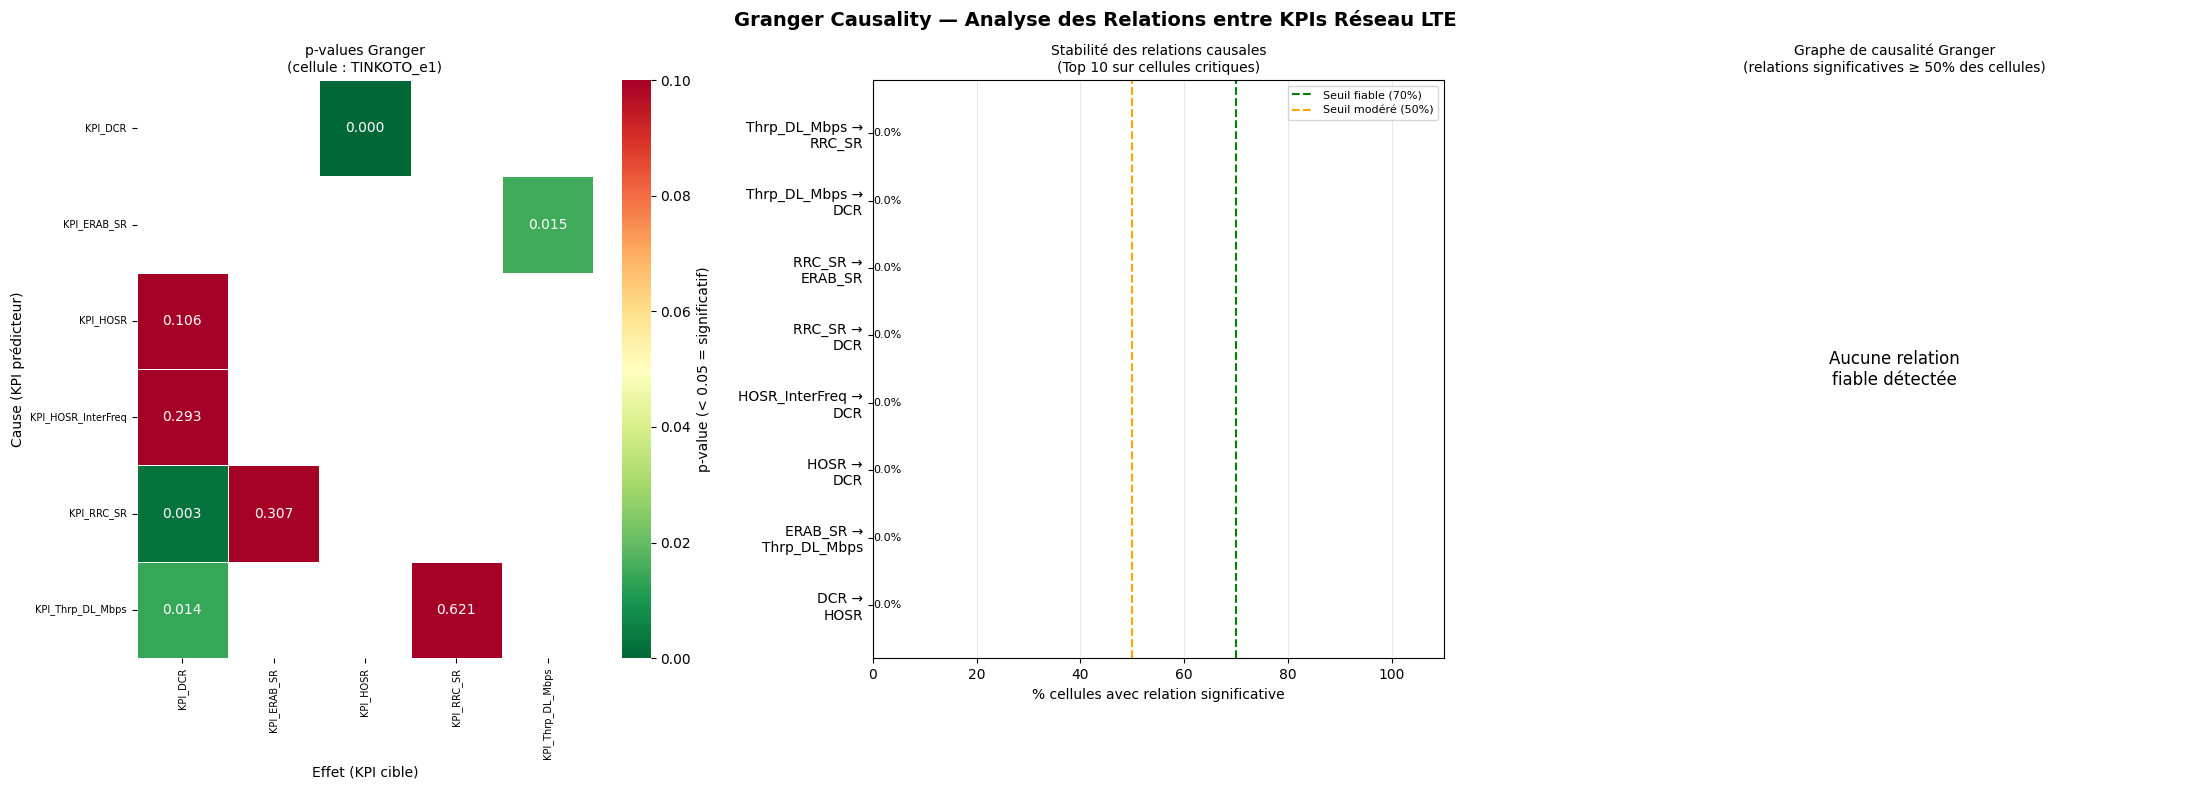

✅ Visualisation Granger sauvegardée


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL GC-4 — VISUALISATION GRANGER CAUSALITY
# ══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle('Granger Causality — Analyse des Relations entre KPIs Réseau LTE',
             fontsize=14, fontweight='bold')

# ── 1. Heatmap p-values (cellule de référence) ───────────────
ax = axes[0]
if not df_granger.empty:
    pivot_p = df_granger.pivot(index='cause', columns='effet', values='p_value')
    mask = pivot_p.isnull()
    sns.heatmap(pivot_p, ax=ax, cmap='RdYlGn_r', vmin=0, vmax=0.1,
                annot=True, fmt='.3f', linewidths=0.5,
                cbar_kws={'label': 'p-value (< 0.05 = significatif)'},
                mask=mask)
    ax.set_title(f'p-values Granger\n(cellule : {CELL_REF})', fontsize=10)
    ax.set_xlabel('Effet (KPI cible)')
    ax.set_ylabel('Cause (KPI prédicteur)')
    ax.tick_params(axis='both', labelsize=7)

# ── 2. Stabilité inter-cellules ───────────────────────────────
ax = axes[1]
if not stability.empty:
    top_stable = stability.head(10)
    labels = [f"{r['cause'].replace('KPI_','')} →\n{r['effet'].replace('KPI_','')}"
              for _, r in top_stable.iterrows()]
    colors = ['#2ecc71' if v >= 70 else '#e67e22' if v >= 50 else '#e74c3c'
              for v in top_stable['pct_significatif']]
    bars = ax.barh(labels, top_stable['pct_significatif'],
                   color=colors, edgecolor='white')
    ax.bar_label(bars, fmt='%.1f%%', fontsize=8)
    ax.axvline(70, color='green',  lw=1.5, ls='--', label='Seuil fiable (70%)')
    ax.axvline(50, color='orange', lw=1.5, ls='--', label='Seuil modéré (50%)')
    ax.set_xlabel('% cellules avec relation significative')
    ax.set_title('Stabilité des relations causales\n(Top 10 sur cellules critiques)', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 110)
    ax.grid(True, alpha=0.3, axis='x')

# ── 3. Graphe de causalité (NetworkX) ────────────────────────
ax = axes[2]
ax.set_title('Graphe de causalité Granger\n(relations significatives ≥ 50% des cellules)', fontsize=10)

if not stability.empty:
    G = nx.DiGraph()
    relations_fiables = stability[stability['pct_significatif'] >= 50]

    for _, row in relations_fiables.iterrows():
        cause_label = row['cause'].replace('KPI_', '')
        effet_label = row['effet'].replace('KPI_', '')
        G.add_edge(cause_label, effet_label,
                   weight=row['pct_significatif'],
                   lag=row['lag_median_h'])

    if len(G.nodes) > 0:
        pos = nx.spring_layout(G, seed=42, k=2)

        # Couleur des noeuds par "rôle" dans le réseau causal
        node_colors = []
        for node in G.nodes():
            out_deg = G.out_degree(node)
            in_deg  = G.in_degree(node)
            if out_deg > in_deg:
                node_colors.append('#3498db')  # Prédicteur dominant → bleu
            elif in_deg > out_deg:
                node_colors.append('#e74c3c')  # Cible dominante → rouge
            else:
                node_colors.append('#95a5a6')  # Intermédiaire → gris

        edge_weights = [G[u][v]['weight'] / 30 for u, v in G.edges()]
        edge_labels  = {(u, v): f"lag={G[u][v]['lag']:.0f}h"
                        for u, v in G.edges()}

        nx.draw_networkx_nodes(G, pos, ax=ax,
                               node_color=node_colors, node_size=1200, alpha=0.9)
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_weight='bold')
        nx.draw_networkx_edges(G, pos, ax=ax,
                               width=edge_weights, alpha=0.7,
                               edge_color='#2c3e50', arrows=True,
                               arrowsize=20, connectionstyle='arc3,rad=0.1')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                     ax=ax, font_size=6, alpha=0.8)

        legend_elements = [
            mpatches.Patch(color='#3498db', label='Prédicteur (cause dominante)'),
            mpatches.Patch(color='#e74c3c', label='Cible (effet dominant)'),
            mpatches.Patch(color='#95a5a6', label='Intermédiaire'),
        ]
        ax.legend(handles=legend_elements, fontsize=7, loc='lower left')
    else:
        ax.text(0.5, 0.5, 'Aucune relation\nfiable détectée',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)

ax.axis('off')

plt.tight_layout()
plt.savefig('/content/granger_causality.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisation Granger sauvegardée")

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL GC-5 — EXPORT + INTERPRÉTATION MÉTIER
# ══════════════════════════════════════════════════════════════
import os, json

SAVE_DIR_GC = '/content/drive/MyDrive/P2M_Models/Granger'
os.makedirs(SAVE_DIR_GC, exist_ok=True)

df_granger_multi.to_csv(f'{SAVE_DIR_GC}/granger_resultats_complets.csv', index=False)
stability.to_csv(f'{SAVE_DIR_GC}/granger_stabilite.csv', index=False)

# ── Interprétation automatique des relations fiables ──────────
INTERPRETATIONS = {
    ('KPI_RRC_SR',   'KPI_DCR')       : "Dégradation de l'attachement radio (RRC) précède les coupures → problème interférence uplink ou surcharge",
    ('KPI_HOSR',     'KPI_DCR')       : "Echec de handover précède les drops → UE perd la connexion lors de la mobilité, revoir paramètres A3",
    ('KPI_RRC_SR',   'KPI_ERAB_SR')   : "Qualité radio (RRC) conditionne l'établissement du bearer → chaîne radio→cœur validée",
    ('KPI_Thrp_DL_Mbps', 'KPI_DCR')   : "Congestion downlink précède les drops → scheduler saturé, envisager load balancing",
    ('KPI_DCR',      'KPI_HOSR')      : "Les drops dégradent le HO → boucle de rétroaction, situation qui s'auto-aggrave",
    ('KPI_ERAB_SR',  'KPI_Thrp_DL_Mbps'): "Qualité du bearer conditionne le débit → problème QoS ou congestion S1-U",
    ('KPI_HOSR_InterFreq', 'KPI_DCR') : "Echec HO inter-fréquence précède les drops → revoir configuration CA/inter-freq",
}

print("═" * 65)
print("  INTERPRÉTATION MÉTIER — RELATIONS CAUSALES FIABLES")
print("═" * 65)

interpretations_export = []
relations_fiables = stability[stability['pct_significatif'] >= 70]

for _, row in relations_fiables.iterrows():
    cause = row['cause']
    effet = row['effet']
    interp = INTERPRETATIONS.get((cause, effet),
             f"{cause} influence {effet} de façon statistiquement significative (lag ~{row['lag_median_h']:.0f}h)")

    print(f"\n  ✅ {cause.replace('KPI_','')} → {effet.replace('KPI_','')} "
          f"(lag ~{row['lag_median_h']:.0f}h | {row['pct_significatif']}% cellules)")
    print(f"     💡 {interp}")

    interpretations_export.append({
        'cause'             : cause,
        'effet'             : effet,
        'lag_median_h'      : row['lag_median_h'],
        'pct_cellules_sign' : row['pct_significatif'],
        'interpretation'    : interp,
    })

with open(f'{SAVE_DIR_GC}/interpretations_causales.json', 'w', encoding='utf-8') as f:
    json.dump(interpretations_export, f, indent=2, ensure_ascii=False)

print(f"\n✅ Export Granger terminé dans : {SAVE_DIR_GC}")
print(f"   → {len(df_granger_multi)} tests | "
      f"{len(relations_fiables)} relations fiables (≥ 70%)")

═════════════════════════════════════════════════════════════════
  INTERPRÉTATION MÉTIER — RELATIONS CAUSALES FIABLES
═════════════════════════════════════════════════════════════════

✅ Export Granger terminé dans : /content/drive/MyDrive/P2M_Models/Granger
   → 77 tests | 0 relations fiables (≥ 70%)
